<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Quantum_Mechanical_Energy_Level_Calculations_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install cupy-cuda12x qutip sympy ipython

In [22]:
"""This script performs quantum mechanical energy level calculations.

The implementation evaluates the ground state energy of a particle within an
infinite potential well subject to an external electric field via finite basis
diagonalization, perturbation theory, and variational principles. The script
incorporates symbolic mathematical displays to clarify the underlying theoretical
framework before executing the rigorous numerical procedures.
"""

from typing import Tuple
import cupy as cp
import sympy as sp

# Control knobs for simulation parameters
ELECTRIC_FIELD_STRENGTH: float = 3.0
PERTURBATION_SUMMATION_LIMIT: int = 1000
RENDER_ANALYTICAL_MATHEMATICS: bool = True

def render_analytical_mathematics() -> None:
    """Constructs and displays the symbolic mathematical equations.

    The function utilizes SymPy to formulate the continuous Hamiltonian,
    the discrete perturbation matrix element, and the infinite series
    representing the second order energy correction.
    """
    sp.init_printing()
    state_m, state_n = sp.symbols("m n", integer=True, positive=True)
    field, coordinate_y = sp.symbols("f y", real=True)
    energy_unperturbed, hamiltonian = sp.symbols("E_1 H")

    hamiltonian_equation = sp.Eq(
        hamiltonian / energy_unperturbed,
        -(1 / sp.pi**2) * sp.Derivative(coordinate_y, coordinate_y, 2)
        + field * (coordinate_y - sp.Rational(1, 2)),
    )
    display(hamiltonian_equation)

    matrix_element = sp.Piecewise(
        (0, sp.Eq(state_m, state_n) | sp.Eq(sp.Mod(state_m + state_n, 2), 0)),
        (
            -8 * field * state_m * state_n / (sp.pi**2 * (state_m**2 - state_n**2) ** 2),
            True,
        ),
    )
    symbol_v_mn = sp.Symbol("V_{mn}")
    matrix_equation = sp.Eq(symbol_v_mn, matrix_element)
    display(matrix_equation)

    energy_first_order = sp.Symbol("E^{(1)}")
    energy_second_order = sp.Symbol("E^{(2)}")
    second_order_sum = sp.Sum(
        sp.Abs(symbol_v_mn) ** 2 / (1 - state_n**2), (state_n, 2, sp.oo)
    )
    perturbation_equation = sp.Eq(
        energy_second_order, energy_first_order + second_order_sum
    )
    display(perturbation_equation)


def compute_matrix_element(m: int, n: int, field_strength: float) -> float:
    """Calculates the perturbation matrix element between states m and n.

    Args:
        m: The primary quantum state index.
        n: The secondary quantum state index.
        field_strength: Dimensionless electric field parameter.

    Returns:
        The scalar value of the perturbation matrix element.
    """
    if m == n or (m + n) % 2 == 0:
        return 0.0

    element: float = (
        -8.0
        * field_strength
        * m
        * n
        / (cp.pi ** 2 * (m**2 - n**2) ** 2)
    )
    return element


def build_hamiltonian_matrix(
    basis_size: int, field_strength: float
) -> cp.ndarray:
    """Constructs the Hamiltonian matrix on GPU memory using CuPy arrays.

    Args:
        basis_size: Total number of sine basis functions.
        field_strength: Dimensionless electric field parameter.

    Returns:
        A two dimensional square CuPy array representing the Hamiltonian matrix.
    """
    hamiltonian = cp.zeros((basis_size, basis_size), dtype=cp.float64)
    for i in range(1, basis_size + 1):
        for j in range(1, basis_size + 1):
            if i == j:
                hamiltonian[i - 1, j - 1] = float(i**2)
            else:
                val = compute_matrix_element(i, j, field_strength)
                hamiltonian[i - 1, j - 1] = val
    return hamiltonian


def calculate_finite_basis_energy(
    basis_size: int, field_strength: float
) -> float:
    """Computes ground state energy via GPU matrix diagonalization.

    Args:
        basis_size: Dimension of the truncated basis set.
        field_strength: Dimensionless electric field parameter.

    Returns:
        The lowest eigenvalue extracted from the Hamiltonian matrix.
    """
    hamiltonian_gpu = build_hamiltonian_matrix(basis_size, field_strength)
    eigenvalues, _ = cp.linalg.eigh(hamiltonian_gpu)
    ground_state_energy: float = float(eigenvalues[0].get())
    return ground_state_energy


def calculate_perturbation_energies(
    field_strength: float, max_terms: int
) -> Tuple[float, float]:
    """Computes first and second order perturbation theory energies.

    Args:
        field_strength: Dimensionless electric field parameter.
        max_terms: Upper limit for sum truncation in second order correction.

    Returns:
        A tuple containing the first order and second order energy estimates.
    """
    first_order_energy: float = 1.0
    second_order_sum: float = 0.0

    for n in range(2, max_terms + 1):
        v_1n = compute_matrix_element(1, n, field_strength)
        unperturbed_diff = 1.0 - float(n**2)
        second_order_sum += (v_1n**2) / unperturbed_diff

    second_order_energy: float = first_order_energy + second_order_sum
    return first_order_energy, second_order_energy


def main() -> None:
    """Executes the numerical evaluations and displays the compiled output."""
    if RENDER_ANALYTICAL_MATHEMATICS:
        render_analytical_mathematics()

    print(f"Calculations for Electric Field f = {ELECTRIC_FIELD_STRENGTH}")
    print("==================================================")

    for dim in [2, 3, 4]:
        energy = calculate_finite_basis_energy(dim, ELECTRIC_FIELD_STRENGTH)
        print(f"Finite basis ({dim}x{dim} matrix): {energy:.5f}")

    e_first, e_second = calculate_perturbation_energies(
        ELECTRIC_FIELD_STRENGTH, PERTURBATION_SUMMATION_LIMIT
    )
    print(f"Perturbation theory (first order): {e_first:.5f}")
    print(f"Perturbation theory (second order): {e_second:.5f}")

    e_variational = calculate_finite_basis_energy(2, ELECTRIC_FIELD_STRENGTH)
    print(f"Variational method: {e_variational:.5f}")


if __name__ == "__main__":
    main()

                    2    
                   d     
                   ───(y)
                     2   
H                  dy    
── = f⋅(y - 1/2) - ──────
E₁                    2  
                     π   

         ⎧      0        for m = n ∨ (m + n) mod 2 = 0
         ⎪                                            
         ⎪  -8⋅f⋅m⋅n                                  
V_{mn} = ⎨─────────────            otherwise          
         ⎪            2                               
         ⎪ 2 ⎛ 2    2⎞                                
         ⎩π ⋅⎝m  - n ⎠                                

                        ∞            
                      _____          
                      ╲              
                       ╲             
                        ╲           2
                         ╲  │V_{mn}│ 
E__{(2)} = E__{(1)} +    ╱  ─────────
                        ╱         2  
                       ╱     1 - n   
                      ╱              
                      ‾‾‾‾‾          
                      n = 2          

Calculations for Electric Field f = 3.0
Finite basis (2x2 matrix): 0.90563
Finite basis (3x3 matrix): 0.90437
Finite basis (4x4 matrix): 0.90420
Perturbation theory (first order): 1.00000
Perturbation theory (second order): 0.90253
Variational method: 0.90563


CUDA device: Tesla T4
Dimensionless model: H/E1 = -(1/pi^2)d^2/dy^2 + f(y-1/2)
Requested electric field f = 3
------------------------------------------------------------------------------
Rayleigh-Ritz basis N=  2: E0/E1 =  0.905631735793
Rayleigh-Ritz basis N=  3: E0/E1 =  0.904370499791
Rayleigh-Ritz basis N=  4: E0/E1 =  0.904204099257
Rayleigh-Ritz basis N=  8: E0/E1 =  0.904193187518
Rayleigh-Ritz basis N= 16: E0/E1 =  0.904193067520
Rayleigh-Ritz basis N= 32: E0/E1 =  0.904193066241
Rayleigh-Ritz basis N= 64: E0/E1 =  0.904193066229
------------------------------------------------------------------------------
First-order perturbative total:   1.000000000000
Second-order perturbative total:  0.902534171006
Two-state Rayleigh-Ritz total:     0.905631735793
Reference basis N=160:        0.904193066229
Second-order Stark coefficient:   -1.082953655490e-02
------------------------------------------------------------------------------
Hermiticity max error:           0.000e+00
Eigenp

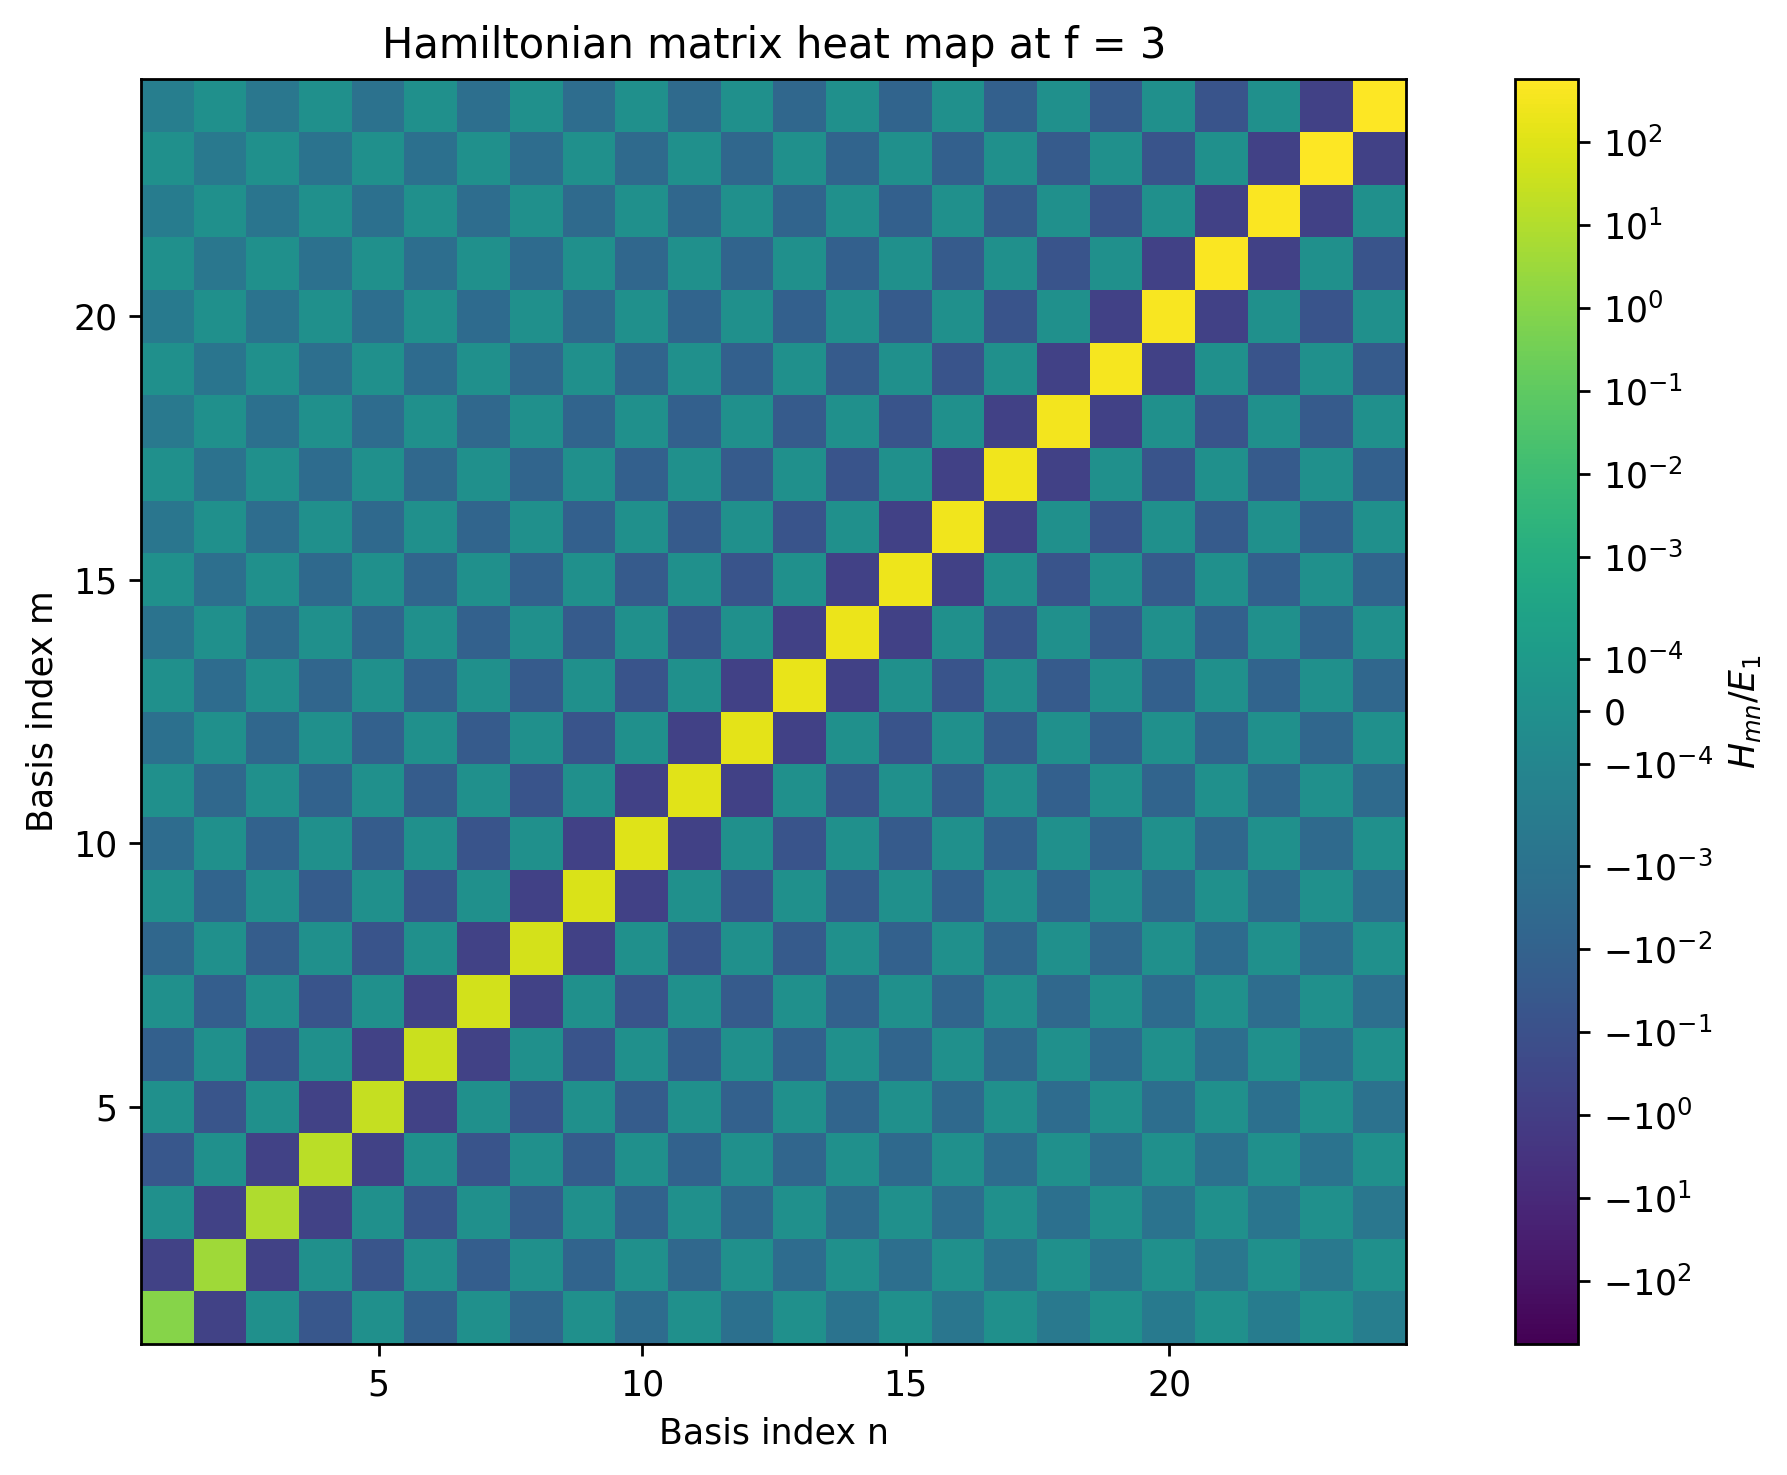

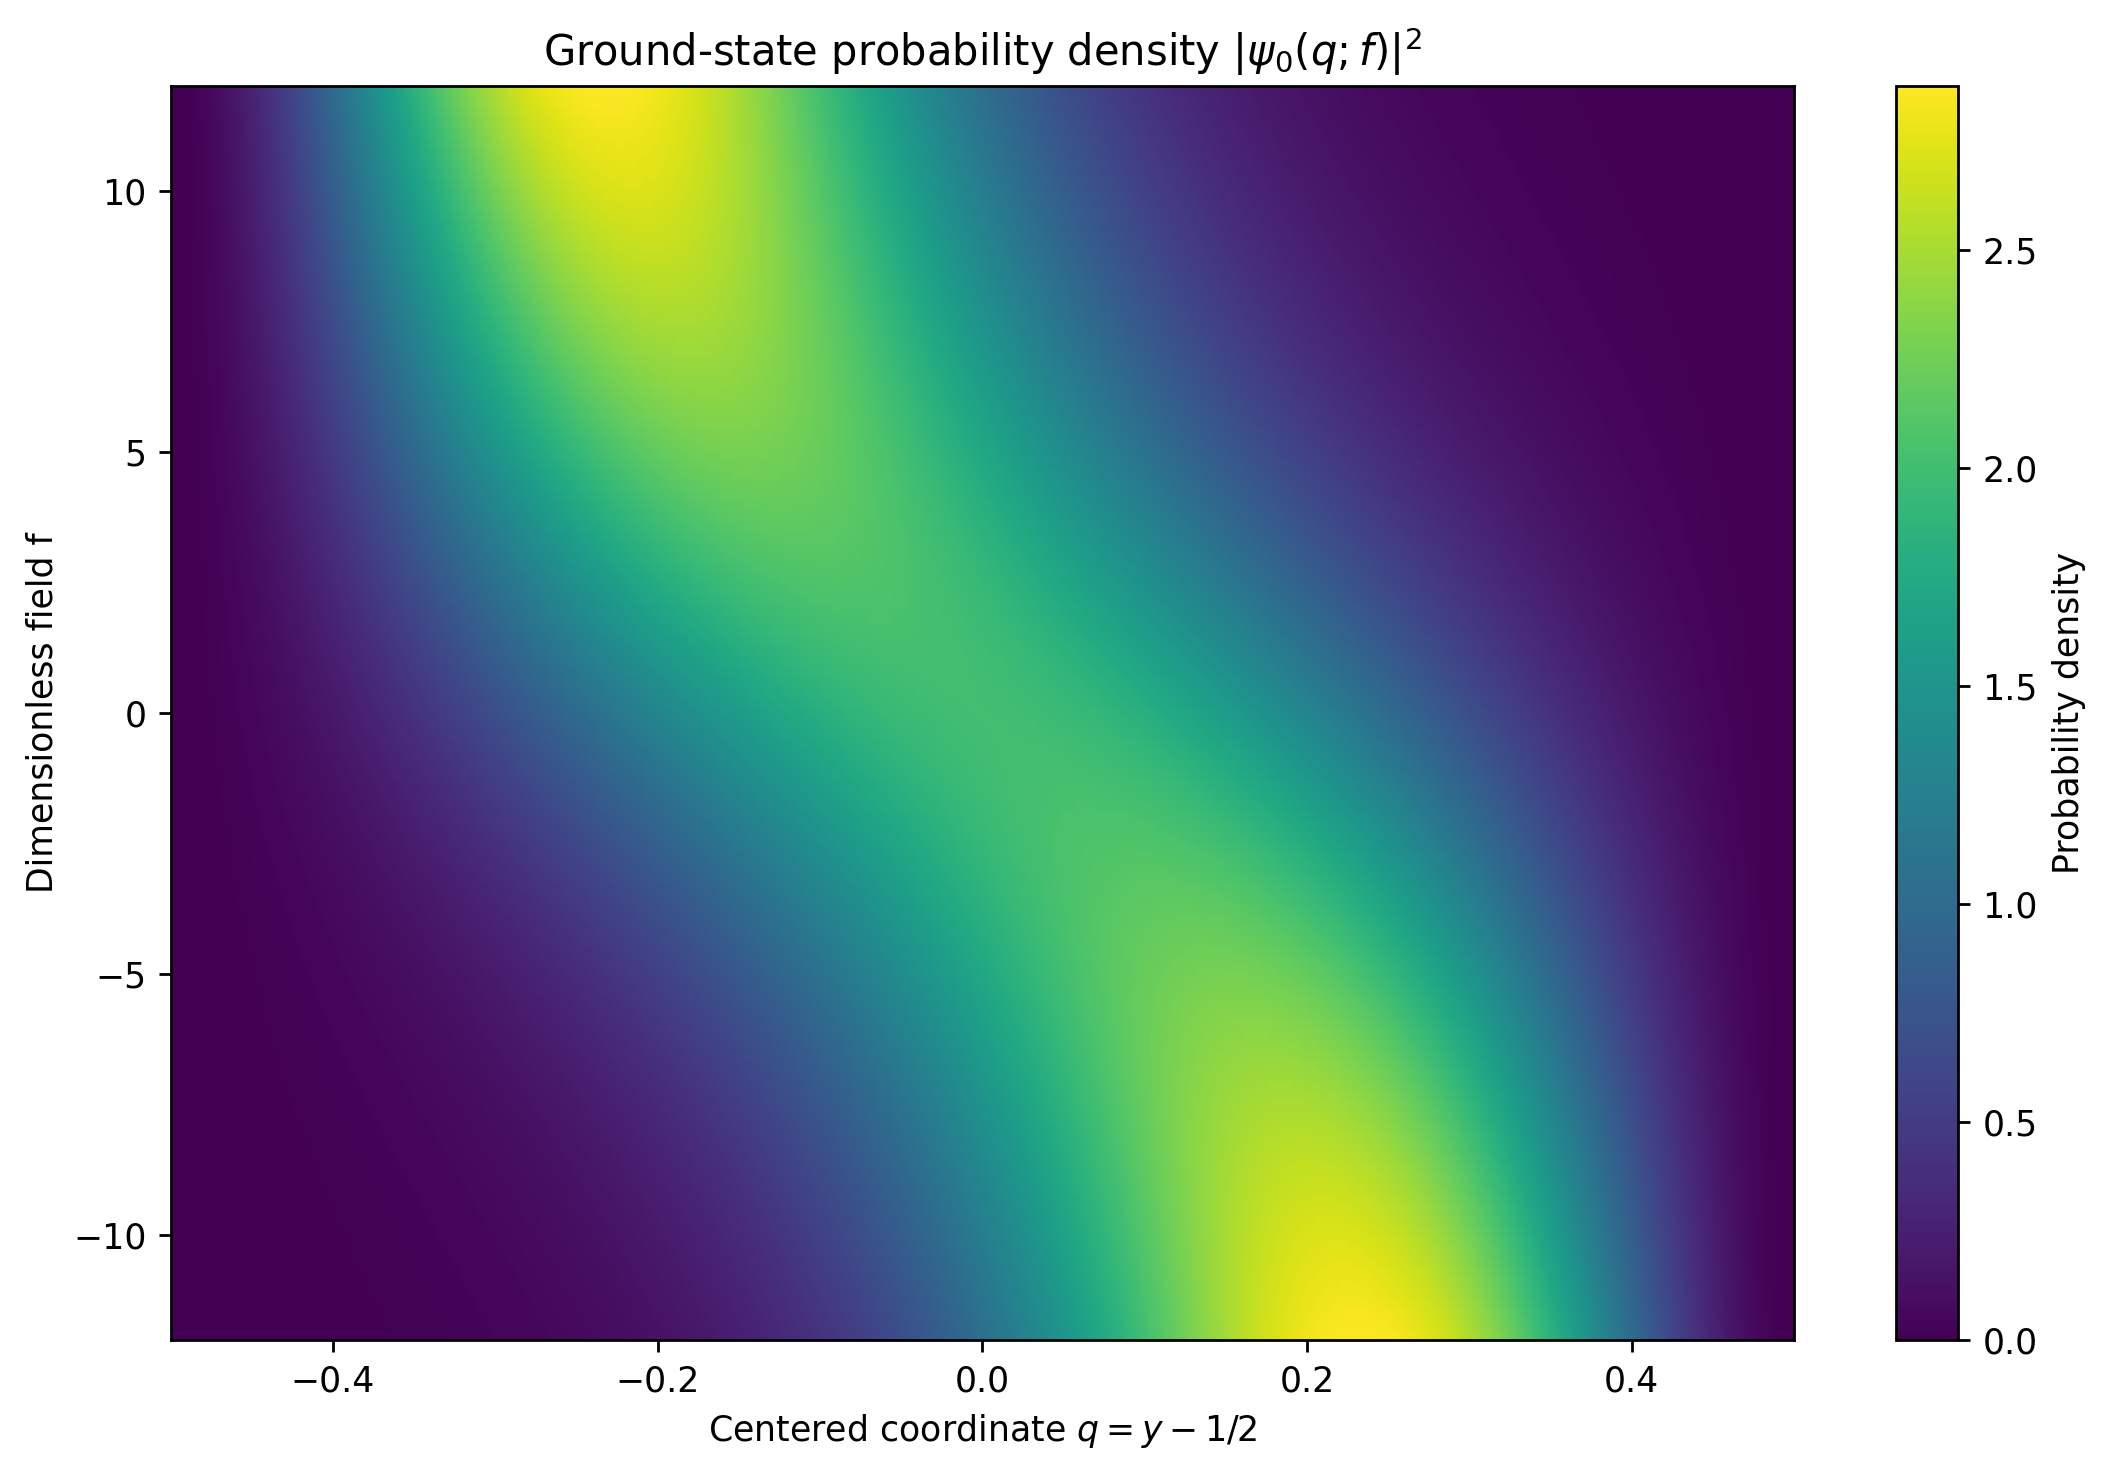

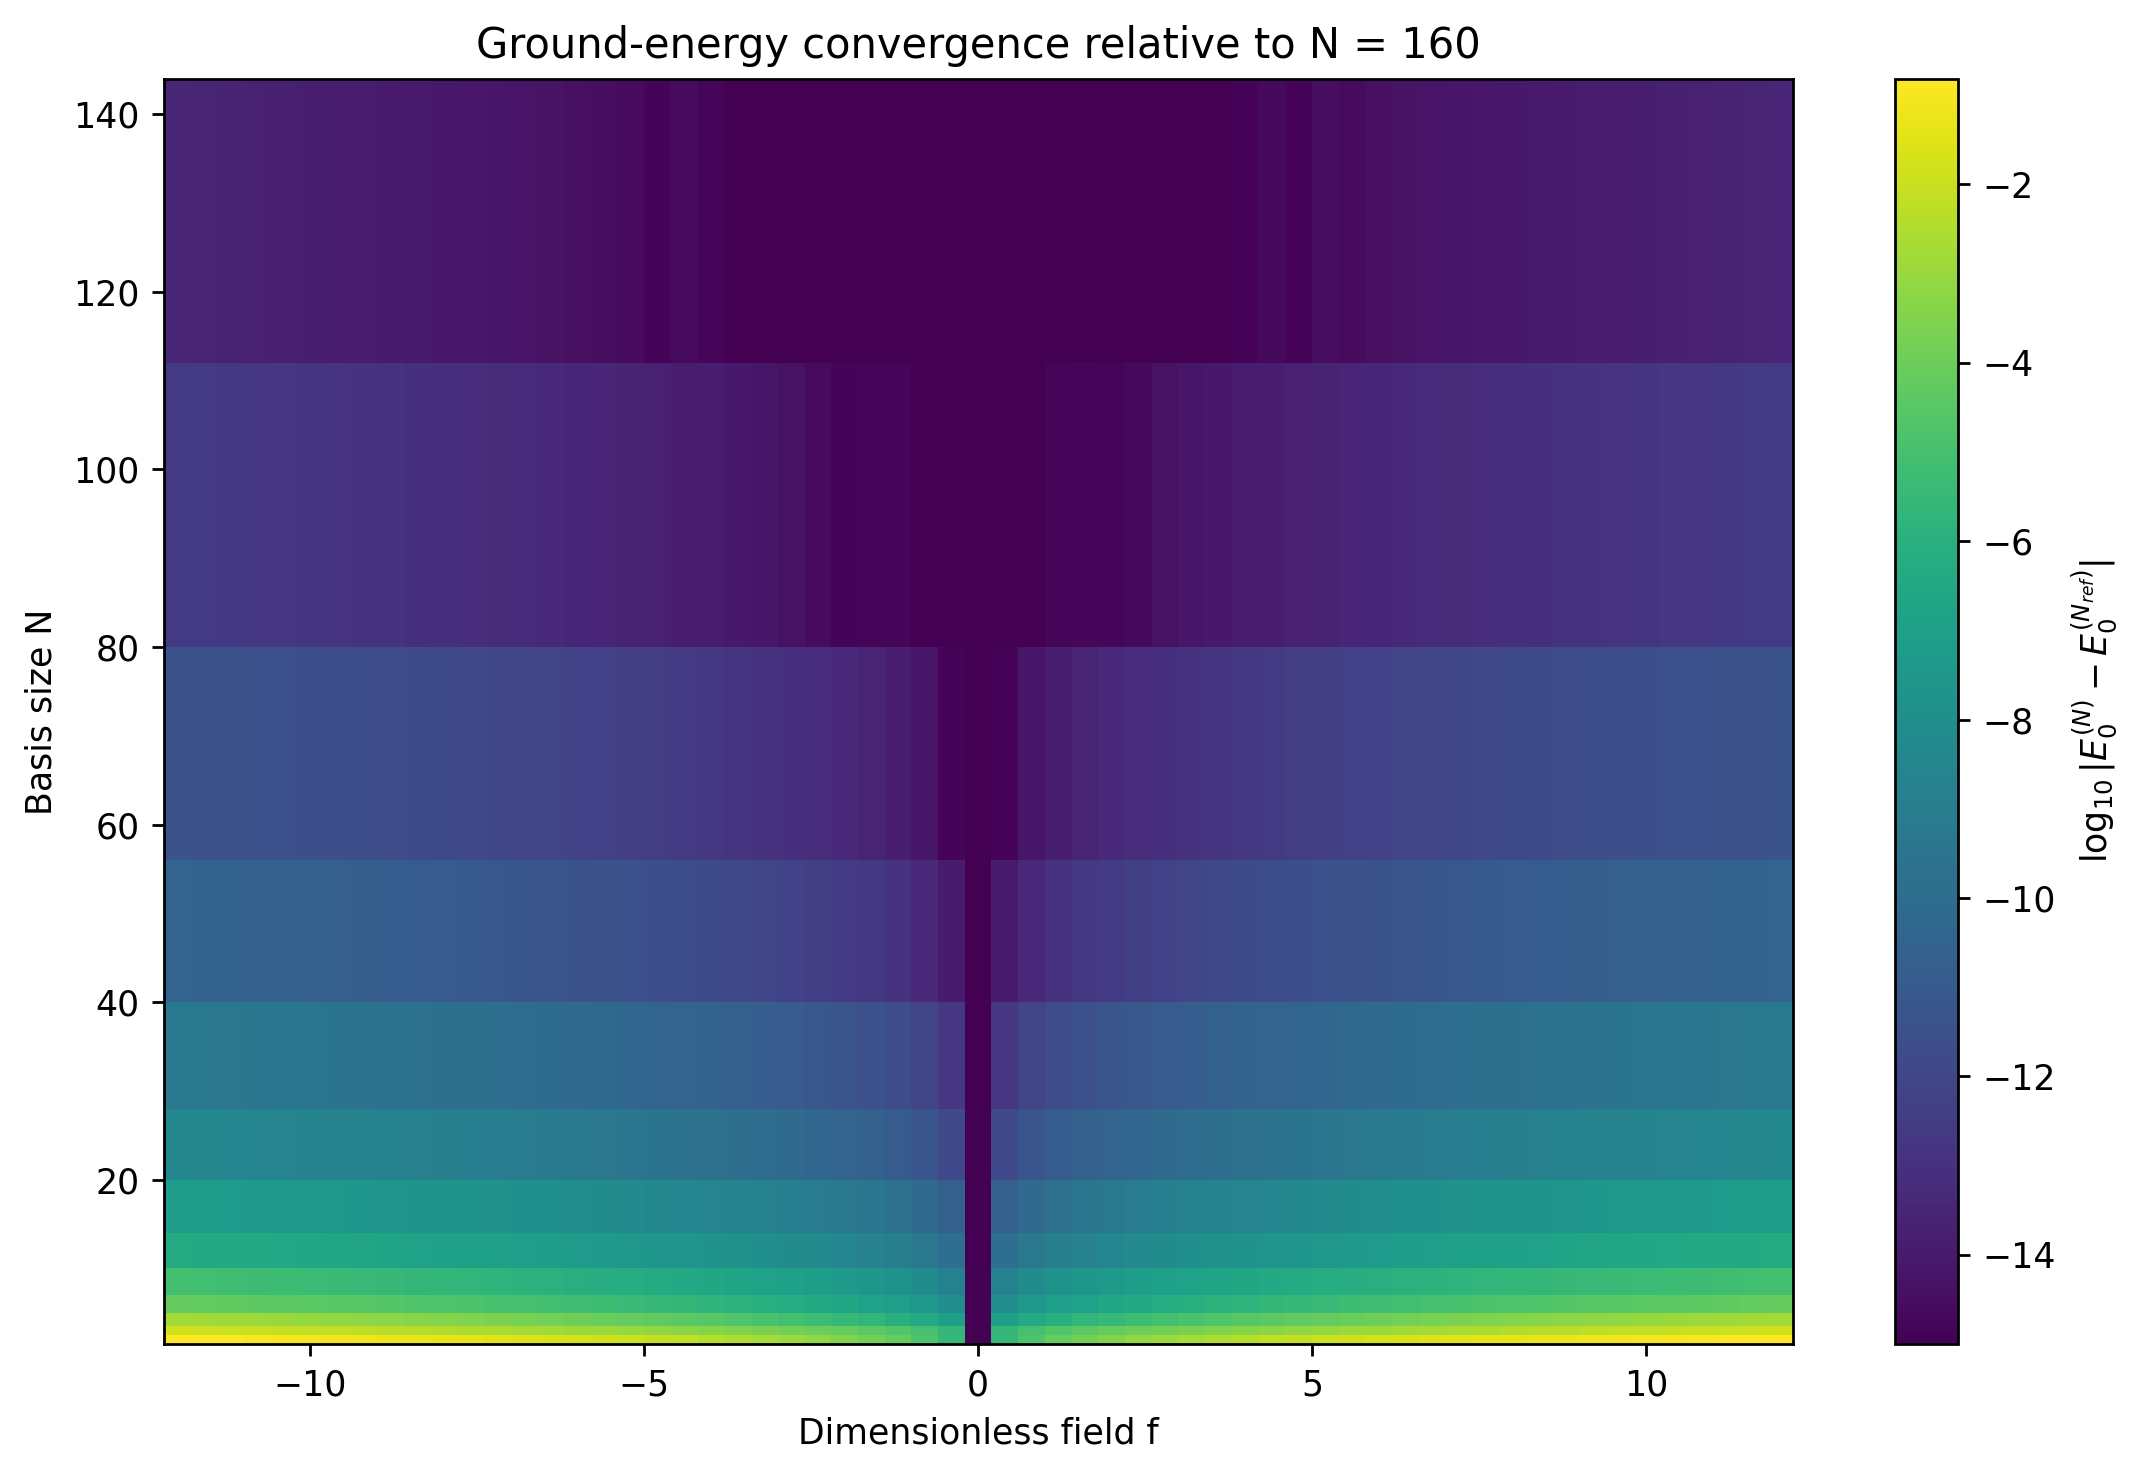

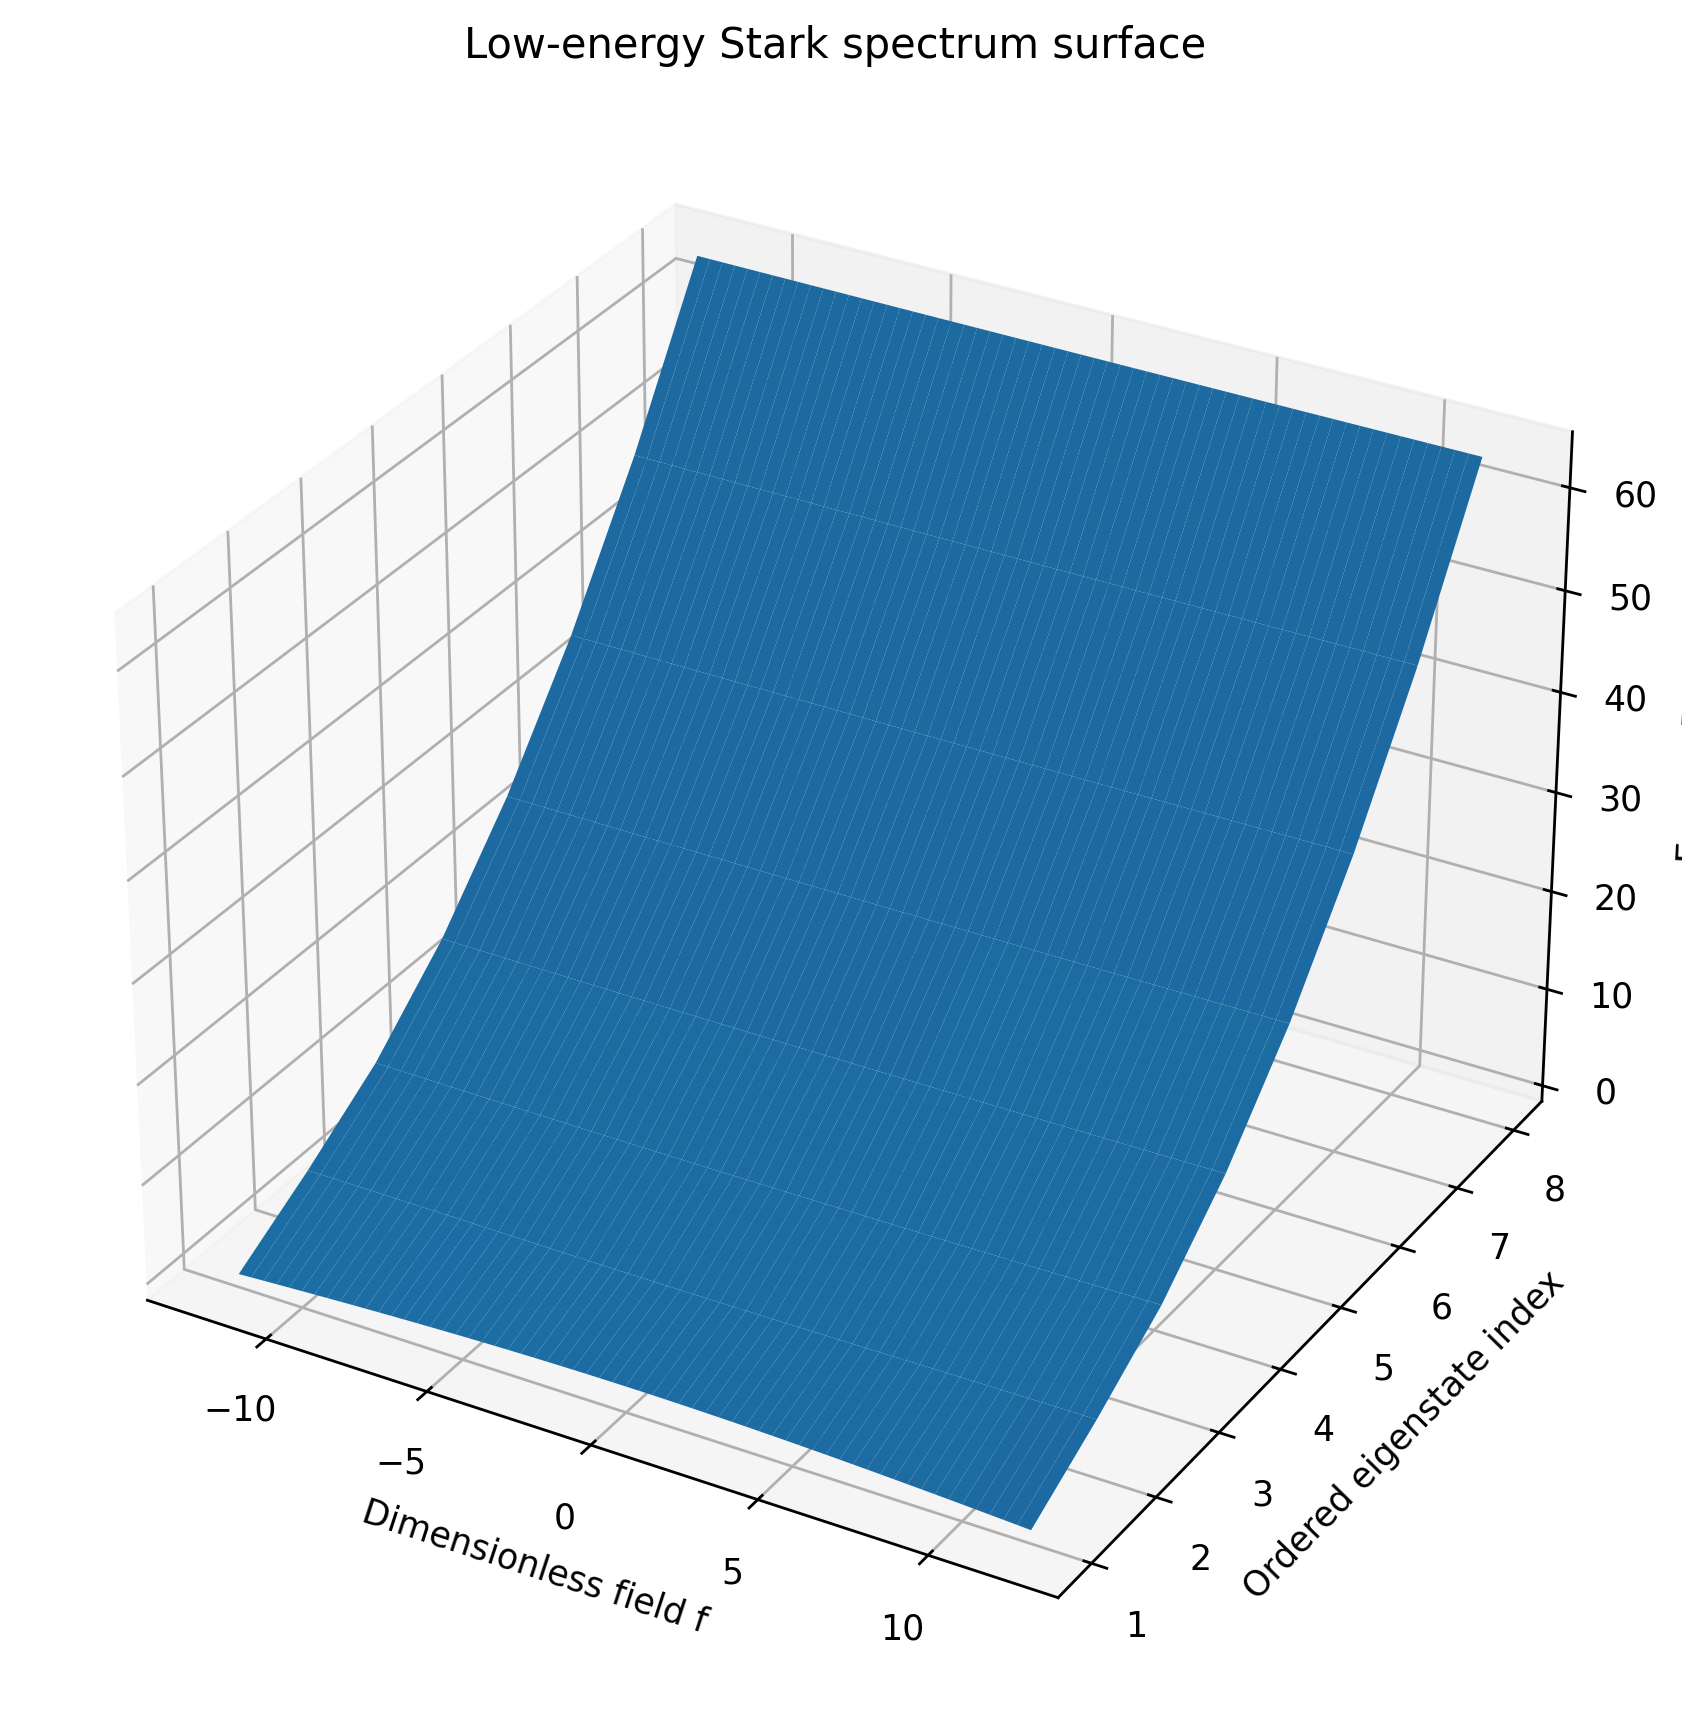

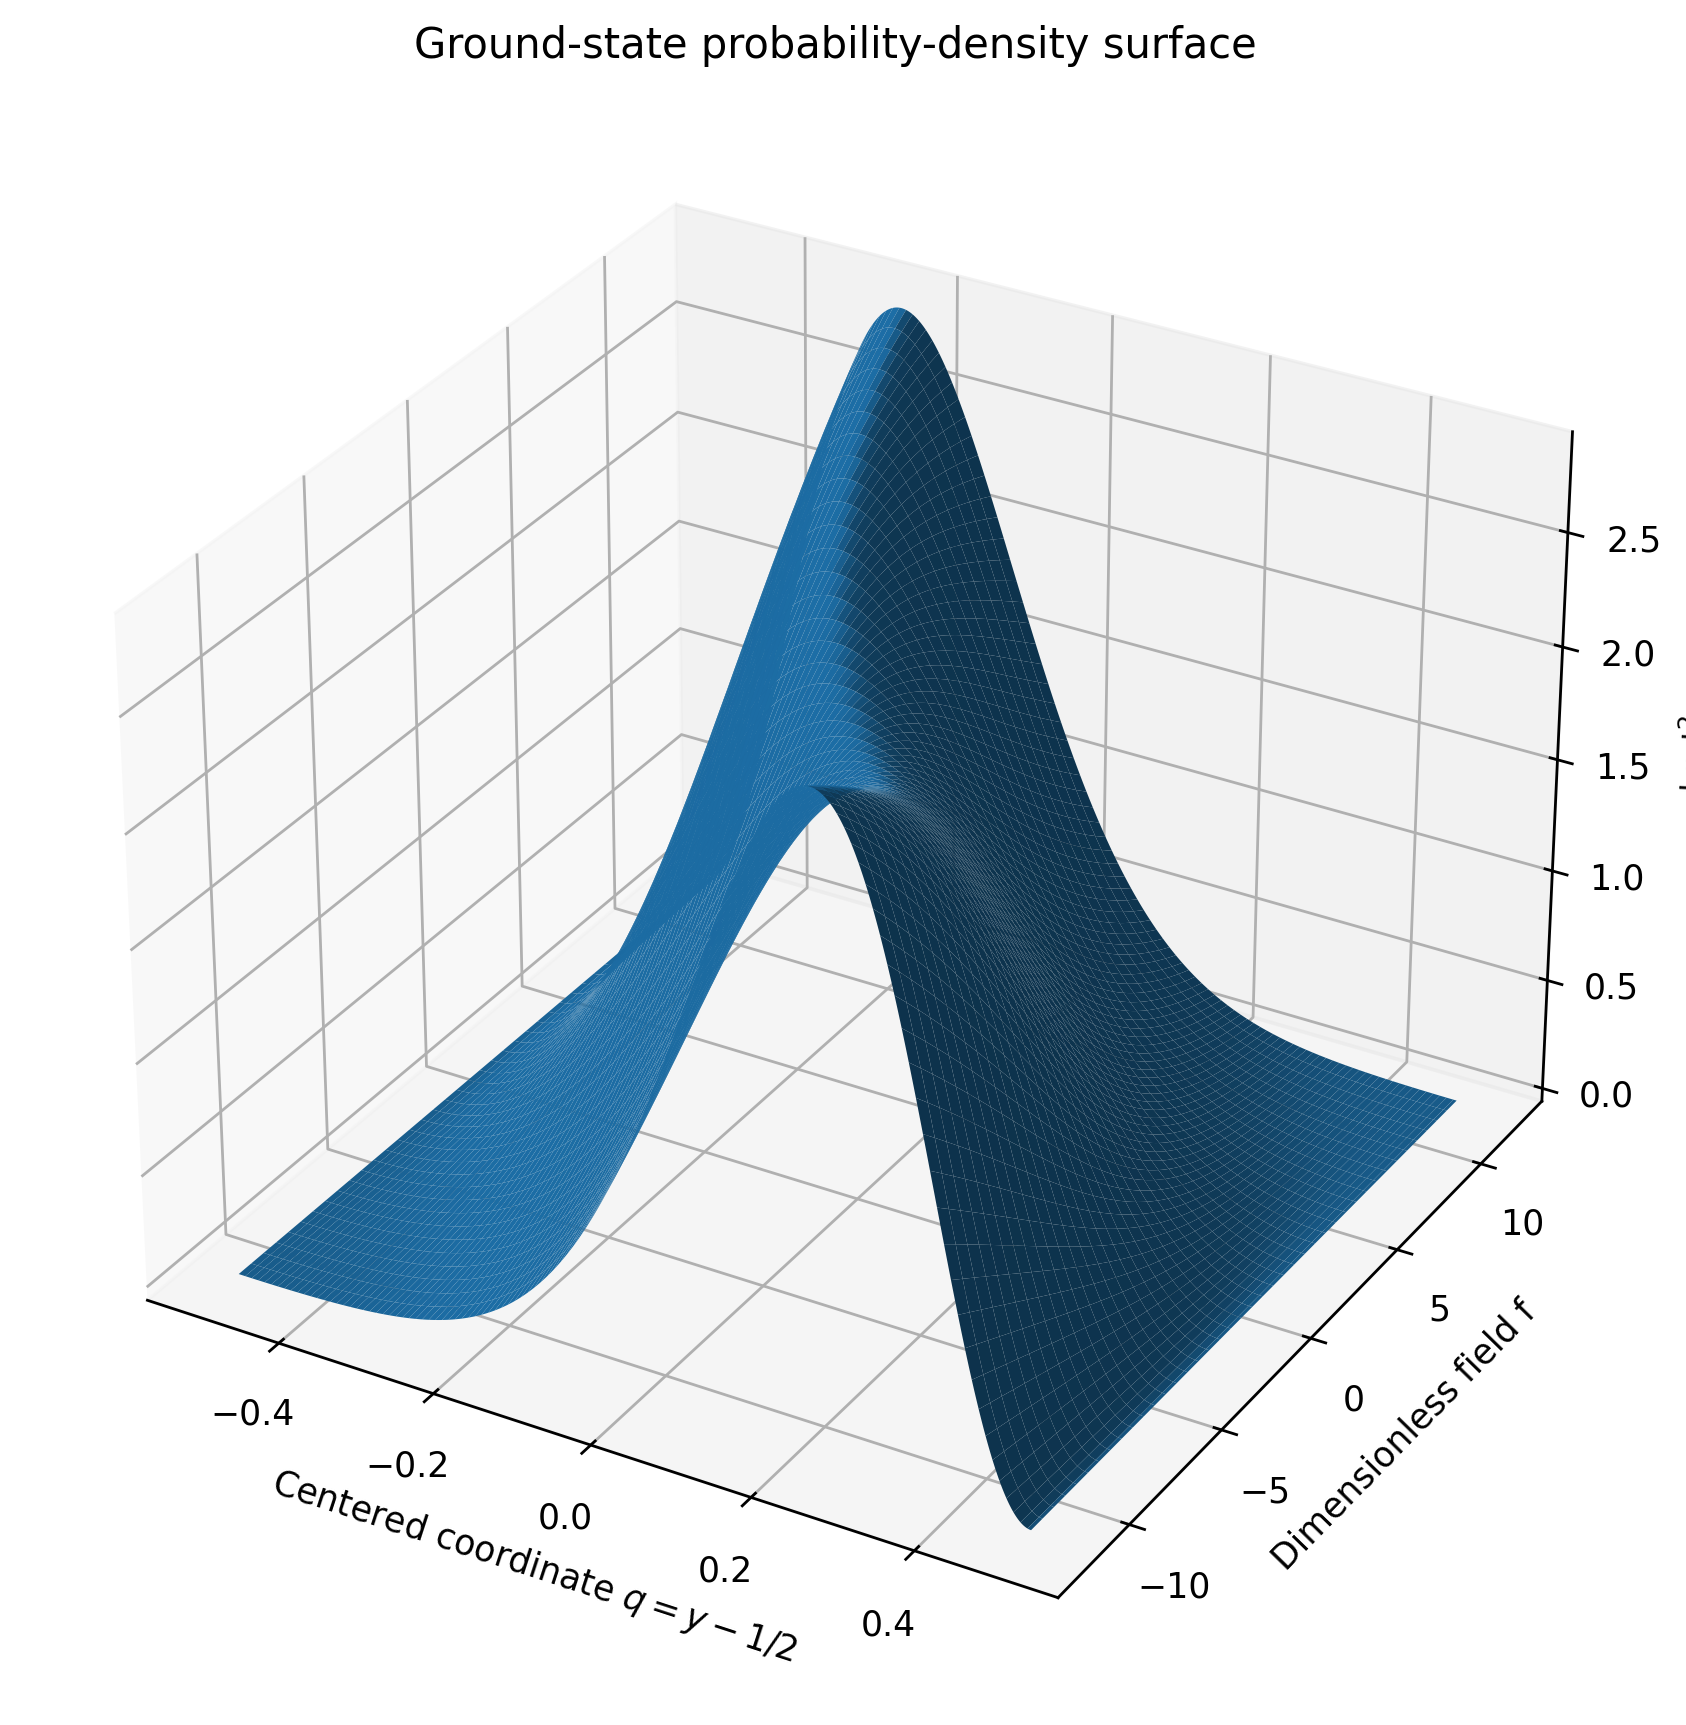

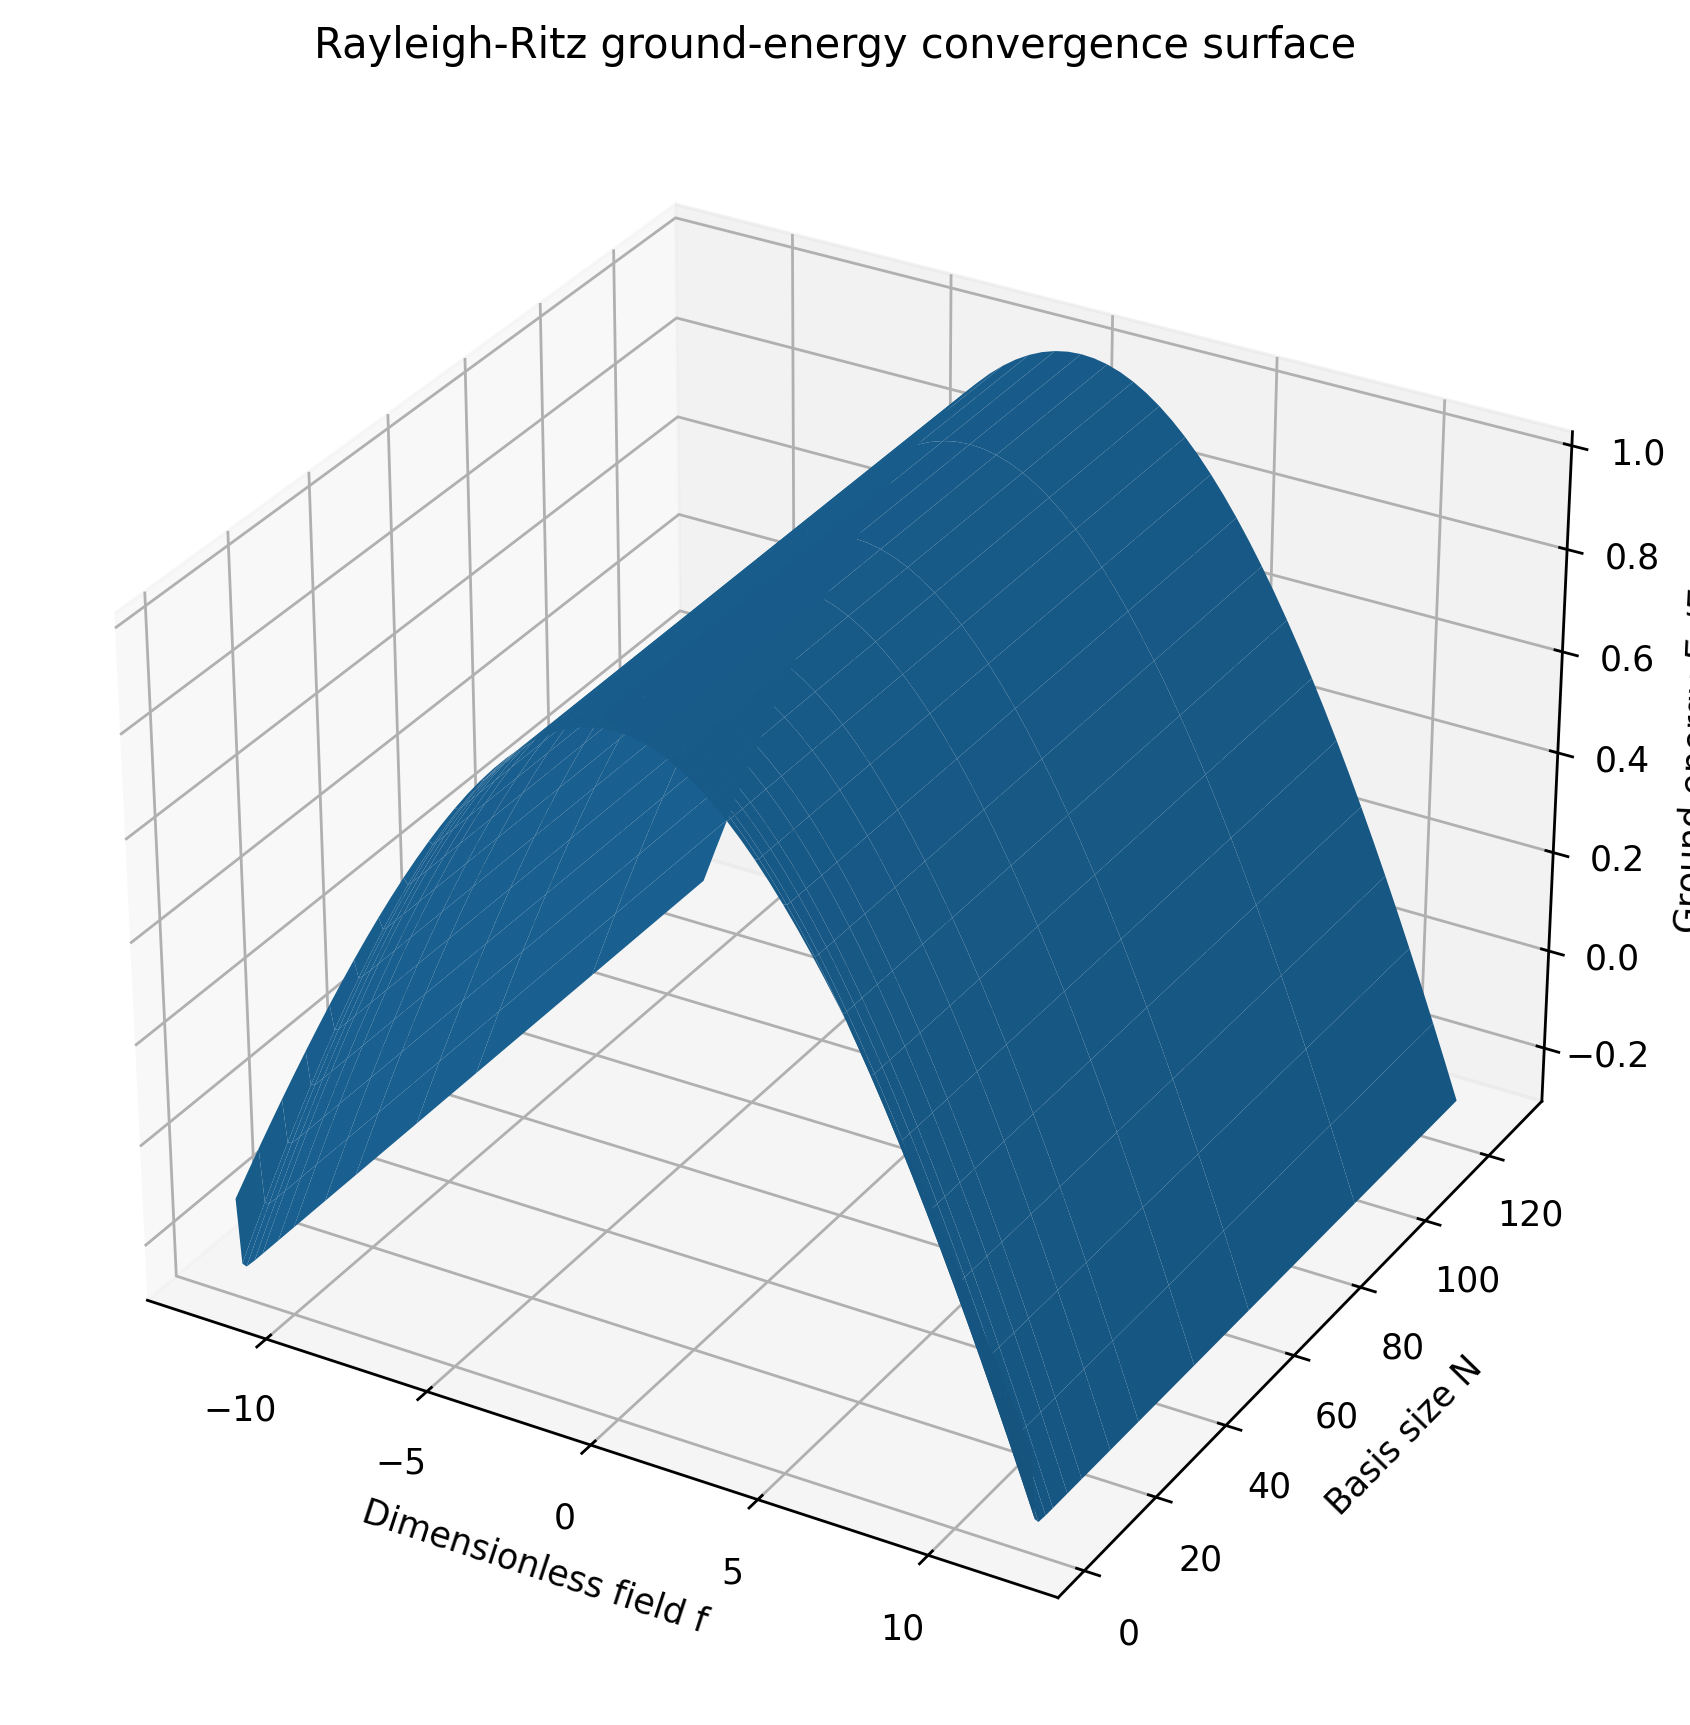

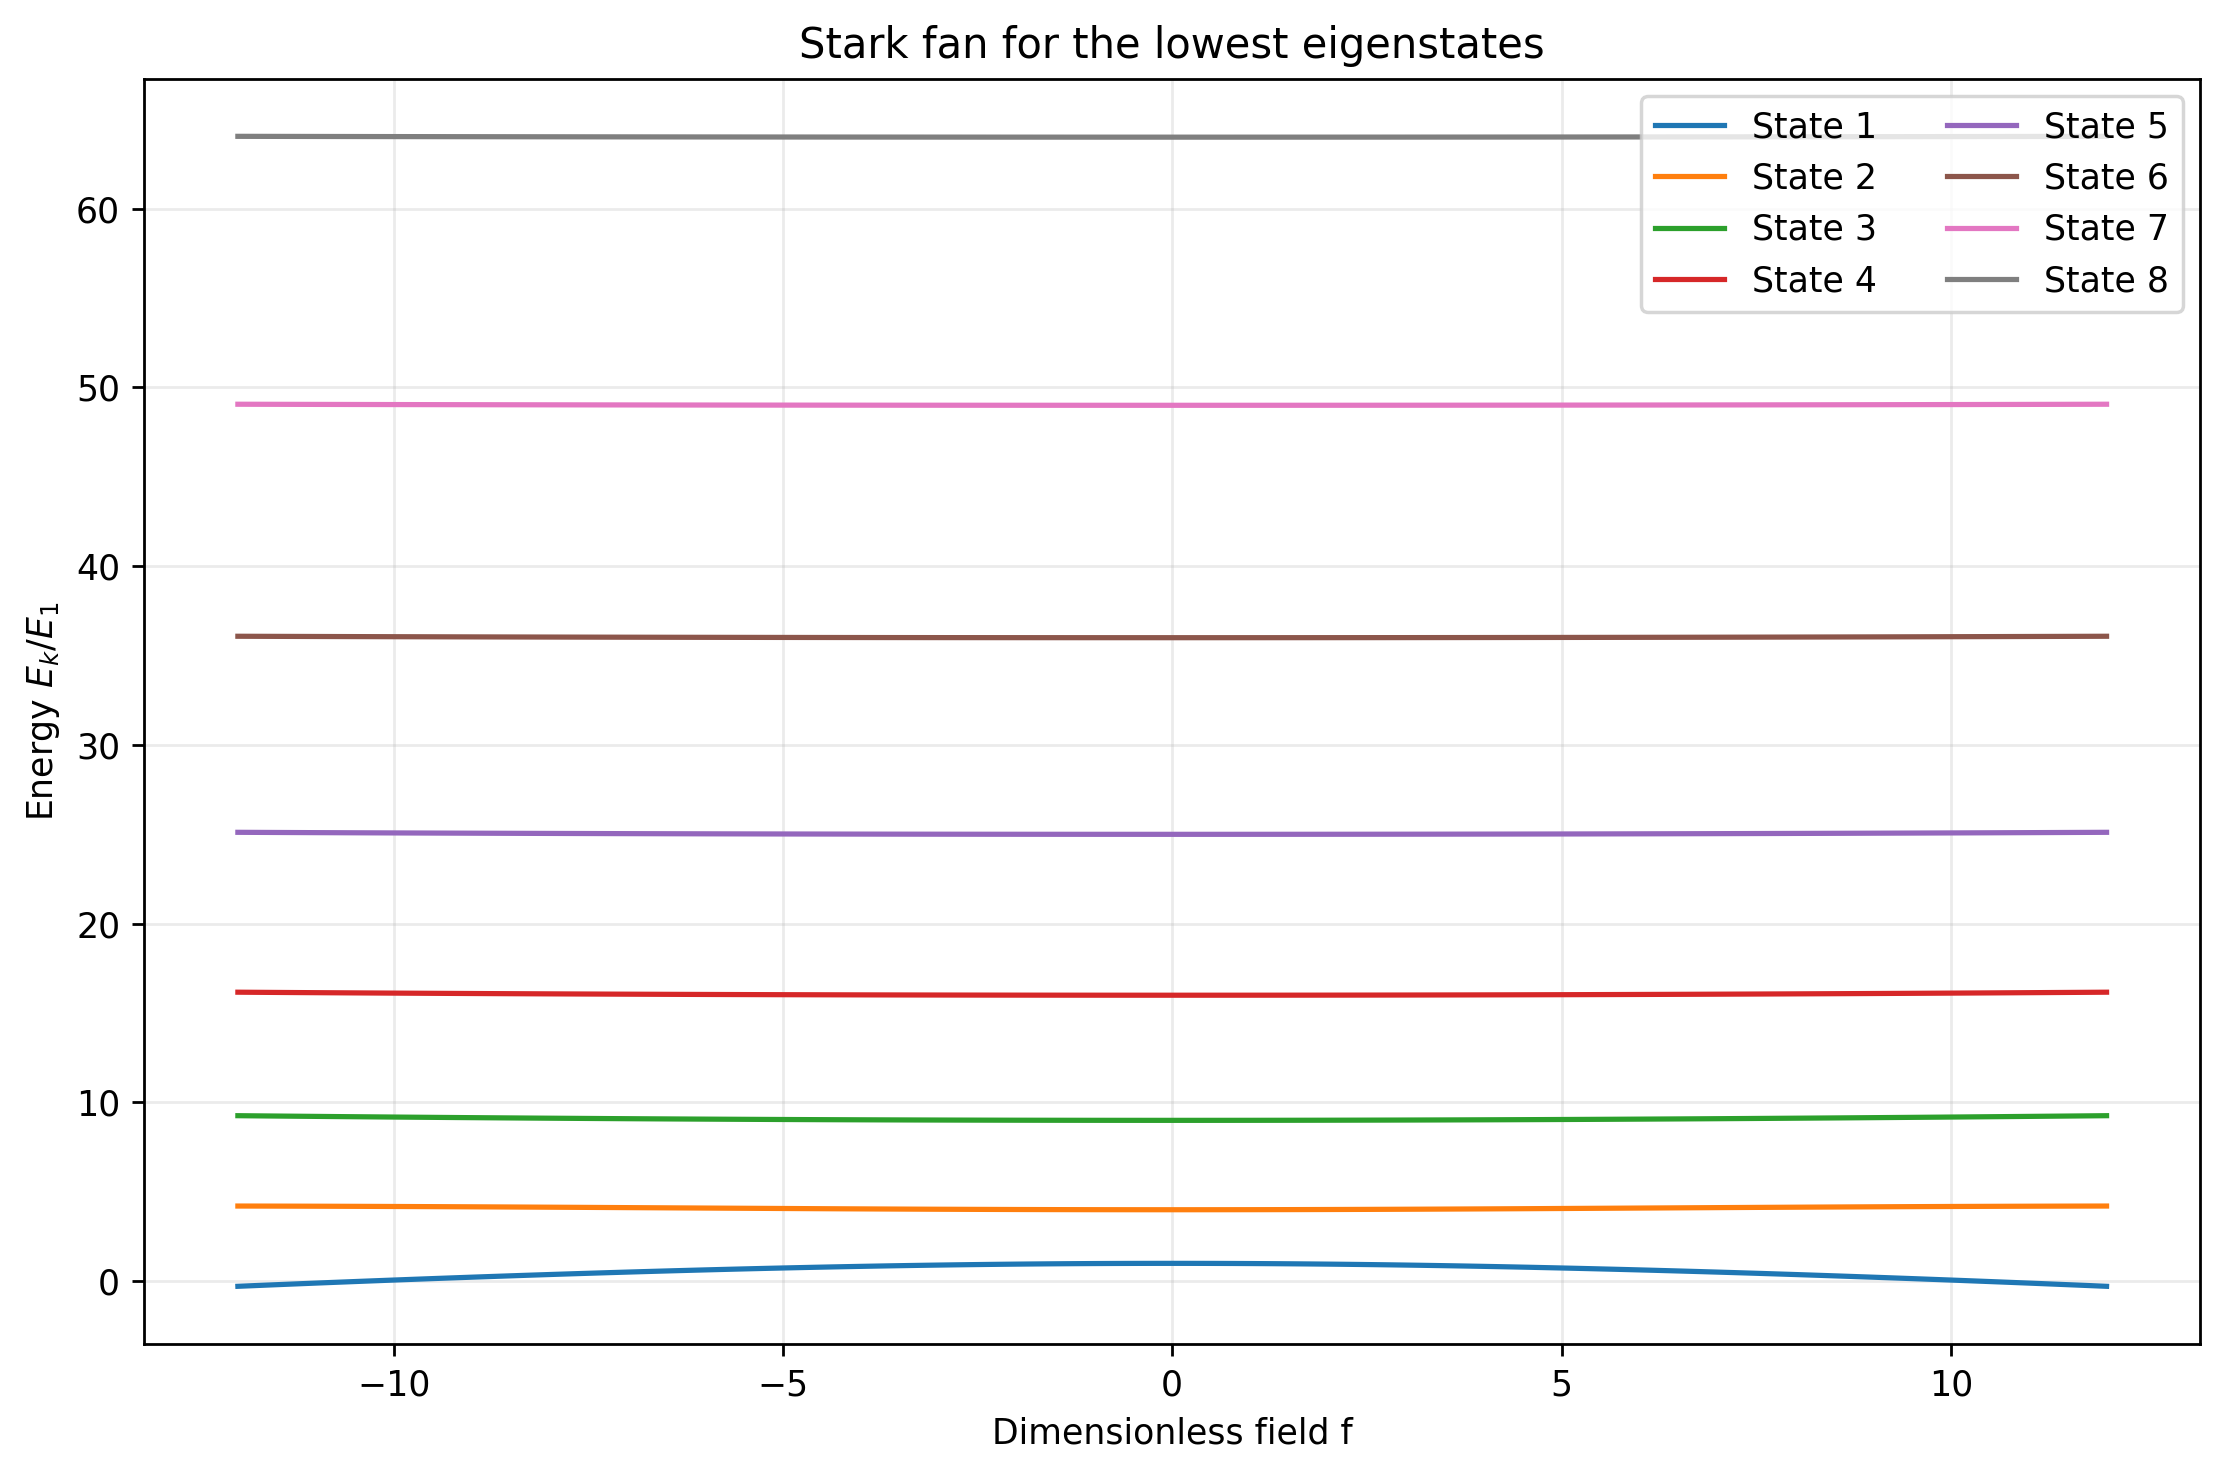

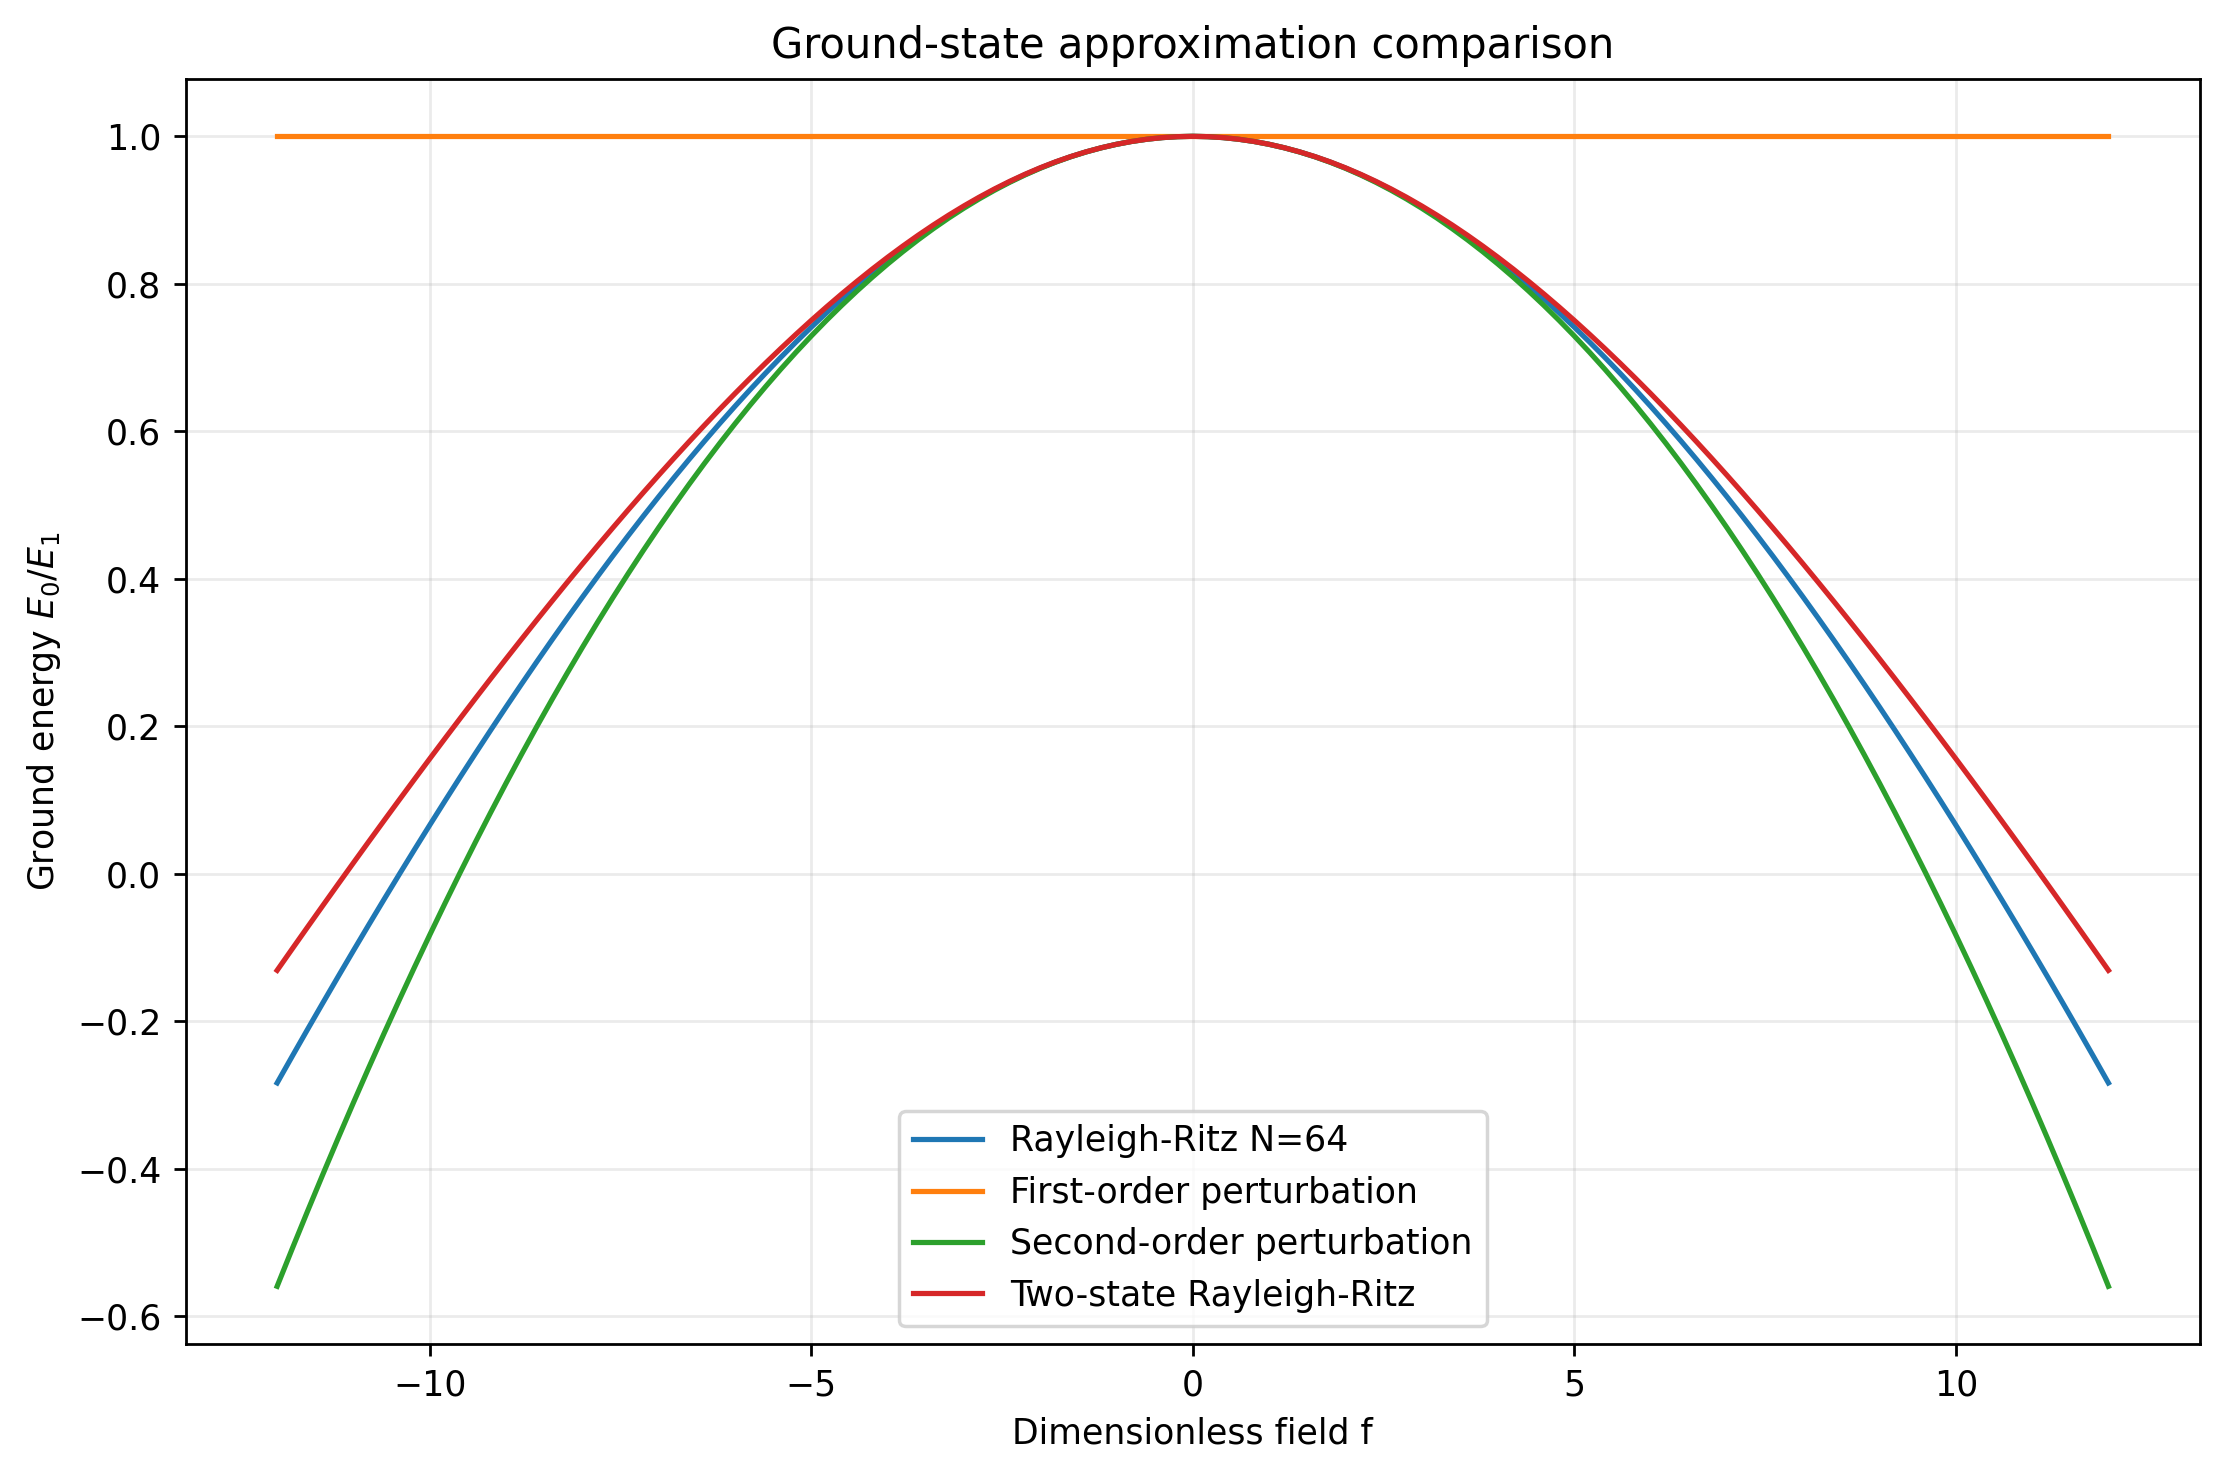

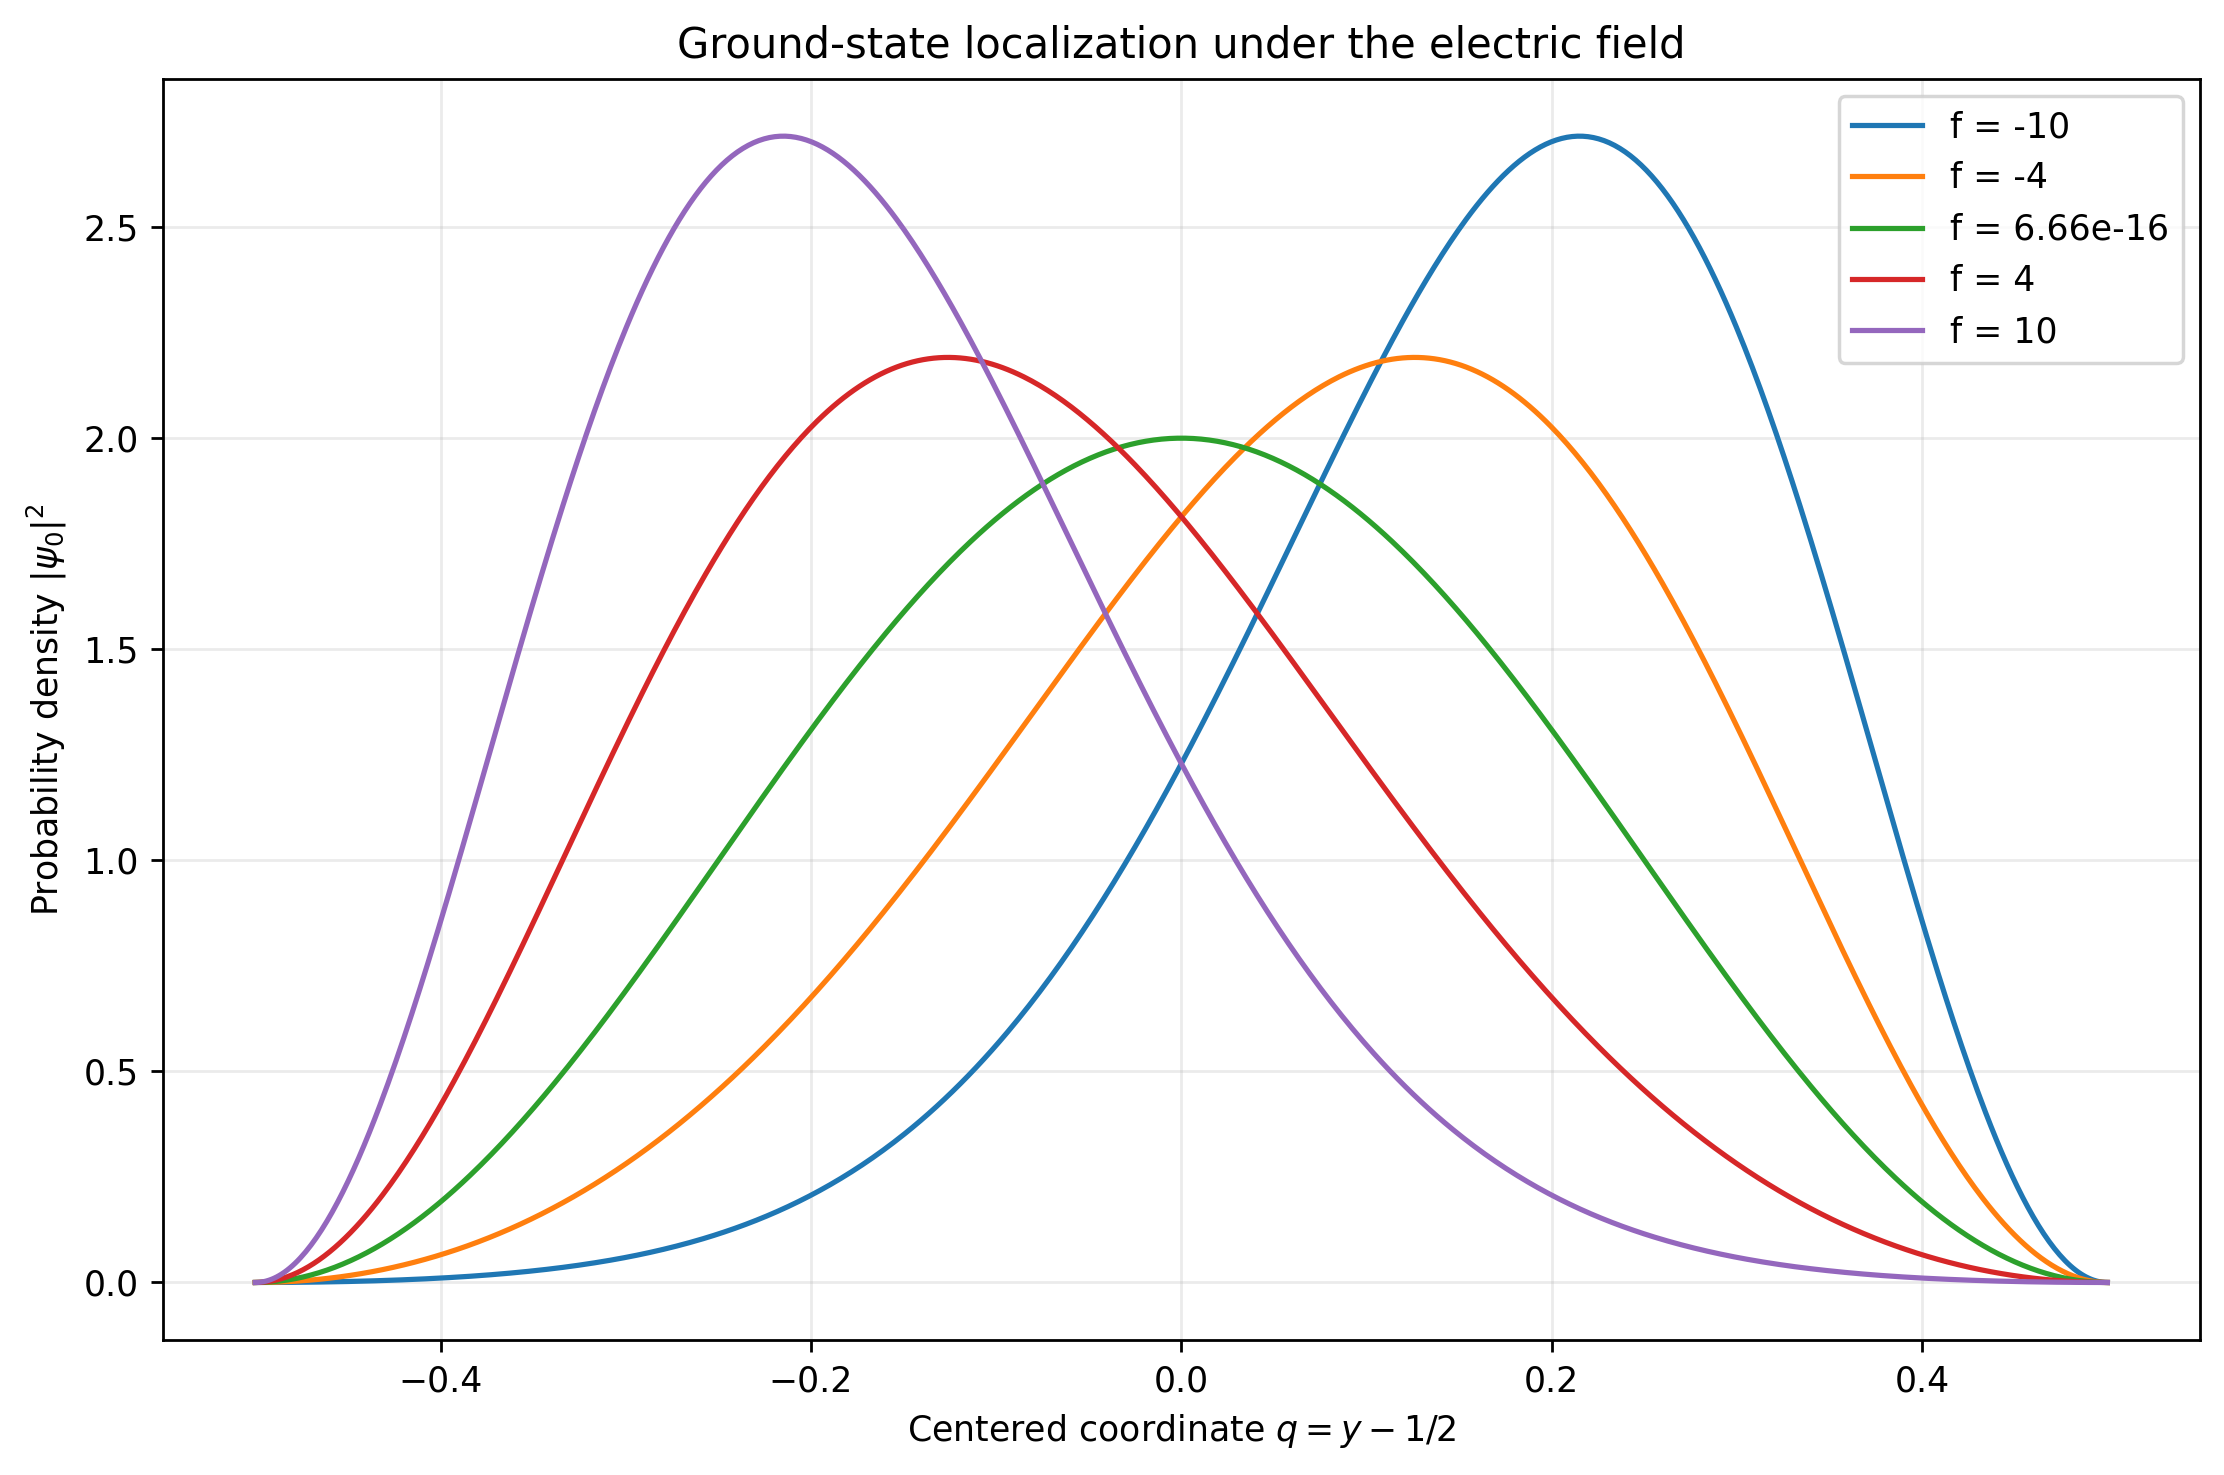

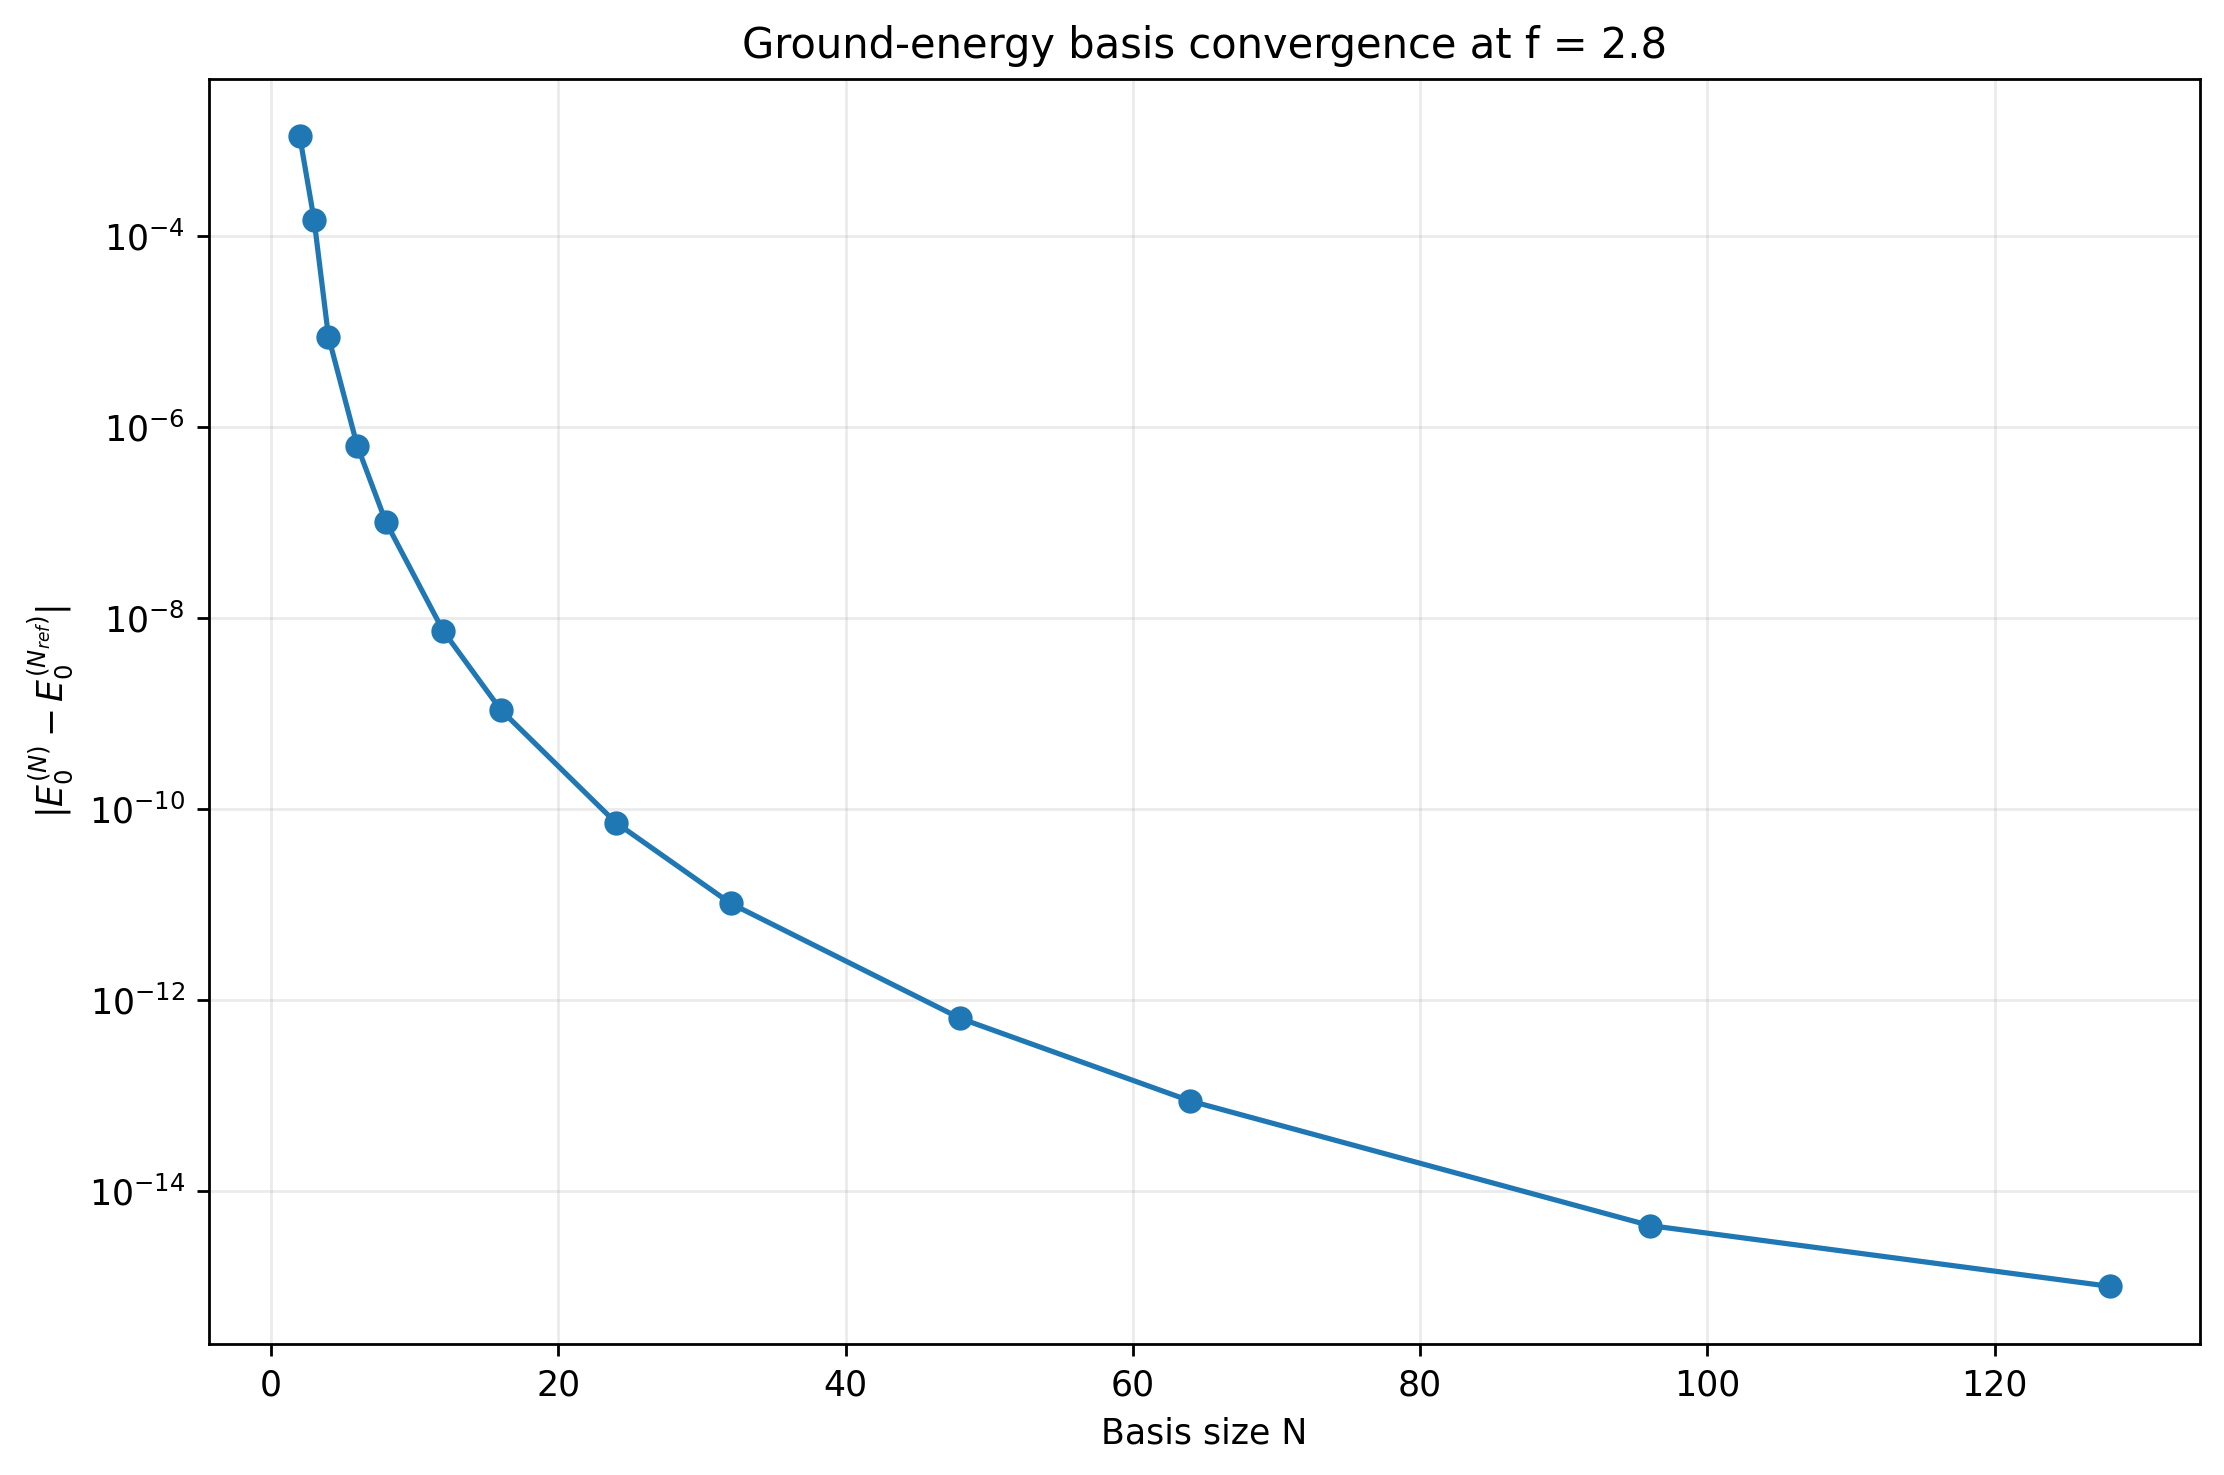

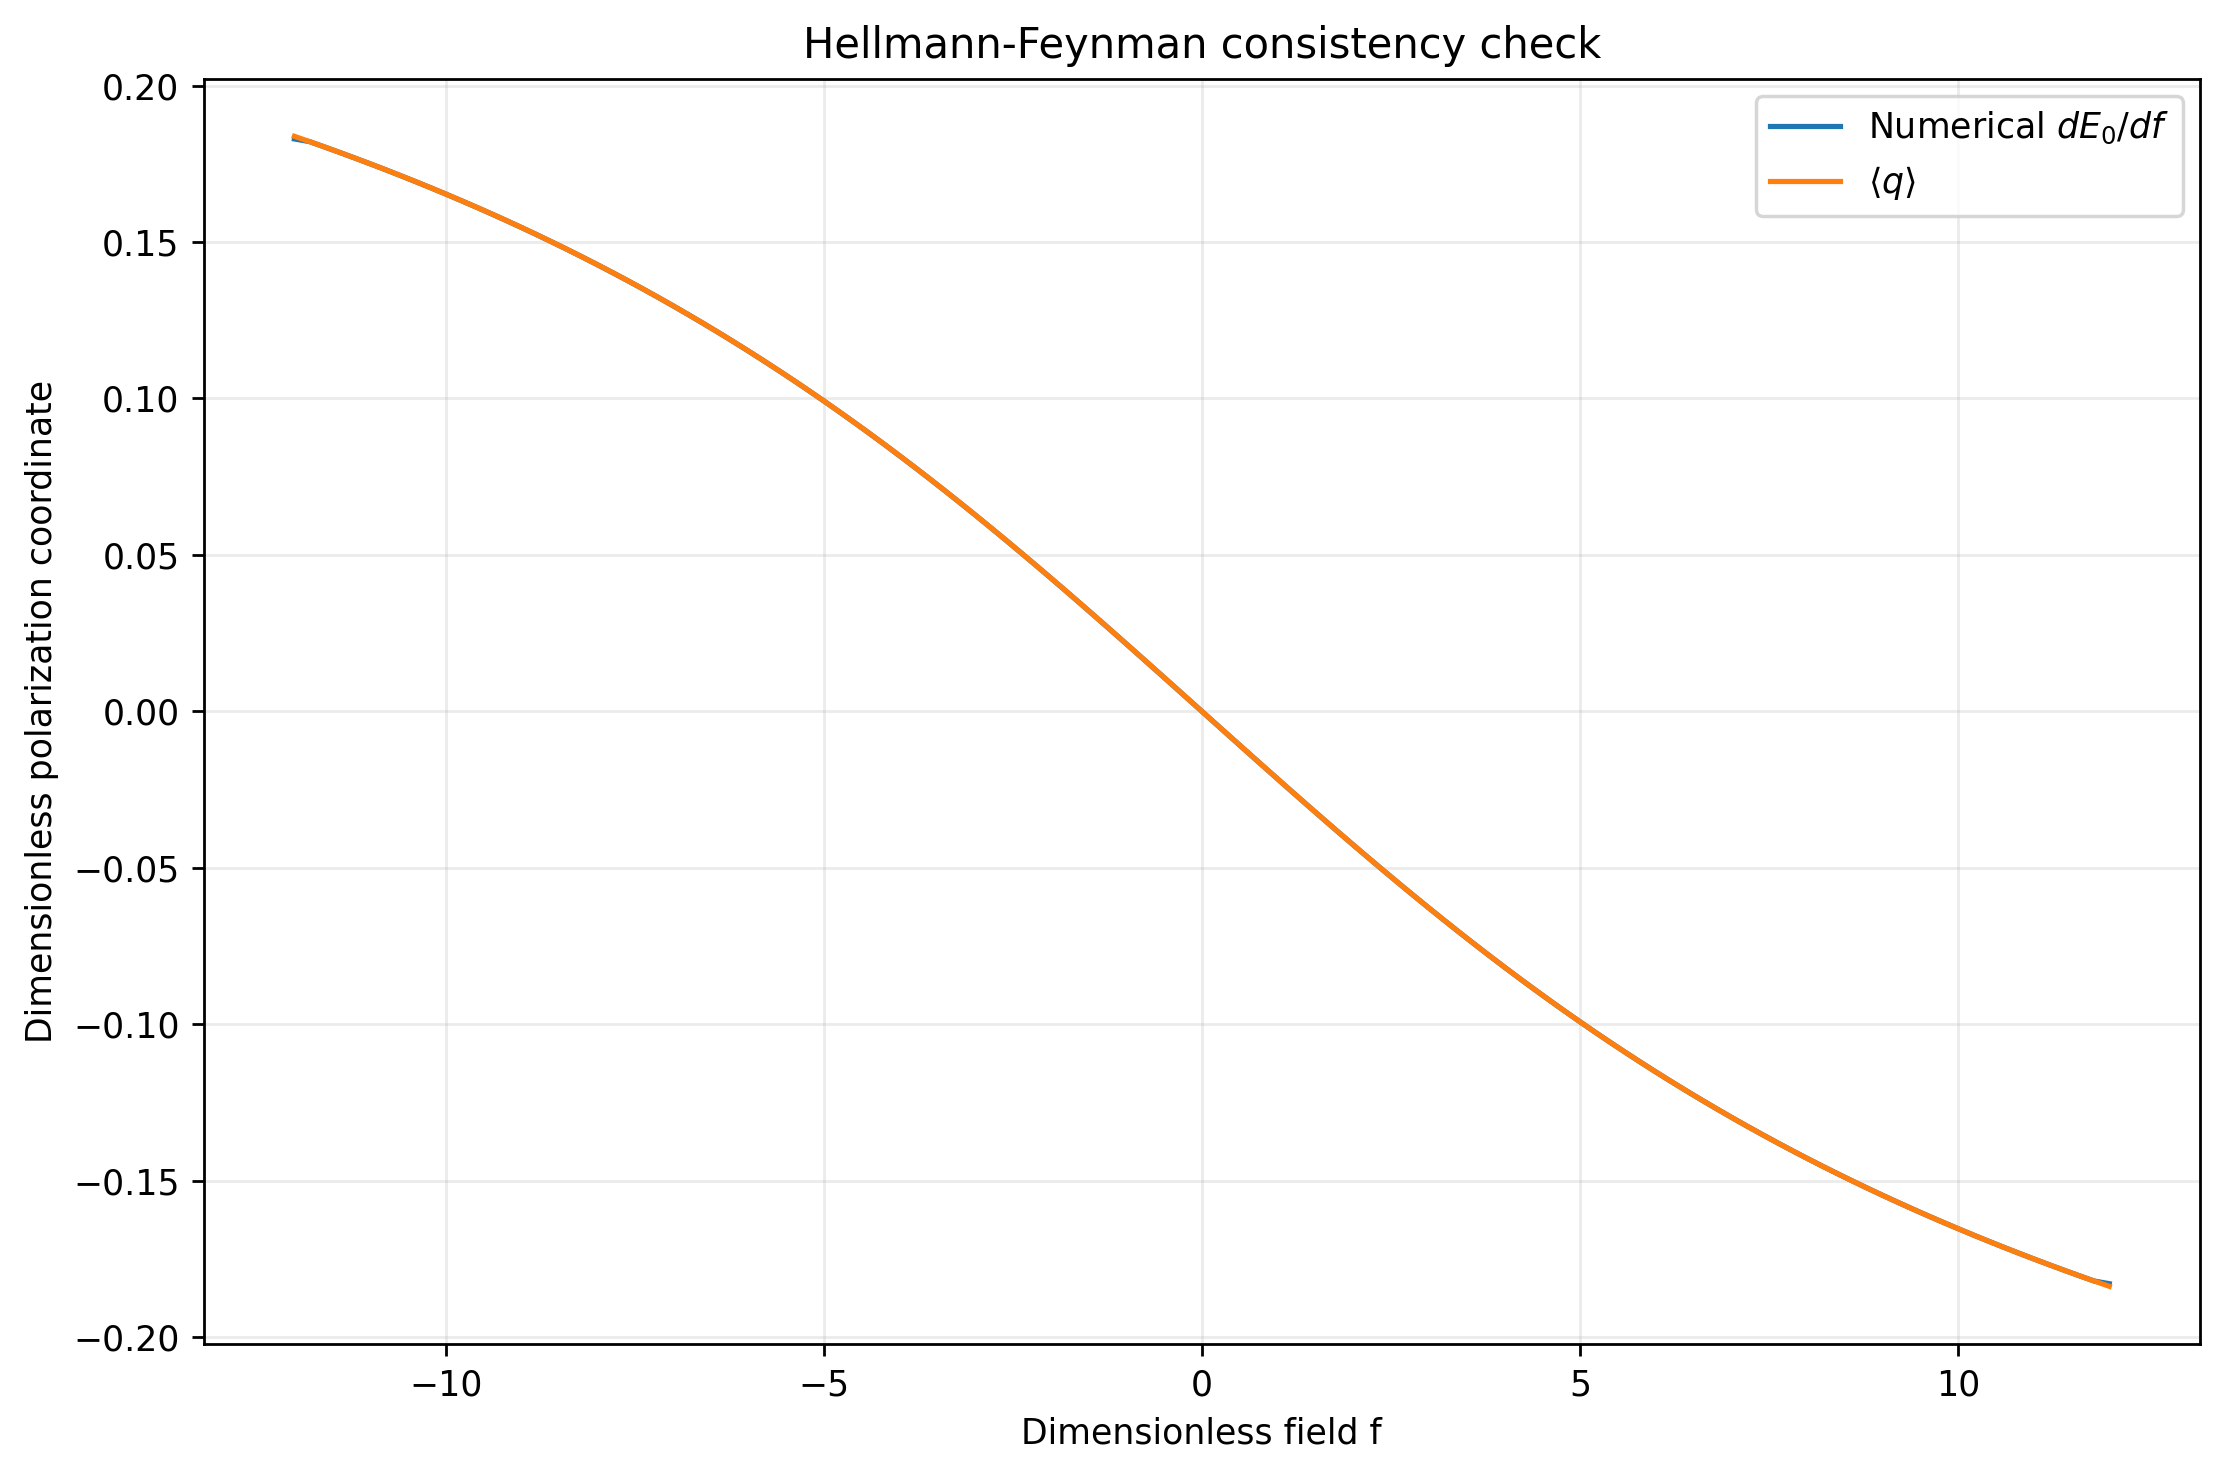

In [19]:
"""GPU study of the Stark effect in a one-dimensional infinite well.

The dimensionless Hamiltonian is

    H / E_1 = -(1 / pi^2) d^2/dy^2 + f (y - 1/2),

where y = x / L lies in [0, 1], E_1 = pi^2 hbar^2 / (2 m L^2), and
f = q E L / E_1 is the dimensionless electric-field strength. The sine basis
phi_n(y) = sqrt(2) sin(n pi y) gives unperturbed energies n^2.

The calculation uses CuPy for Hamiltonian construction, batched eigensolution,
state reconstruction, convergence studies, perturbation theory, and numerical
diagnostics.
"""

from dataclasses import dataclass
from typing import Sequence

import cupy as cp
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np


# =============================================================================
# Control knobs
# =============================================================================
ELECTRIC_FIELD_STRENGTH: float = 3.0
BASIS_SIZE: int = 64
NUM_EIGENSTATES: int = 8
PERTURBATION_SUMMATION_LIMIT: int = 20_000

FIELD_MIN: float = -12.0
FIELD_MAX: float = 12.0
NUM_FIELD_POINTS: int = 121
POSITION_POINTS: int = 700

MATRIX_DISPLAY_BASIS_SIZE: int = 24
CONVERGENCE_BASIS_SIZES: tuple[int, ...] = (
    2,
    3,
    4,
    6,
    8,
    12,
    16,
    24,
    32,
    48,
    64,
    96,
    128,
)
REFERENCE_BASIS_SIZE: int = 160
CONVERGENCE_FIELD_POINTS: int = 61
SELECTED_FIELDS: tuple[float, ...] = (-10.0, -4.0, 0.0, 4.0, 10.0)

PLOT_HAMILTONIAN_HEATMAP: bool = True
PLOT_PROBABILITY_HEATMAP: bool = True
PLOT_CONVERGENCE_HEATMAP: bool = True
PLOT_ENERGY_SPECTRUM_SURFACE: bool = True
PLOT_PROBABILITY_SURFACE: bool = True
PLOT_CONVERGENCE_SURFACE: bool = True
PLOT_STARK_FAN: bool = True
PLOT_APPROXIMATION_COMPARISON: bool = True
PLOT_GROUND_STATE_DENSITIES: bool = True
PLOT_BASIS_CONVERGENCE: bool = True
PLOT_HELLMANN_FEYNMAN_CHECK: bool = True

FLOAT_DTYPE = cp.float64
FIGURE_DPI: int = 250
FIGURE_SIZE_2D: tuple[float, float] = (9.0, 6.0)
FIGURE_SIZE_3D: tuple[float, float] = (10.0, 7.0)
SURFACE_ROW_STRIDE: int = 3
SURFACE_COLUMN_STRIDE: int = 6
LOG_ERROR_FLOOR: float = 1.0e-15

mpl.rcParams["figure.dpi"] = FIGURE_DPI
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25


@dataclass(frozen=True)
class FieldSweepResults:
    """Stores fixed-basis electric-field sweep results on GPU memory."""

    fields: cp.ndarray
    coordinates: cp.ndarray
    energies: cp.ndarray
    eigenvectors: cp.ndarray
    wavefunctions: cp.ndarray
    densities: cp.ndarray
    coordinate_expectation: cp.ndarray
    density_norms: cp.ndarray


@dataclass(frozen=True)
class ConvergenceResults:
    """Stores basis-size convergence data on GPU memory."""

    fields: cp.ndarray
    basis_sizes: np.ndarray
    ground_energy_surface: cp.ndarray
    reference_ground_energies: cp.ndarray
    absolute_errors: cp.ndarray


def validate_control_knobs() -> None:
    """Checks simulation controls before allocating GPU arrays.

    Raises:
        ValueError: If a control knob is inconsistent or outside its domain.
    """
    if BASIS_SIZE < 2:
        raise ValueError("BASIS_SIZE must be at least 2.")
    if NUM_EIGENSTATES < 1 or NUM_EIGENSTATES > BASIS_SIZE:
        raise ValueError(
            "NUM_EIGENSTATES must lie between 1 and BASIS_SIZE."
        )
    if POSITION_POINTS < 3:
        raise ValueError("POSITION_POINTS must be at least 3.")
    if NUM_FIELD_POINTS < 3:
        raise ValueError("NUM_FIELD_POINTS must be at least 3.")
    if FIELD_MIN >= FIELD_MAX:
        raise ValueError("FIELD_MIN must be smaller than FIELD_MAX.")
    if REFERENCE_BASIS_SIZE < max(CONVERGENCE_BASIS_SIZES):
        raise ValueError(
            "REFERENCE_BASIS_SIZE must be at least the largest convergence "
            "basis size."
        )
    if any(size < 2 for size in CONVERGENCE_BASIS_SIZES):
        raise ValueError("Every convergence basis size must be at least 2.")
    if CONVERGENCE_FIELD_POINTS < 3:
        raise ValueError("CONVERGENCE_FIELD_POINTS must be at least 3.")
    if PERTURBATION_SUMMATION_LIMIT < 2:
        raise ValueError(
            "PERTURBATION_SUMMATION_LIMIT must be at least 2."
        )


def get_gpu_name() -> str:
    """Returns the active CUDA device name."""
    device_id = cp.cuda.Device().id
    properties = cp.cuda.runtime.getDeviceProperties(device_id)
    name = properties.get("name", properties.get(b"name", "Unknown CUDA GPU"))
    if isinstance(name, bytes):
        return name.decode("utf-8")
    return str(name)


def build_coordinate_matrix(
    basis_size: int,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> cp.ndarray:
    """Builds the matrix of q = y - 1/2 in the sine basis.

    The exact matrix elements are zero on the diagonal and for equal-parity
    basis states. For states with opposite parity,

        <m|q|n> = -8 m n / [pi^2 (m^2 - n^2)^2].

    Args:
        basis_size: Number of sine basis functions.
        dtype: CuPy floating-point dtype.

    Returns:
        A symmetric ``basis_size`` by ``basis_size`` CuPy array.
    """
    quantum_numbers = cp.arange(1, basis_size + 1, dtype=dtype)
    row_numbers = quantum_numbers[:, cp.newaxis]
    column_numbers = quantum_numbers[cp.newaxis, :]

    row_integers = cp.arange(1, basis_size + 1, dtype=cp.int64)[:, None]
    column_integers = cp.arange(1, basis_size + 1, dtype=cp.int64)[None, :]
    opposite_parity = (row_integers + column_integers) % 2 == 1
    off_diagonal = row_integers != column_integers
    coupling_mask = opposite_parity & off_diagonal

    difference = row_numbers**2 - column_numbers**2
    safe_denominator = cp.where(coupling_mask, difference**2, 1.0)
    matrix = cp.where(
        coupling_mask,
        -8.0
        * row_numbers
        * column_numbers
        / (cp.pi**2 * safe_denominator),
        0.0,
    )
    return matrix.astype(dtype, copy=False)


def build_unperturbed_hamiltonian(
    basis_size: int,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> cp.ndarray:
    """Builds the diagonal infinite-well Hamiltonian in units of E_1."""
    quantum_numbers = cp.arange(1, basis_size + 1, dtype=dtype)
    return cp.diag(quantum_numbers**2)


def build_hamiltonian(
    basis_size: int,
    field_strength: float,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> cp.ndarray:
    """Constructs one dimensionless Hamiltonian matrix on the GPU."""
    unperturbed = build_unperturbed_hamiltonian(basis_size, dtype)
    coordinate_matrix = build_coordinate_matrix(basis_size, dtype)
    return unperturbed + field_strength * coordinate_matrix


def build_hamiltonian_batch(
    fields: cp.ndarray,
    basis_size: int,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Constructs a batch of Hamiltonians for a field array.

    Args:
        fields: One-dimensional CuPy field array.
        basis_size: Number of basis states.
        dtype: CuPy floating-point dtype.

    Returns:
        A tuple containing the Hamiltonian batch and coordinate matrix.
    """
    unperturbed = build_unperturbed_hamiltonian(basis_size, dtype)
    coordinate_matrix = build_coordinate_matrix(basis_size, dtype)
    hamiltonians = (
        unperturbed[cp.newaxis, :, :]
        + fields[:, cp.newaxis, cp.newaxis]
        * coordinate_matrix[cp.newaxis, :, :]
    )
    return hamiltonians, coordinate_matrix


def build_sine_basis(
    basis_size: int,
    coordinates: cp.ndarray,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> cp.ndarray:
    """Evaluates orthonormal sine basis functions on centered coordinates."""
    quantum_numbers = cp.arange(
        1,
        basis_size + 1,
        dtype=dtype,
    )[:, cp.newaxis]
    unit_interval_coordinates = coordinates[cp.newaxis, :] + 0.5
    return cp.sqrt(2.0) * cp.sin(
        cp.pi * quantum_numbers * unit_interval_coordinates
    )


def orient_wavefunctions(wavefunctions: cp.ndarray) -> cp.ndarray:
    """Chooses a reproducible sign for real eigenfunctions.

    Eigenvectors are defined up to a global sign. The sign is selected so the
    discrete integral of each wavefunction is nonnegative.
    """
    signed_areas = cp.sum(wavefunctions, axis=1)
    signs = cp.where(signed_areas < 0.0, -1.0, 1.0)
    return wavefunctions * signs[:, cp.newaxis]


def trapezoidal_integral(values: cp.ndarray, spacing: float) -> cp.ndarray:
    """Integrates along the last axis using fixed-grid trapezoidal weights."""
    weights = cp.ones(values.shape[-1], dtype=values.dtype)
    weights[0] = 0.5
    weights[-1] = 0.5
    return spacing * cp.sum(values * weights, axis=-1)


def run_field_sweep() -> FieldSweepResults:
    """Diagonalizes the Hamiltonian across the configured field interval."""
    fields = cp.linspace(
        FIELD_MIN,
        FIELD_MAX,
        NUM_FIELD_POINTS,
        dtype=FLOAT_DTYPE,
    )
    coordinates = cp.linspace(
        -0.5,
        0.5,
        POSITION_POINTS,
        dtype=FLOAT_DTYPE,
    )

    hamiltonians, coordinate_matrix = build_hamiltonian_batch(
        fields,
        BASIS_SIZE,
    )
    all_energies, all_eigenvectors = cp.linalg.eigh(hamiltonians)
    energies = all_energies[:, :NUM_EIGENSTATES]
    eigenvectors = all_eigenvectors[:, :, :NUM_EIGENSTATES]

    ground_coefficients = eigenvectors[:, :, 0]
    sine_basis = build_sine_basis(BASIS_SIZE, coordinates)
    wavefunctions = ground_coefficients @ sine_basis
    wavefunctions = orient_wavefunctions(wavefunctions)
    densities = cp.abs(wavefunctions) ** 2

    coordinate_expectation = cp.einsum(
        "fi,ij,fj->f",
        ground_coefficients.conj(),
        coordinate_matrix,
        ground_coefficients,
    ).real

    spacing = float((coordinates[1] - coordinates[0]).get())
    density_norms = trapezoidal_integral(densities, spacing)

    return FieldSweepResults(
        fields=fields,
        coordinates=coordinates,
        energies=energies,
        eigenvectors=eigenvectors,
        wavefunctions=wavefunctions,
        densities=densities,
        coordinate_expectation=coordinate_expectation,
        density_norms=density_norms,
    )


def ground_energies_for_basis(
    fields: cp.ndarray,
    basis_size: int,
) -> cp.ndarray:
    """Returns batched ground-state energies for one basis size."""
    hamiltonians, _ = build_hamiltonian_batch(fields, basis_size)
    eigenvalues = cp.linalg.eigvalsh(hamiltonians)
    return eigenvalues[:, 0]


def run_convergence_study() -> ConvergenceResults:
    """Computes the ground-energy surface over field and basis size."""
    fields = cp.linspace(
        FIELD_MIN,
        FIELD_MAX,
        CONVERGENCE_FIELD_POINTS,
        dtype=FLOAT_DTYPE,
    )
    basis_sizes = np.asarray(CONVERGENCE_BASIS_SIZES, dtype=np.int64)

    ground_energy_rows = [
        ground_energies_for_basis(fields, int(basis_size))
        for basis_size in basis_sizes
    ]
    ground_energy_surface = cp.stack(ground_energy_rows, axis=0)
    reference_ground_energies = ground_energies_for_basis(
        fields,
        REFERENCE_BASIS_SIZE,
    )
    absolute_errors = cp.abs(
        ground_energy_surface - reference_ground_energies[cp.newaxis, :]
    )

    return ConvergenceResults(
        fields=fields,
        basis_sizes=basis_sizes,
        ground_energy_surface=ground_energy_surface,
        reference_ground_energies=reference_ground_energies,
        absolute_errors=absolute_errors,
    )


def compute_second_order_coefficient(max_terms: int) -> float:
    """Computes the field-independent second-order Stark coefficient.

    For the ground state,

        E_0^(2) = f^2 sum_{n>1} |<1|q|n>|^2 / (1 - n^2).

    Args:
        max_terms: Largest basis quantum number included in the sum.

    Returns:
        The coefficient multiplying ``field_strength**2``.
    """
    quantum_numbers = cp.arange(2, max_terms + 1, dtype=FLOAT_DTYPE)
    integer_numbers = cp.arange(2, max_terms + 1, dtype=cp.int64)
    coupled = (1 + integer_numbers) % 2 == 1
    matrix_elements = cp.where(
        coupled,
        -8.0
        * quantum_numbers
        / (
            cp.pi**2
            * (1.0 - quantum_numbers**2) ** 2
        ),
        0.0,
    )
    coefficient = cp.sum(
        matrix_elements**2 / (1.0 - quantum_numbers**2)
    )
    return float(coefficient.get())


def two_state_rayleigh_ritz_energy(fields: cp.ndarray) -> cp.ndarray:
    """Returns the analytic two-state Rayleigh-Ritz ground energy."""
    coordinate_matrix = build_coordinate_matrix(2)
    coupling = coordinate_matrix[0, 1]
    return 2.5 - cp.sqrt(2.25 + (fields * coupling) ** 2)


def field_derivative(values: cp.ndarray, fields: cp.ndarray) -> cp.ndarray:
    """Computes a second-order finite-difference field derivative."""
    derivative = cp.empty_like(values)
    derivative[1:-1] = (
        values[2:] - values[:-2]
    ) / (
        fields[2:] - fields[:-2]
    )
    derivative[0] = (values[1] - values[0]) / (fields[1] - fields[0])
    derivative[-1] = (
        values[-1] - values[-2]
    ) / (
        fields[-1] - fields[-2]
    )
    return derivative


def nearest_field_indices(
    fields: np.ndarray,
    selected_fields: Sequence[float],
) -> list[int]:
    """Finds field-grid indices nearest to requested field values."""
    return [
        int(np.argmin(np.abs(fields - selected_field)))
        for selected_field in selected_fields
    ]


def print_scalar_results(
    sweep: FieldSweepResults,
    convergence: ConvergenceResults,
    second_order_coefficient: float,
) -> None:
    """Prints energies, approximations, and numerical diagnostics."""
    field = ELECTRIC_FIELD_STRENGTH
    basis_sizes = (2, 3, 4, 8, 16, 32, BASIS_SIZE)

    print(f"CUDA device: {get_gpu_name()}")
    print("Dimensionless model: H/E1 = -(1/pi^2)d^2/dy^2 + f(y-1/2)")
    print(f"Requested electric field f = {field:.6g}")
    print("-" * 78)

    for basis_size in basis_sizes:
        hamiltonian = build_hamiltonian(basis_size, field)
        ground_energy = cp.linalg.eigvalsh(hamiltonian)[0]
        print(
            f"Rayleigh-Ritz basis N={basis_size:>3d}: "
            f"E0/E1 = {float(ground_energy.get()): .12f}"
        )

    first_order_total = 1.0
    second_order_total = 1.0 + second_order_coefficient * field**2
    two_state_total = float(
        two_state_rayleigh_ritz_energy(
            cp.asarray([field], dtype=FLOAT_DTYPE)
        )[0].get()
    )
    reference_energy = float(
        ground_energies_for_basis(
            cp.asarray([field], dtype=FLOAT_DTYPE),
            REFERENCE_BASIS_SIZE,
        )[0].get()
    )

    print("-" * 78)
    print(f"First-order perturbative total:  {first_order_total: .12f}")
    print(f"Second-order perturbative total: {second_order_total: .12f}")
    print(f"Two-state Rayleigh-Ritz total:    {two_state_total: .12f}")
    print(
        f"Reference basis N={REFERENCE_BASIS_SIZE:>3d}:       "
        f"{reference_energy: .12f}"
    )
    print(
        "Second-order Stark coefficient:   "
        f"{second_order_coefficient: .12e}"
    )

    hamiltonian = build_hamiltonian(BASIS_SIZE, field)
    eigenvalues, eigenvectors = cp.linalg.eigh(hamiltonian)
    residual_matrix = (
        hamiltonian @ eigenvectors
        - eigenvectors * eigenvalues[cp.newaxis, :]
    )
    residual_norm = cp.max(cp.linalg.norm(residual_matrix, axis=0))
    identity = cp.eye(BASIS_SIZE, dtype=FLOAT_DTYPE)
    orthogonality_error = cp.max(
        cp.abs(eigenvectors.T @ eigenvectors - identity)
    )
    hermiticity_error = cp.max(cp.abs(hamiltonian - hamiltonian.T))

    energy_derivative = field_derivative(
        sweep.energies[:, 0],
        sweep.fields,
    )
    hellmann_feynman_error = cp.max(
        cp.abs(
            energy_derivative[1:-1]
            - sweep.coordinate_expectation[1:-1]
        )
    )
    normalization_error = cp.max(cp.abs(sweep.density_norms - 1.0))

    field_values = cp.asnumpy(sweep.fields)
    symmetric_grid = np.allclose(
        field_values,
        -field_values[::-1],
        rtol=0.0,
        atol=10.0 * np.finfo(float).eps,
    )
    if symmetric_grid:
        symmetry_error = cp.max(
            cp.abs(
                sweep.energies[:, 0]
                - sweep.energies[::-1, 0]
            )
        )
        symmetry_error_value = float(symmetry_error.get())
    else:
        symmetry_error_value = float("nan")

    fixed_field_index = int(
        cp.argmin(cp.abs(convergence.fields - field)).get()
    )
    convergence_column = convergence.ground_energy_surface[
        :,
        fixed_field_index,
    ]
    monotonic_increments = cp.diff(convergence_column)
    rayleigh_ritz_violation = cp.max(
        cp.maximum(monotonic_increments, 0.0)
    )

    print("-" * 78)
    print(f"Hermiticity max error:           {float(hermiticity_error.get()):.3e}")
    print(f"Eigenpair residual max norm:     {float(residual_norm.get()):.3e}")
    print(
        "Eigenvector orthogonality error: "
        f"{float(orthogonality_error.get()):.3e}"
    )
    print(f"Density normalization max error: {float(normalization_error.get()):.3e}")
    print(
        "Hellmann-Feynman max error:      "
        f"{float(hellmann_feynman_error.get()):.3e}"
    )
    print(f"E0(f)=E0(-f) symmetry error:     {symmetry_error_value:.3e}")
    print(
        "Rayleigh-Ritz monotonicity error: "
        f"{float(rayleigh_ritz_violation.get()):.3e}"
    )


def plot_hamiltonian_heatmap() -> None:
    """Plots a signed logarithmic heat map of one Hamiltonian matrix."""
    basis_size = min(MATRIX_DISPLAY_BASIS_SIZE, BASIS_SIZE)
    hamiltonian = cp.asnumpy(
        build_hamiltonian(
            basis_size,
            ELECTRIC_FIELD_STRENGTH,
        )
    )
    nonzero_values = np.abs(hamiltonian[np.nonzero(hamiltonian)])
    linear_threshold = max(float(np.min(nonzero_values)), 1.0e-12)
    maximum_magnitude = float(np.max(np.abs(hamiltonian)))

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    image = axis.imshow(
        hamiltonian,
        origin="lower",
        aspect="equal",
        extent=(0.5, basis_size + 0.5, 0.5, basis_size + 0.5),
        norm=mcolors.SymLogNorm(
            linthresh=linear_threshold,
            vmin=-maximum_magnitude,
            vmax=maximum_magnitude,
            base=10.0,
        ),
    )
    axis.set_xlabel("Basis index n")
    axis.set_ylabel("Basis index m")
    axis.grid(False)
    axis.set_title(
        "Hamiltonian matrix heat map "
        f"at f = {ELECTRIC_FIELD_STRENGTH:g}"
    )
    figure.colorbar(image, ax=axis, label=r"$H_{mn}/E_1$")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_probability_heatmap(sweep: FieldSweepResults) -> None:
    """Plots ground-state probability density over position and field."""
    fields = cp.asnumpy(sweep.fields)
    coordinates = cp.asnumpy(sweep.coordinates)
    densities = cp.asnumpy(sweep.densities)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    image = axis.imshow(
        densities,
        origin="lower",
        aspect="auto",
        extent=(
            coordinates[0],
            coordinates[-1],
            fields[0],
            fields[-1],
        ),
    )
    axis.set_xlabel(r"Centered coordinate $q=y-1/2$")
    axis.set_ylabel("Dimensionless field f")
    axis.grid(False)
    axis.set_title(r"Ground-state probability density $|\psi_0(q;f)|^2$")
    figure.colorbar(image, ax=axis, label="Probability density")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_convergence_heatmap(convergence: ConvergenceResults) -> None:
    """Plots log10 ground-energy errors over field and basis size."""
    fields = cp.asnumpy(convergence.fields)
    errors = cp.asnumpy(convergence.absolute_errors)
    log_errors = np.log10(np.maximum(errors, LOG_ERROR_FLOOR))

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    field_mesh, basis_mesh = np.meshgrid(
        fields,
        convergence.basis_sizes,
    )
    image = axis.pcolormesh(
        field_mesh,
        basis_mesh,
        log_errors,
        shading="auto",
    )
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel("Basis size N")
    axis.grid(False)
    axis.set_title(
        "Ground-energy convergence relative to "
        f"N = {REFERENCE_BASIS_SIZE}"
    )
    figure.colorbar(
        image,
        ax=axis,
        label=r"$\log_{10}|E_0^{(N)}-E_0^{(N_{ref})}|$",
    )
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_energy_spectrum_surface(sweep: FieldSweepResults) -> None:
    """Plots the low-energy Stark spectrum as a three-dimensional surface."""
    fields = cp.asnumpy(sweep.fields)
    energies = cp.asnumpy(sweep.energies)
    state_indices = np.arange(1, energies.shape[1] + 1)
    field_mesh, state_mesh = np.meshgrid(fields, state_indices)

    figure = plt.figure(figsize=FIGURE_SIZE_3D)
    axis = figure.add_subplot(111, projection="3d")
    axis.plot_surface(
        field_mesh,
        state_mesh,
        energies.T,
        rstride=1,
        cstride=2,
        linewidth=0.0,
        antialiased=True,
    )
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel("Ordered eigenstate index")
    axis.set_zlabel(r"Energy $E_k/E_1$")
    axis.set_title("Low-energy Stark spectrum surface")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_probability_surface(sweep: FieldSweepResults) -> None:
    """Plots the ground-state probability density as a 3D surface."""
    fields = cp.asnumpy(sweep.fields)
    coordinates = cp.asnumpy(sweep.coordinates)
    densities = cp.asnumpy(sweep.densities)
    coordinate_mesh, field_mesh = np.meshgrid(coordinates, fields)

    figure = plt.figure(figsize=FIGURE_SIZE_3D)
    axis = figure.add_subplot(111, projection="3d")
    axis.plot_surface(
        coordinate_mesh,
        field_mesh,
        densities,
        rstride=SURFACE_ROW_STRIDE,
        cstride=SURFACE_COLUMN_STRIDE,
        linewidth=0.0,
        antialiased=True,
    )
    axis.set_xlabel(r"Centered coordinate $q=y-1/2$")
    axis.set_ylabel("Dimensionless field f")
    axis.set_zlabel(r"$|\psi_0|^2$")
    axis.set_title("Ground-state probability-density surface")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_convergence_surface(convergence: ConvergenceResults) -> None:
    """Plots ground energy over electric field and basis size."""
    fields = cp.asnumpy(convergence.fields)
    energies = cp.asnumpy(convergence.ground_energy_surface)
    field_mesh, basis_mesh = np.meshgrid(
        fields,
        convergence.basis_sizes,
    )

    figure = plt.figure(figsize=FIGURE_SIZE_3D)
    axis = figure.add_subplot(111, projection="3d")
    axis.plot_surface(
        field_mesh,
        basis_mesh,
        energies,
        rstride=1,
        cstride=2,
        linewidth=0.0,
        antialiased=True,
    )
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel("Basis size N")
    axis.set_zlabel(r"Ground energy $E_0/E_1$")
    axis.set_title("Rayleigh-Ritz ground-energy convergence surface")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_stark_fan(sweep: FieldSweepResults) -> None:
    """Plots the lowest eigenenergies against electric field."""
    fields = cp.asnumpy(sweep.fields)
    energies = cp.asnumpy(sweep.energies)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    for state_index in range(energies.shape[1]):
        axis.plot(
            fields,
            energies[:, state_index],
            label=f"State {state_index + 1}",
        )
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel(r"Energy $E_k/E_1$")
    axis.set_title("Stark fan for the lowest eigenstates")
    axis.legend(ncol=2)
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_approximation_comparison(
    sweep: FieldSweepResults,
    second_order_coefficient: float,
) -> None:
    """Compares diagonalization, perturbation theory, and two-state RR."""
    fields_gpu = sweep.fields
    fields = cp.asnumpy(fields_gpu)
    exact_energy = cp.asnumpy(sweep.energies[:, 0])
    first_order_energy = np.ones_like(fields)
    second_order_energy = 1.0 + second_order_coefficient * fields**2
    two_state_energy = cp.asnumpy(
        two_state_rayleigh_ritz_energy(fields_gpu)
    )

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    axis.plot(fields, exact_energy, label=f"Rayleigh-Ritz N={BASIS_SIZE}")
    axis.plot(fields, first_order_energy, label="First-order perturbation")
    axis.plot(fields, second_order_energy, label="Second-order perturbation")
    axis.plot(fields, two_state_energy, label="Two-state Rayleigh-Ritz")
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel(r"Ground energy $E_0/E_1$")
    axis.set_title("Ground-state approximation comparison")
    axis.legend()
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_ground_state_densities(sweep: FieldSweepResults) -> None:
    """Plots one-dimensional ground-state densities at selected fields."""
    fields = cp.asnumpy(sweep.fields)
    coordinates = cp.asnumpy(sweep.coordinates)
    densities = cp.asnumpy(sweep.densities)
    indices = nearest_field_indices(fields, SELECTED_FIELDS)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    for index in indices:
        axis.plot(
            coordinates,
            densities[index],
            label=f"f = {fields[index]:.3g}",
        )
    axis.set_xlabel(r"Centered coordinate $q=y-1/2$")
    axis.set_ylabel(r"Probability density $|\psi_0|^2$")
    axis.set_title("Ground-state localization under the electric field")
    axis.legend()
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_basis_convergence(convergence: ConvergenceResults) -> None:
    """Plots ground-energy error against basis size at the requested field."""
    fields = cp.asnumpy(convergence.fields)
    field_index = int(
        np.argmin(np.abs(fields - ELECTRIC_FIELD_STRENGTH))
    )
    actual_field = fields[field_index]
    errors = cp.asnumpy(convergence.absolute_errors[:, field_index])
    errors = np.maximum(errors, LOG_ERROR_FLOOR)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    axis.semilogy(
        convergence.basis_sizes,
        errors,
        marker="o",
    )
    axis.set_xlabel("Basis size N")
    axis.set_ylabel(r"$|E_0^{(N)}-E_0^{(N_{ref})}|$")
    axis.set_title(
        "Ground-energy basis convergence "
        f"at f = {actual_field:.3g}"
    )
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_hellmann_feynman_check(sweep: FieldSweepResults) -> None:
    """Compares dE0/df with the position expectation value."""
    energy_derivative = field_derivative(
        sweep.energies[:, 0],
        sweep.fields,
    )
    fields = cp.asnumpy(sweep.fields)
    derivative = cp.asnumpy(energy_derivative)
    expectation = cp.asnumpy(sweep.coordinate_expectation)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    axis.plot(fields, derivative, label=r"Numerical $dE_0/df$")
    axis.plot(fields, expectation, label=r"$\langle q\rangle$")
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel("Dimensionless polarization coordinate")
    axis.set_title("Hellmann-Feynman consistency check")
    axis.legend()
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def main() -> None:
    """Runs the GPU calculation, diagnostics, and configured visualizations."""
    validate_control_knobs()
    sweep = run_field_sweep()
    convergence = run_convergence_study()
    second_order_coefficient = compute_second_order_coefficient(
        PERTURBATION_SUMMATION_LIMIT
    )

    print_scalar_results(
        sweep,
        convergence,
        second_order_coefficient,
    )

    if PLOT_HAMILTONIAN_HEATMAP:
        plot_hamiltonian_heatmap()
    if PLOT_PROBABILITY_HEATMAP:
        plot_probability_heatmap(sweep)
    if PLOT_CONVERGENCE_HEATMAP:
        plot_convergence_heatmap(convergence)
    if PLOT_ENERGY_SPECTRUM_SURFACE:
        plot_energy_spectrum_surface(sweep)
    if PLOT_PROBABILITY_SURFACE:
        plot_probability_surface(sweep)
    if PLOT_CONVERGENCE_SURFACE:
        plot_convergence_surface(convergence)
    if PLOT_STARK_FAN:
        plot_stark_fan(sweep)
    if PLOT_APPROXIMATION_COMPARISON:
        plot_approximation_comparison(
            sweep,
            second_order_coefficient,
        )
    if PLOT_GROUND_STATE_DENSITIES:
        plot_ground_state_densities(sweep)
    if PLOT_BASIS_CONVERGENCE:
        plot_basis_convergence(convergence)
    if PLOT_HELLMANN_FEYNMAN_CHECK:
        plot_hellmann_feynman_check(sweep)


if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/cupy/_creation/from_data.py:94: ComplexWarning: Casting complex values to real discards the imaginary part
  return _core.array(a, dtype, copy, order, blocking=blocking)


CUDA device: Tesla T4
Dimensionless model: H/E1 = -(1/pi^2)d^2/dy^2 + f(y-1/2)
Requested electric field f = 3
Rayleigh Ritz basis N=  2: E0/E1 =  0.905631735793
Rayleigh Ritz basis N=  3: E0/E1 =  0.904370499791
Rayleigh Ritz basis N=  4: E0/E1 =  0.904204099257
Rayleigh Ritz basis N=  8: E0/E1 =  0.904193187518
Rayleigh Ritz basis N= 16: E0/E1 =  0.904193067520
Rayleigh Ritz basis N= 32: E0/E1 =  0.904193066241
Rayleigh Ritz basis N= 64: E0/E1 =  0.904193066229
------------------------------------------------------------------------------
QuTiP validation basis N= 64:  E0/E1 =  0.904193066229
------------------------------------------------------------------------------
First order perturbative total:   1.000000000000
Second order perturbative total:  0.902534171006
Two state Rayleigh Ritz total:     0.905631735793
Reference basis N=160:        0.904193066229
Second order Stark coefficient:   -1.082953655490e-02
-------------------------------------------------------------------------

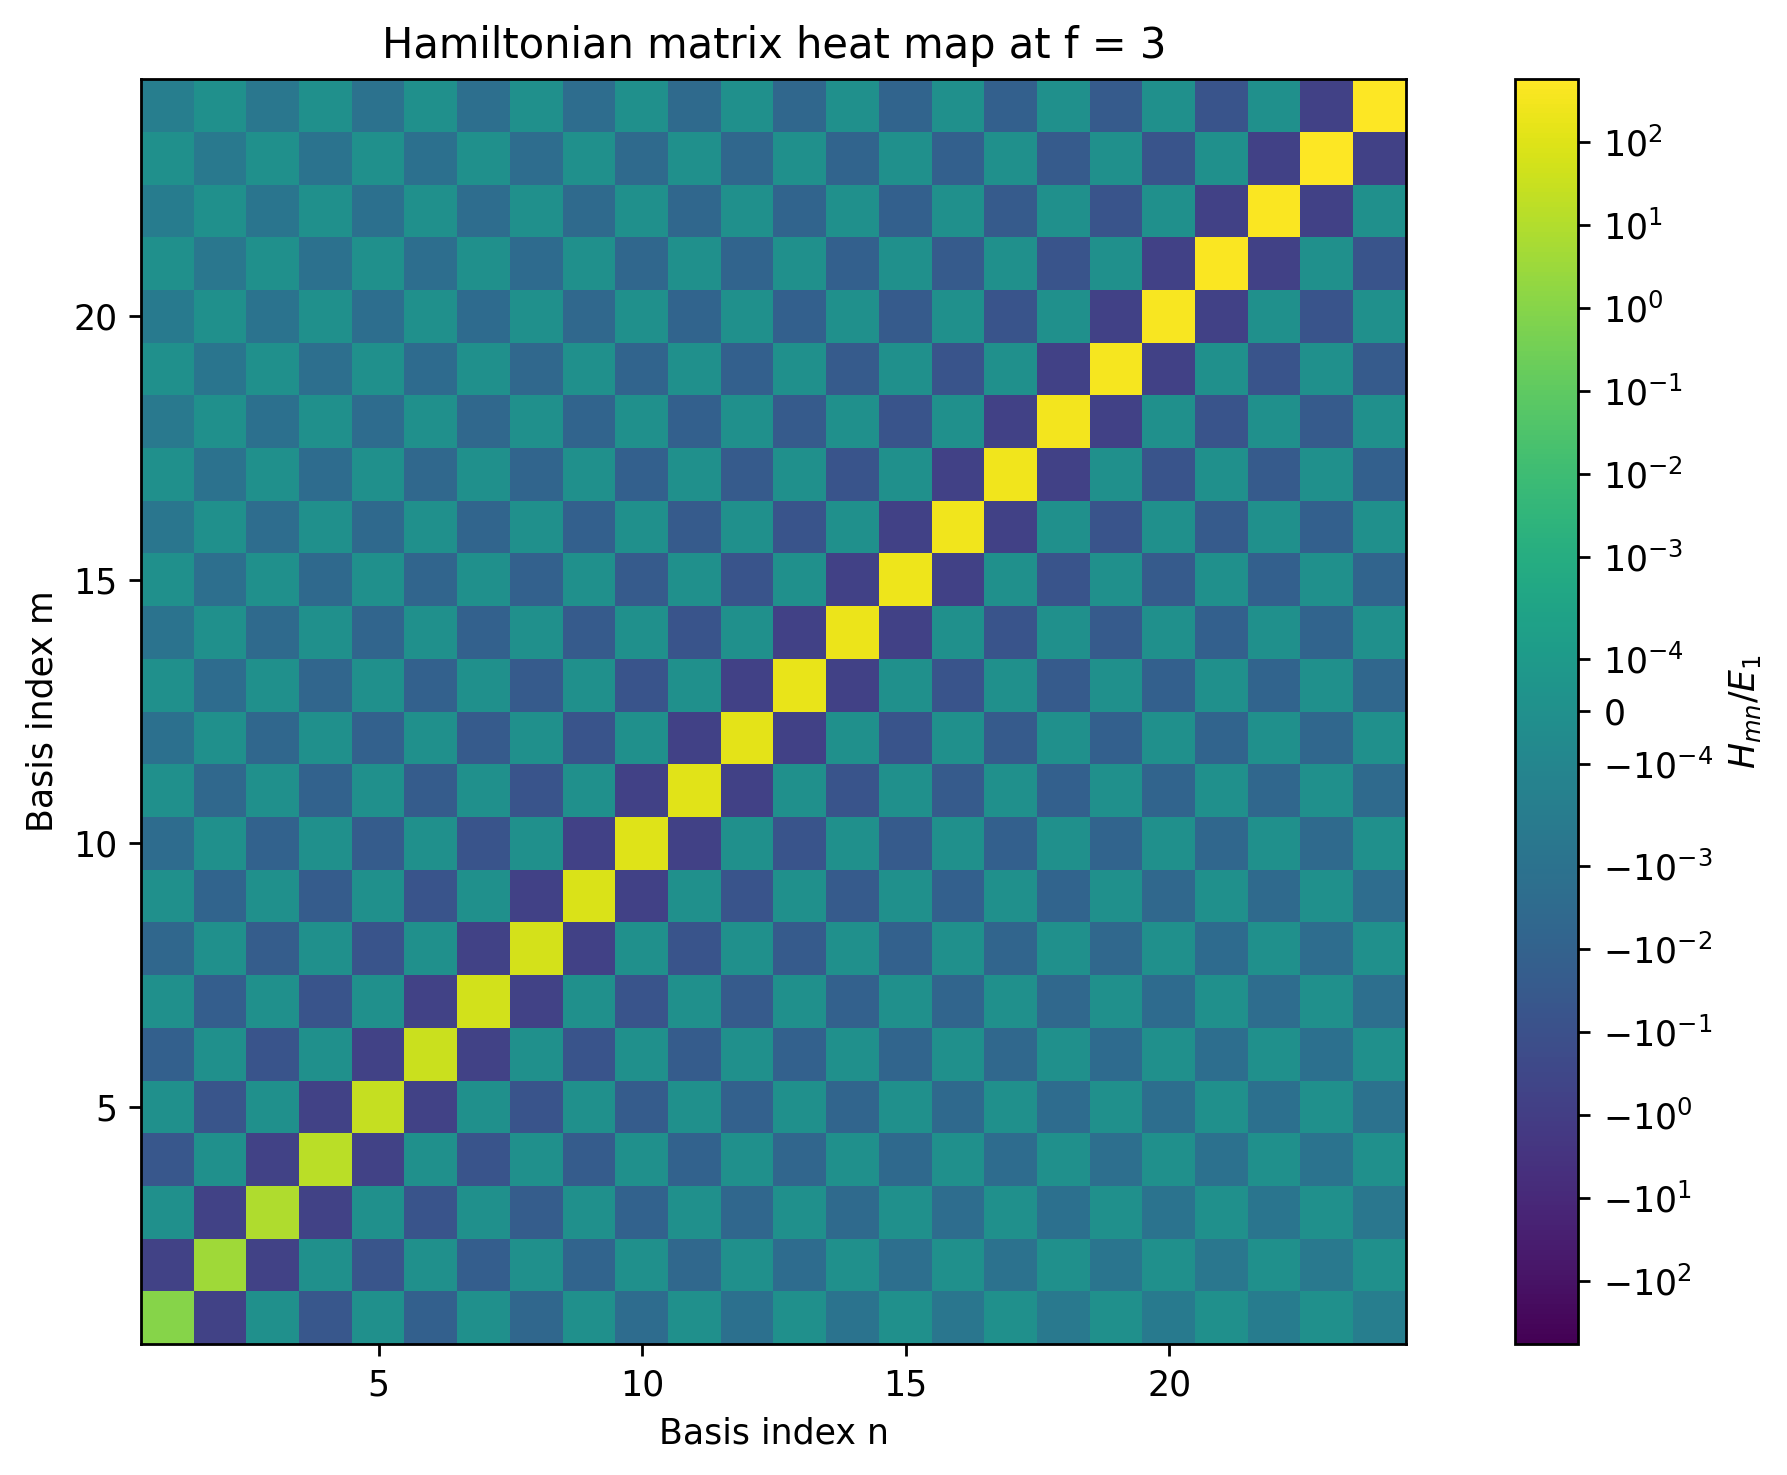

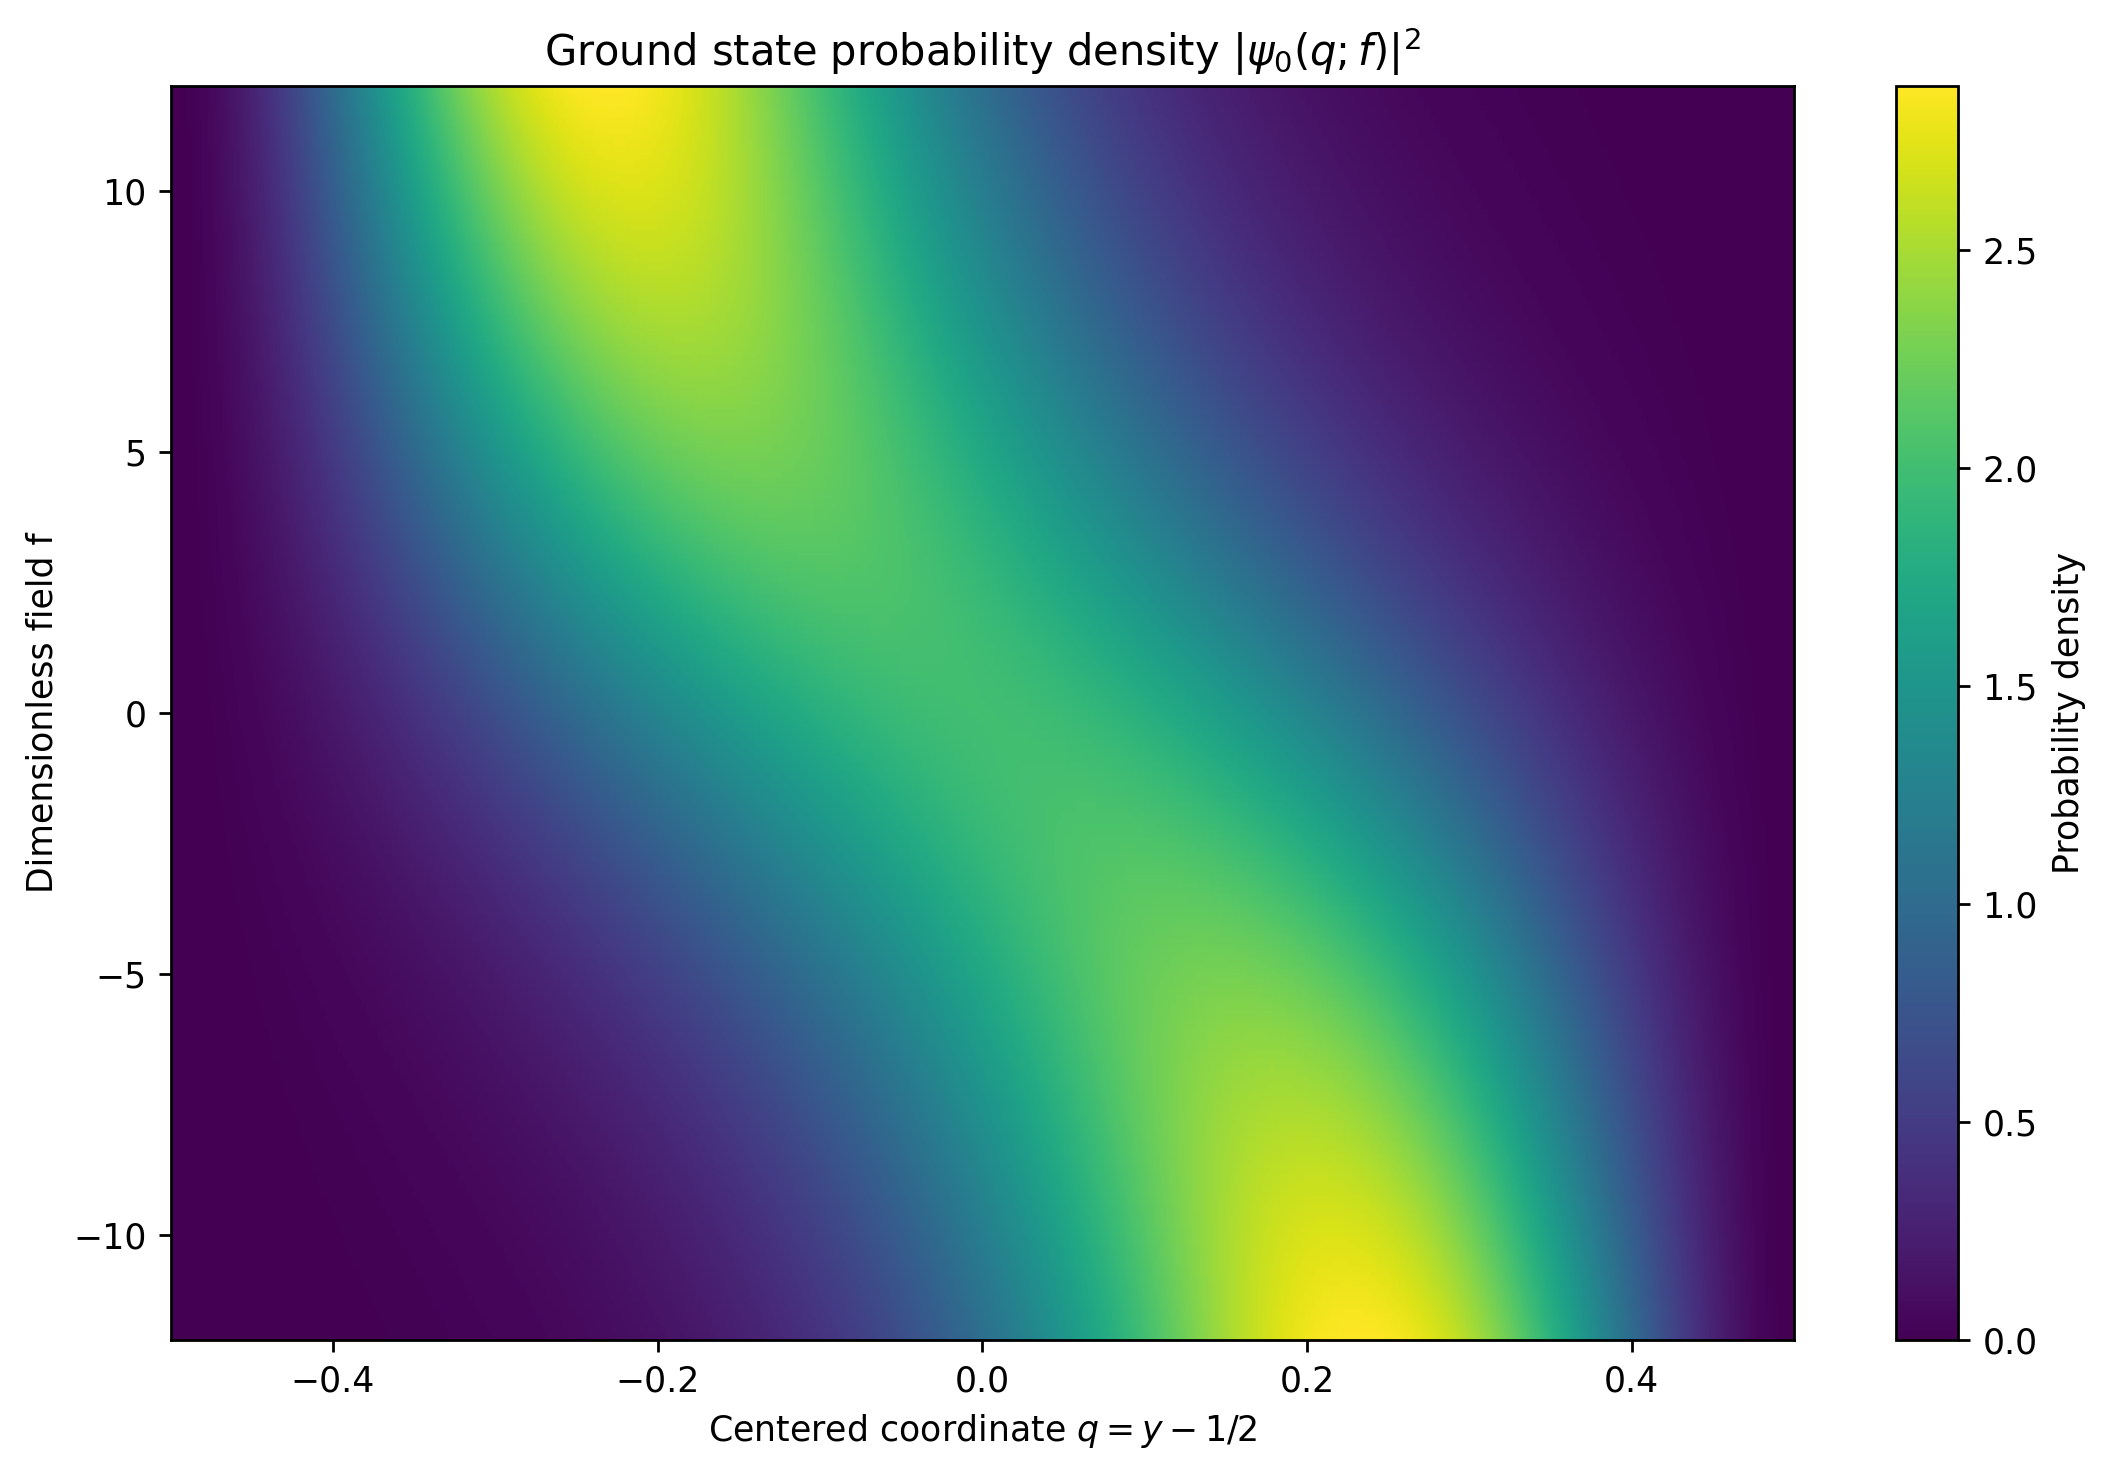

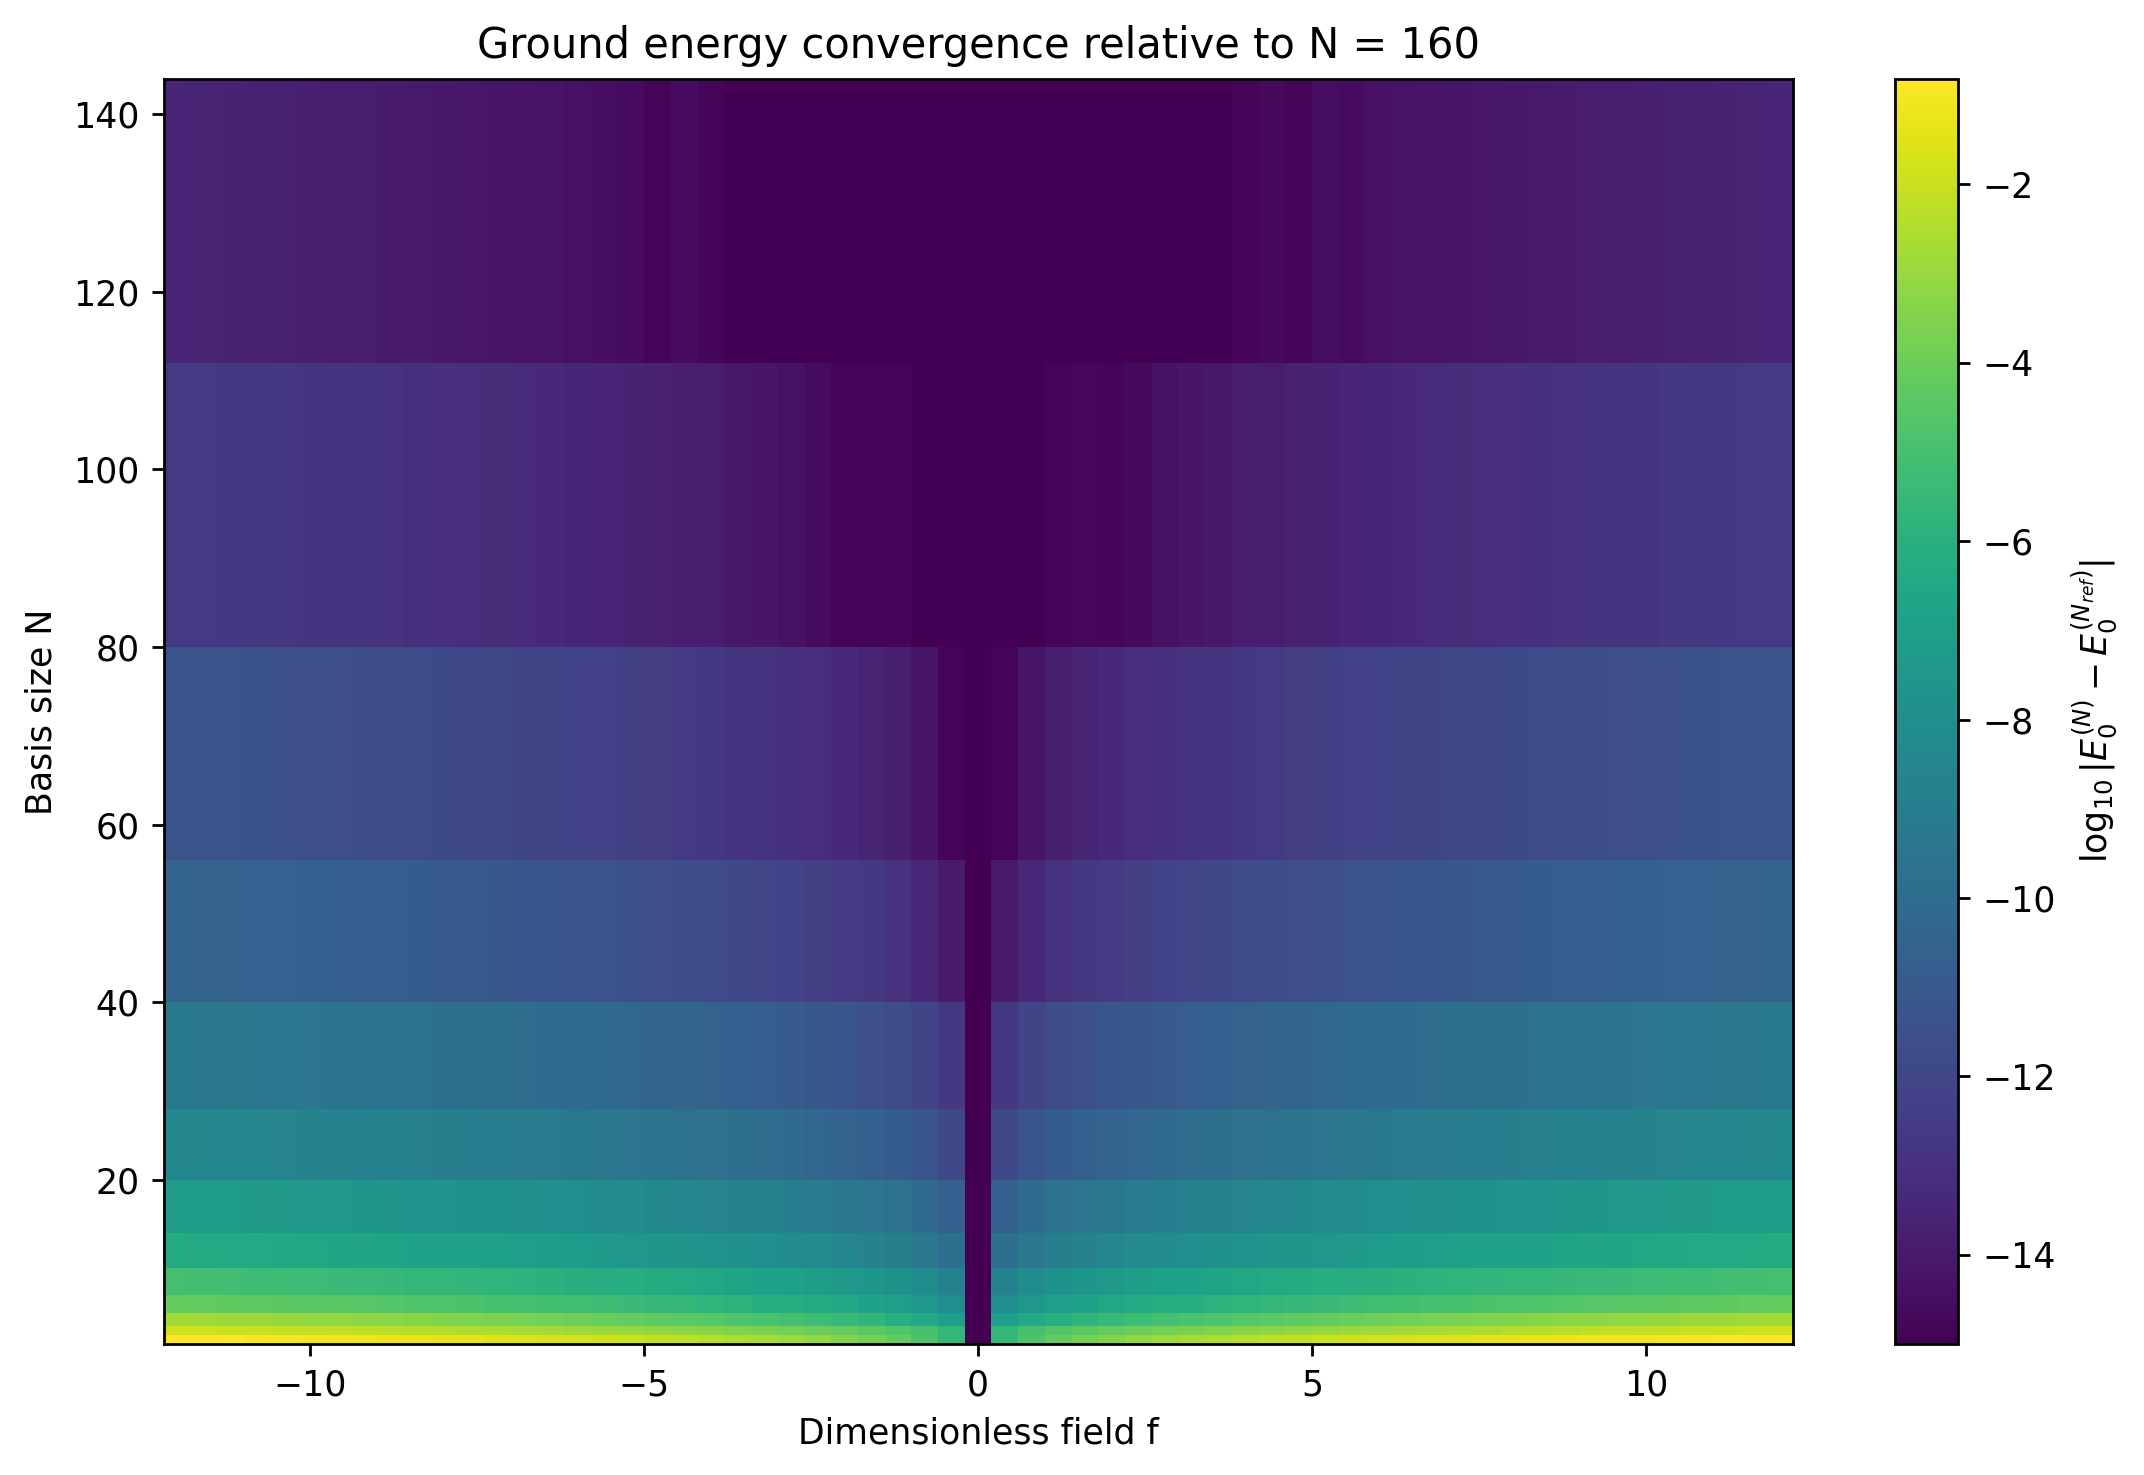

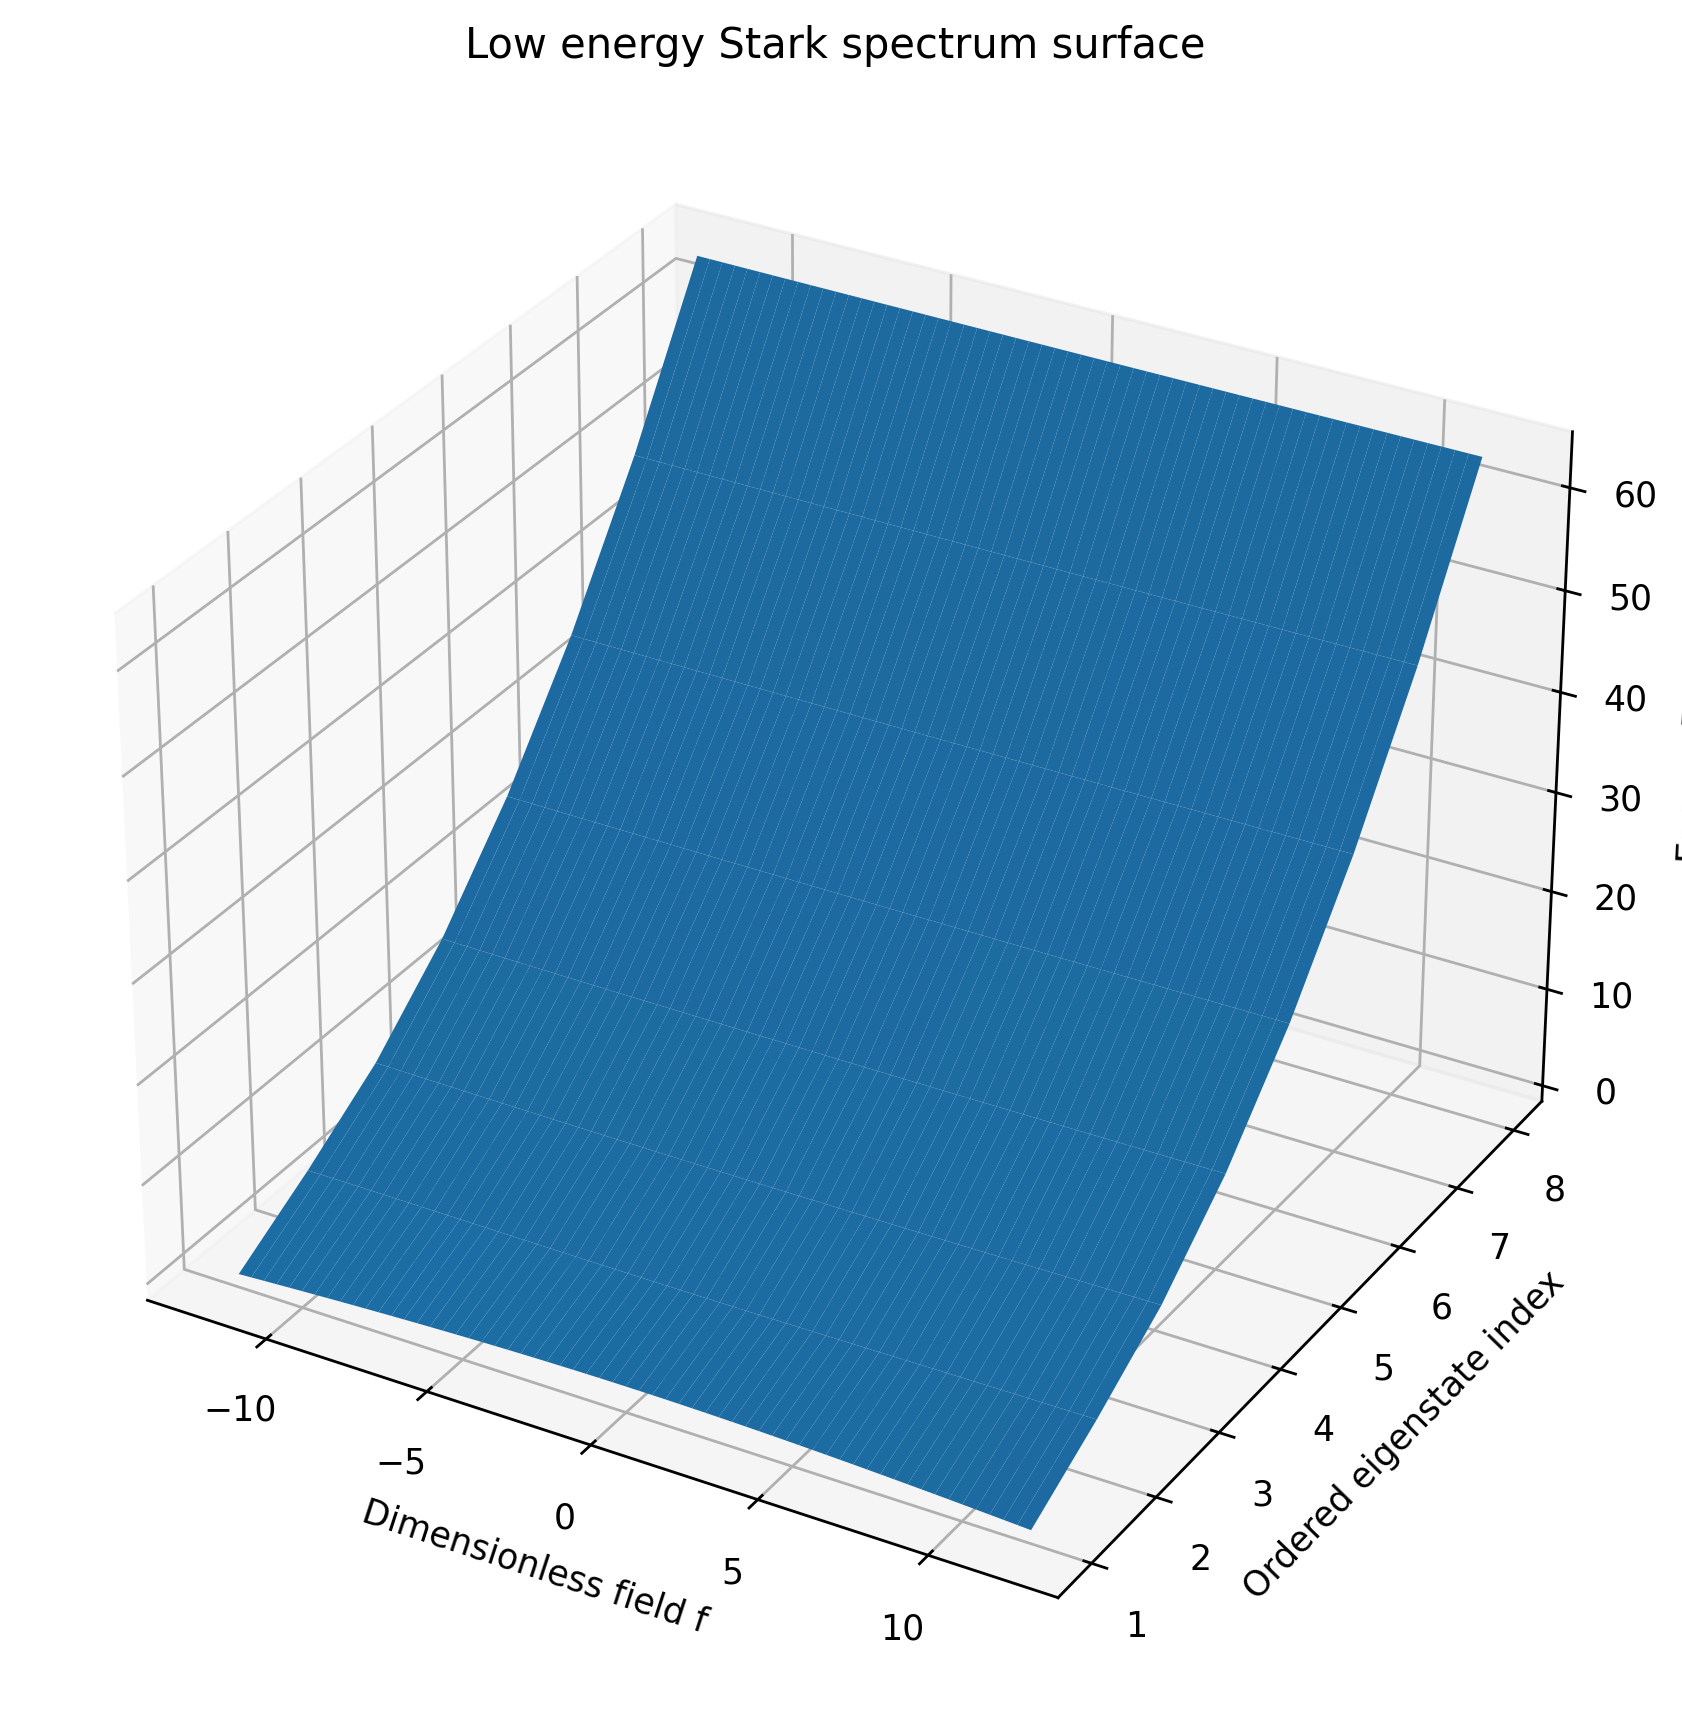

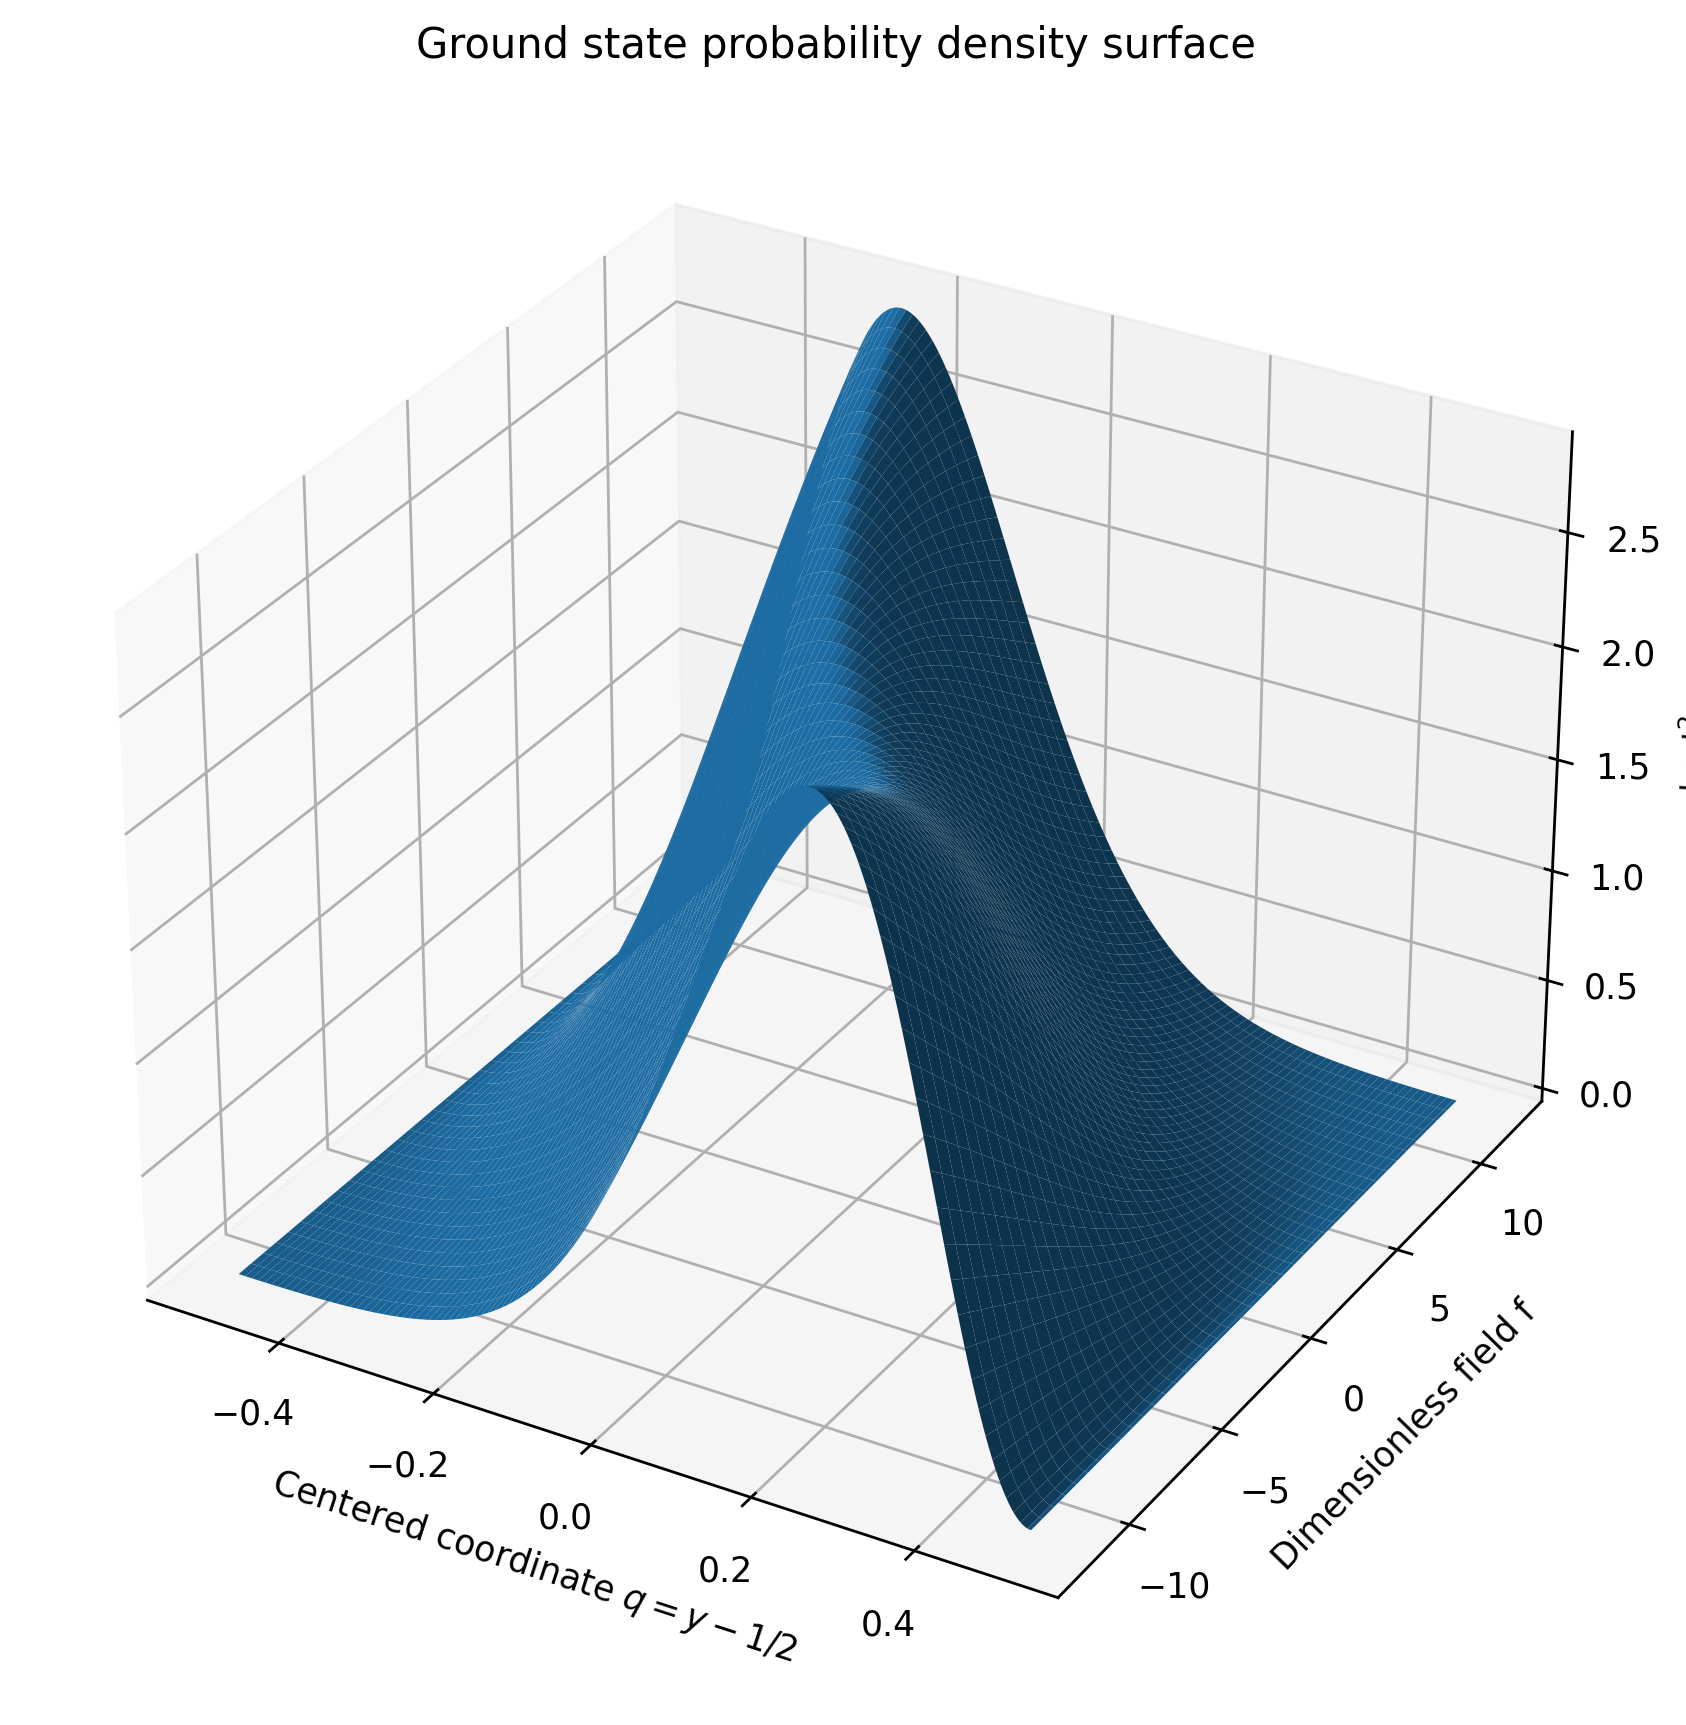

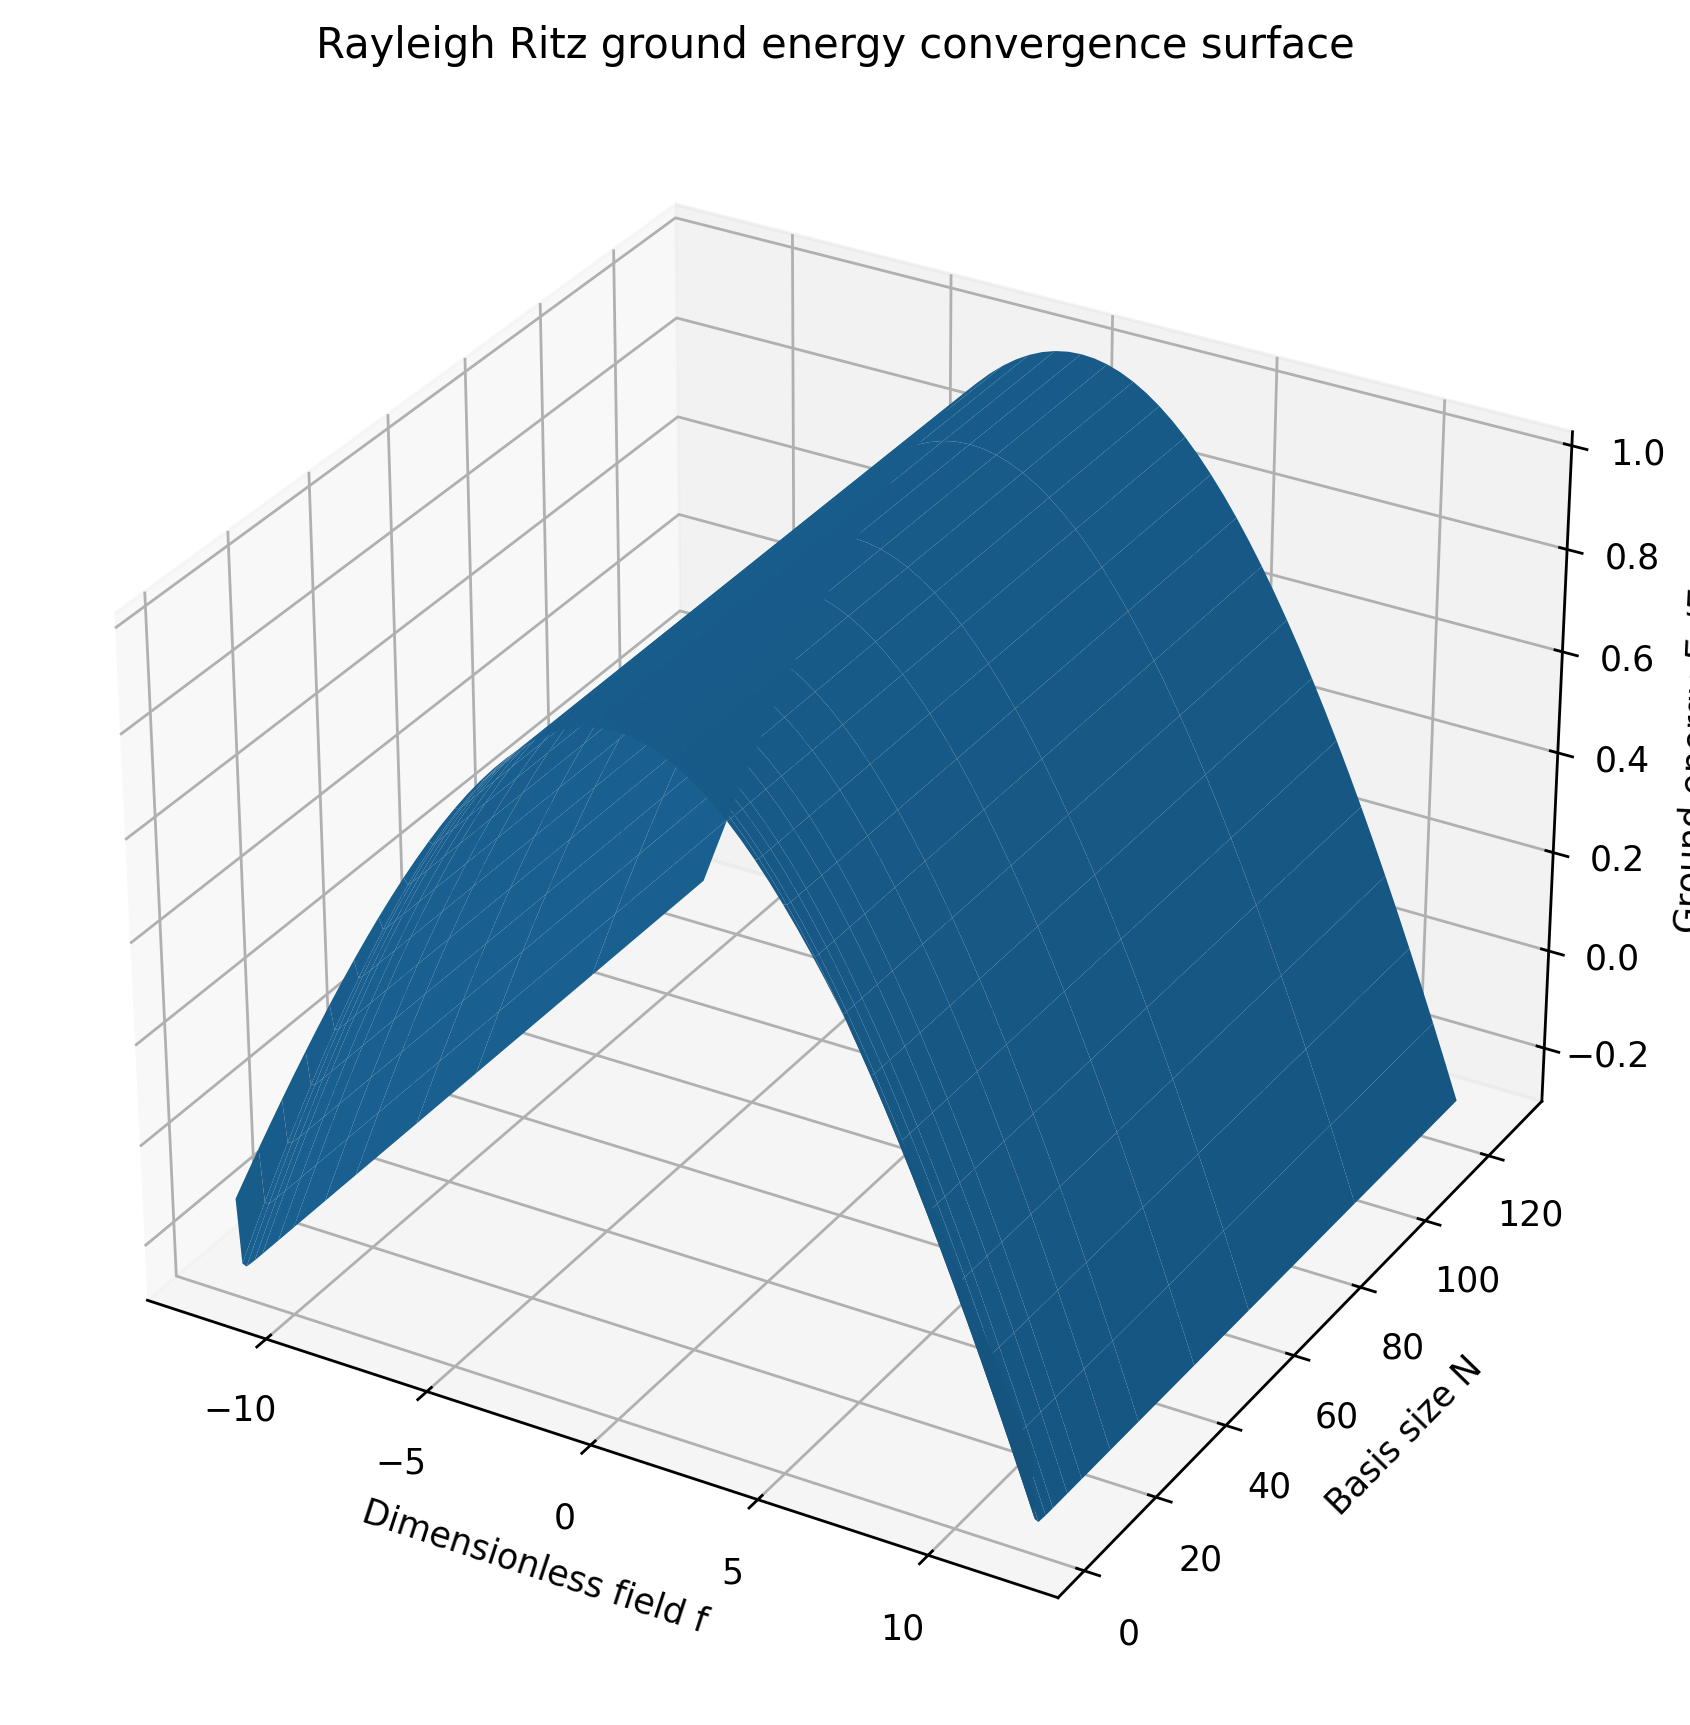

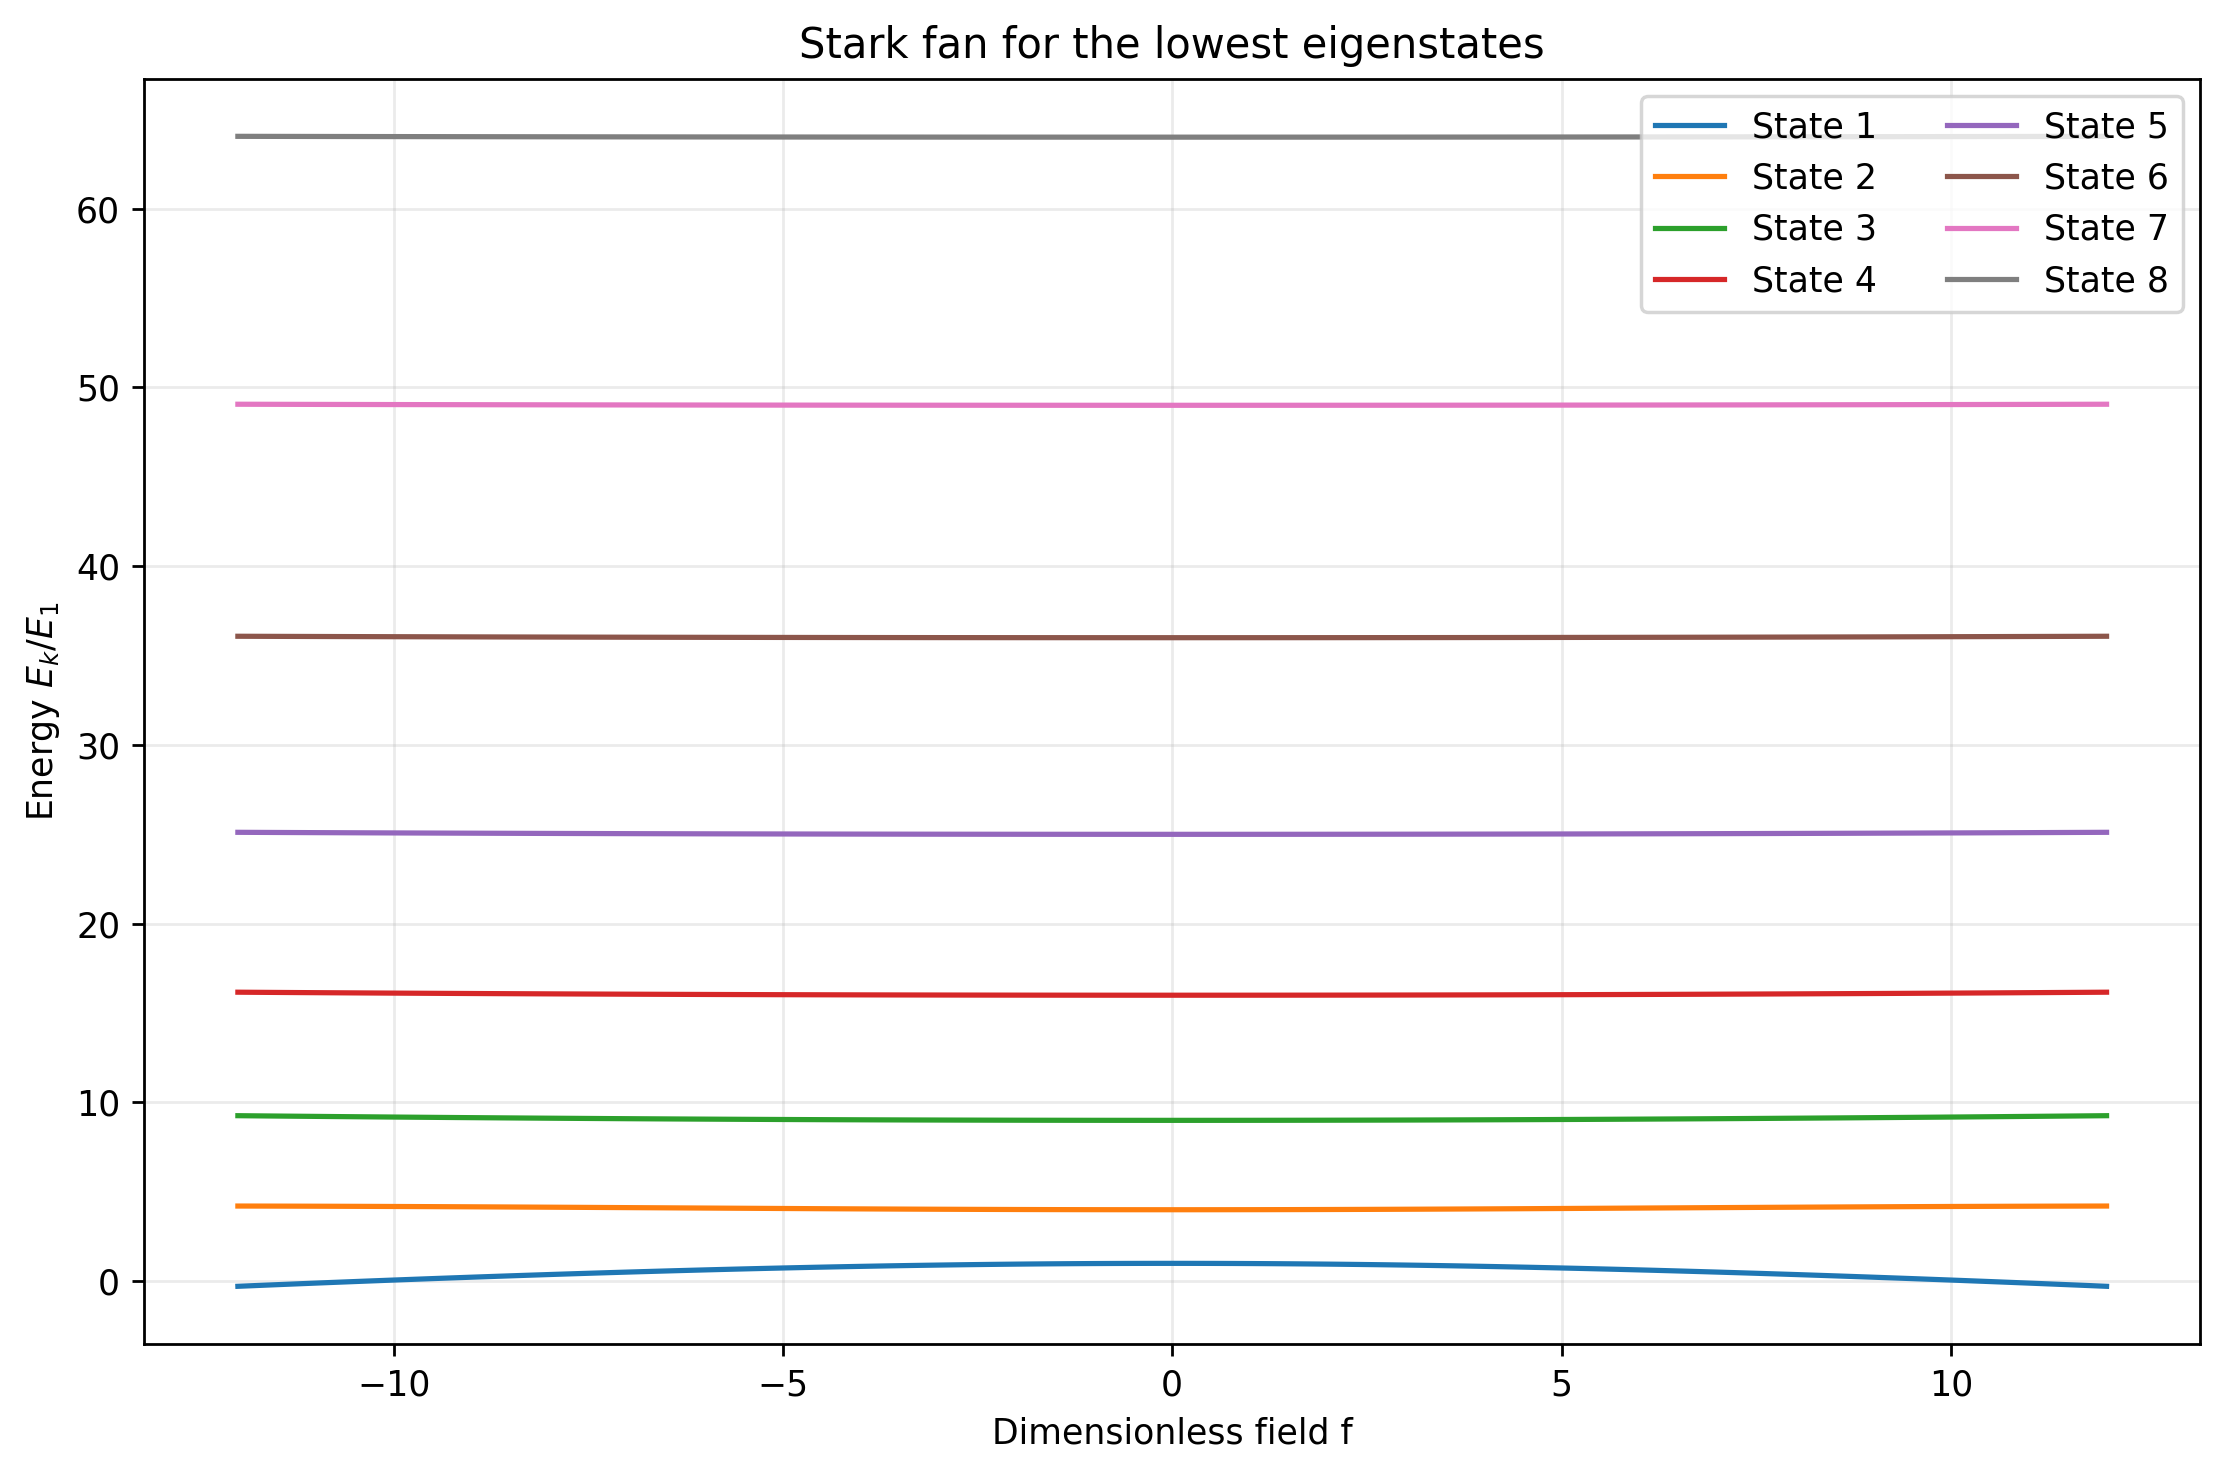

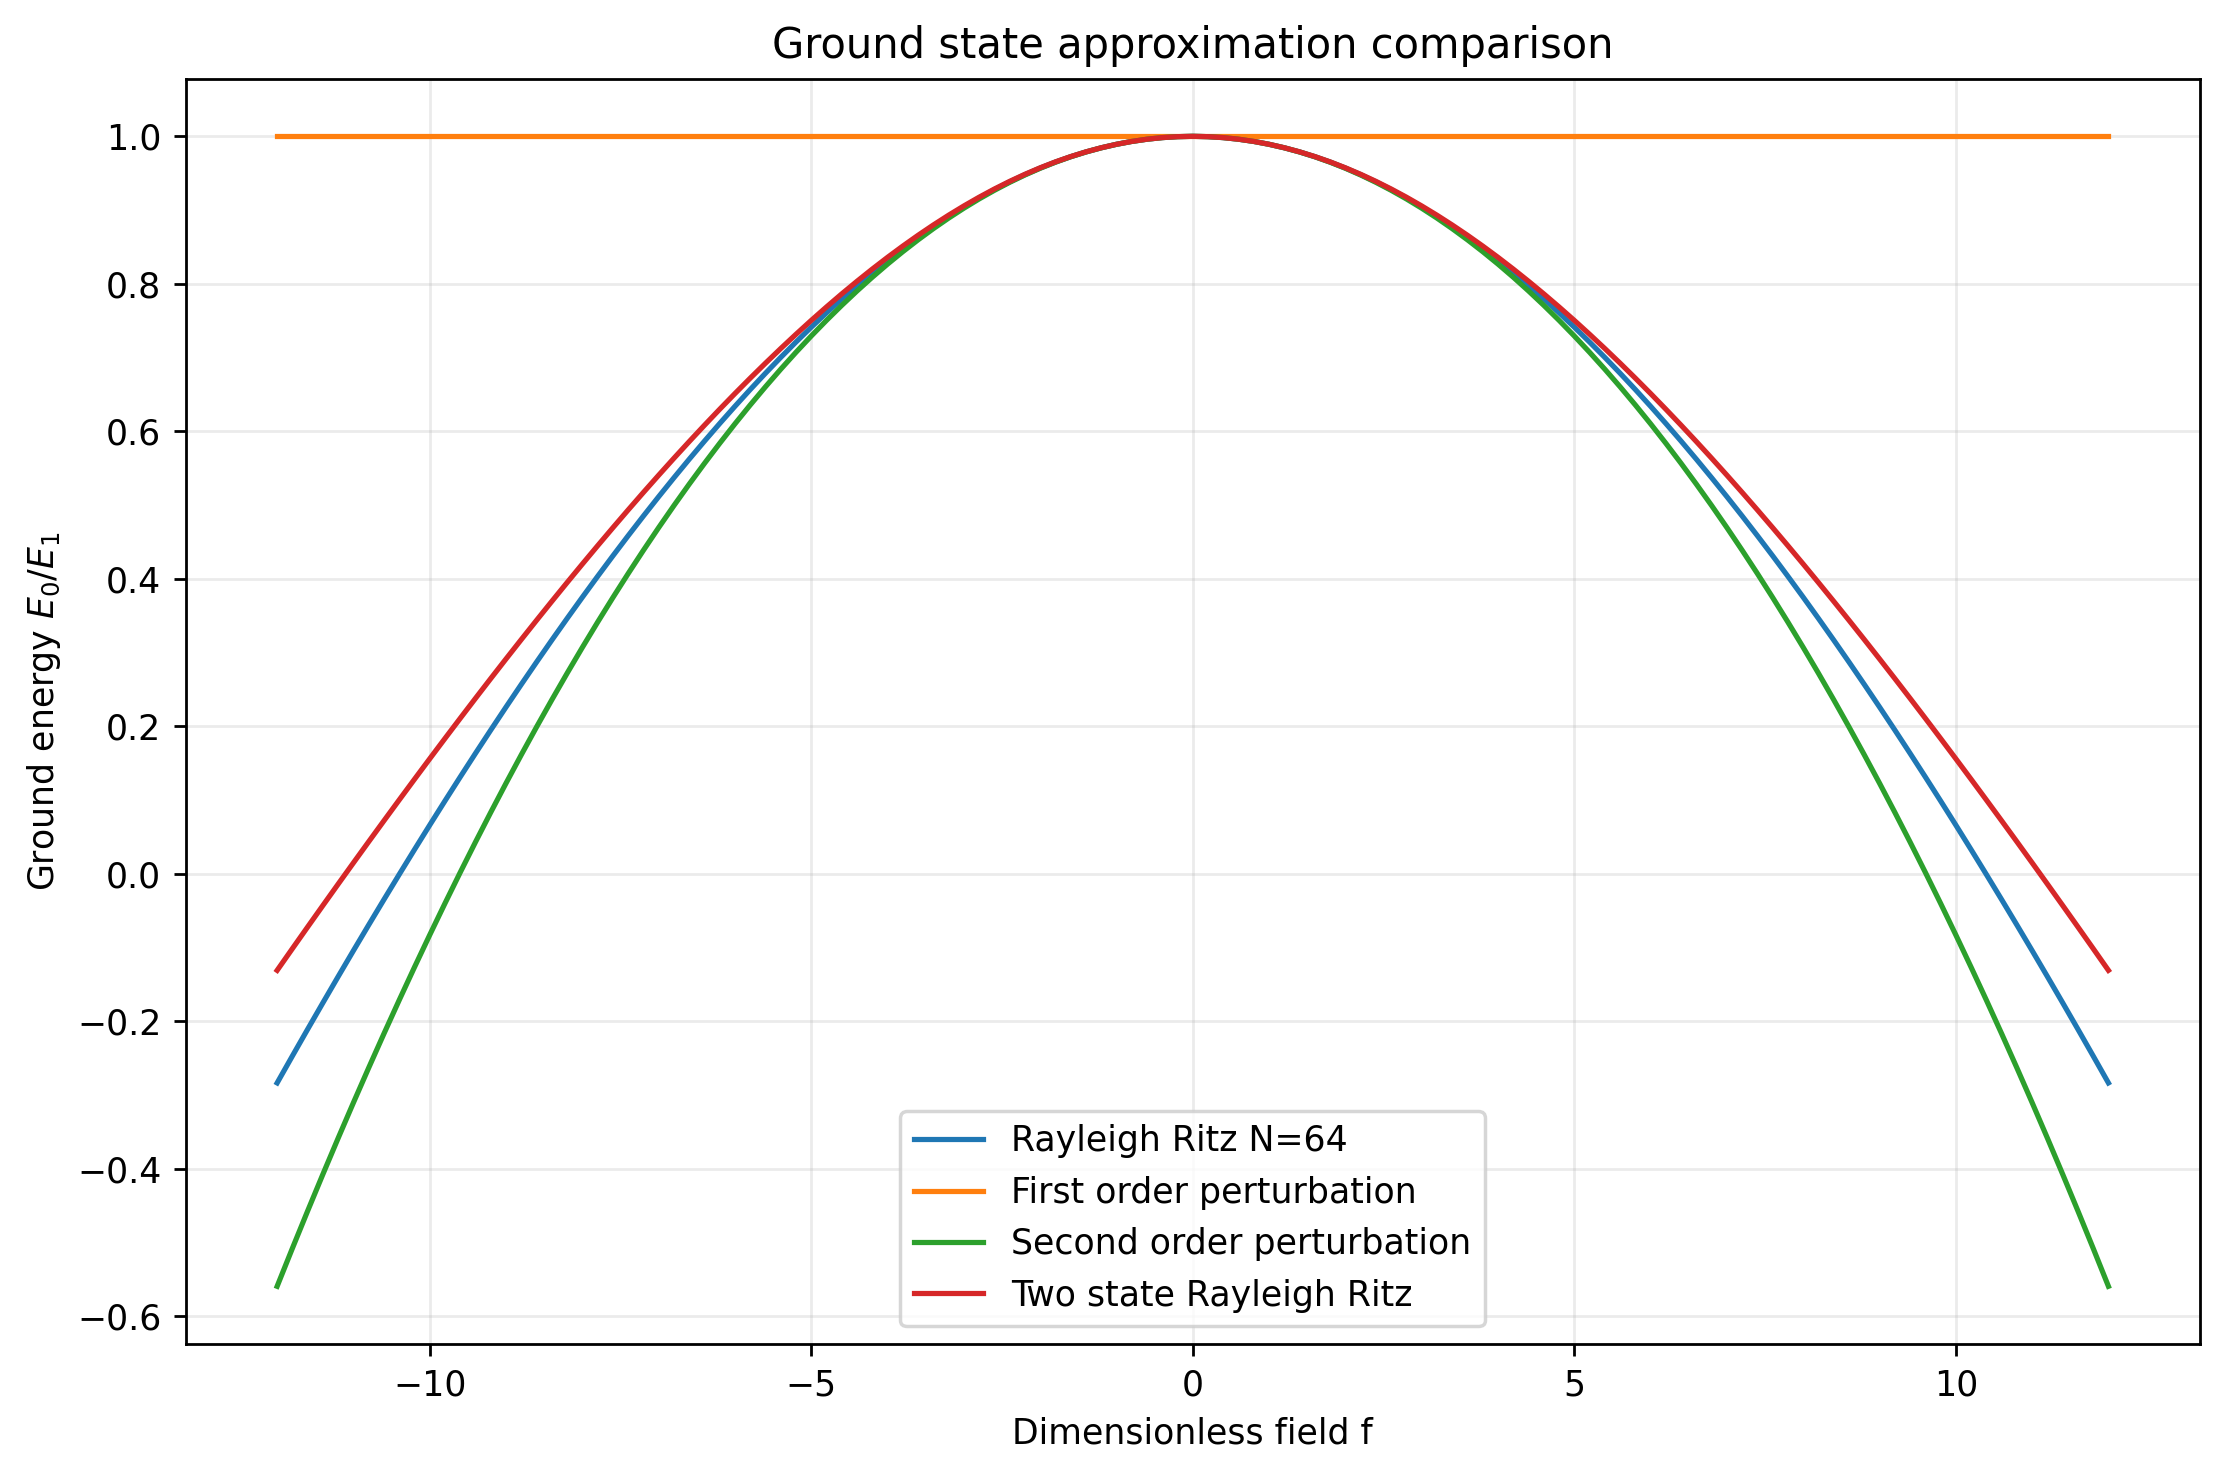

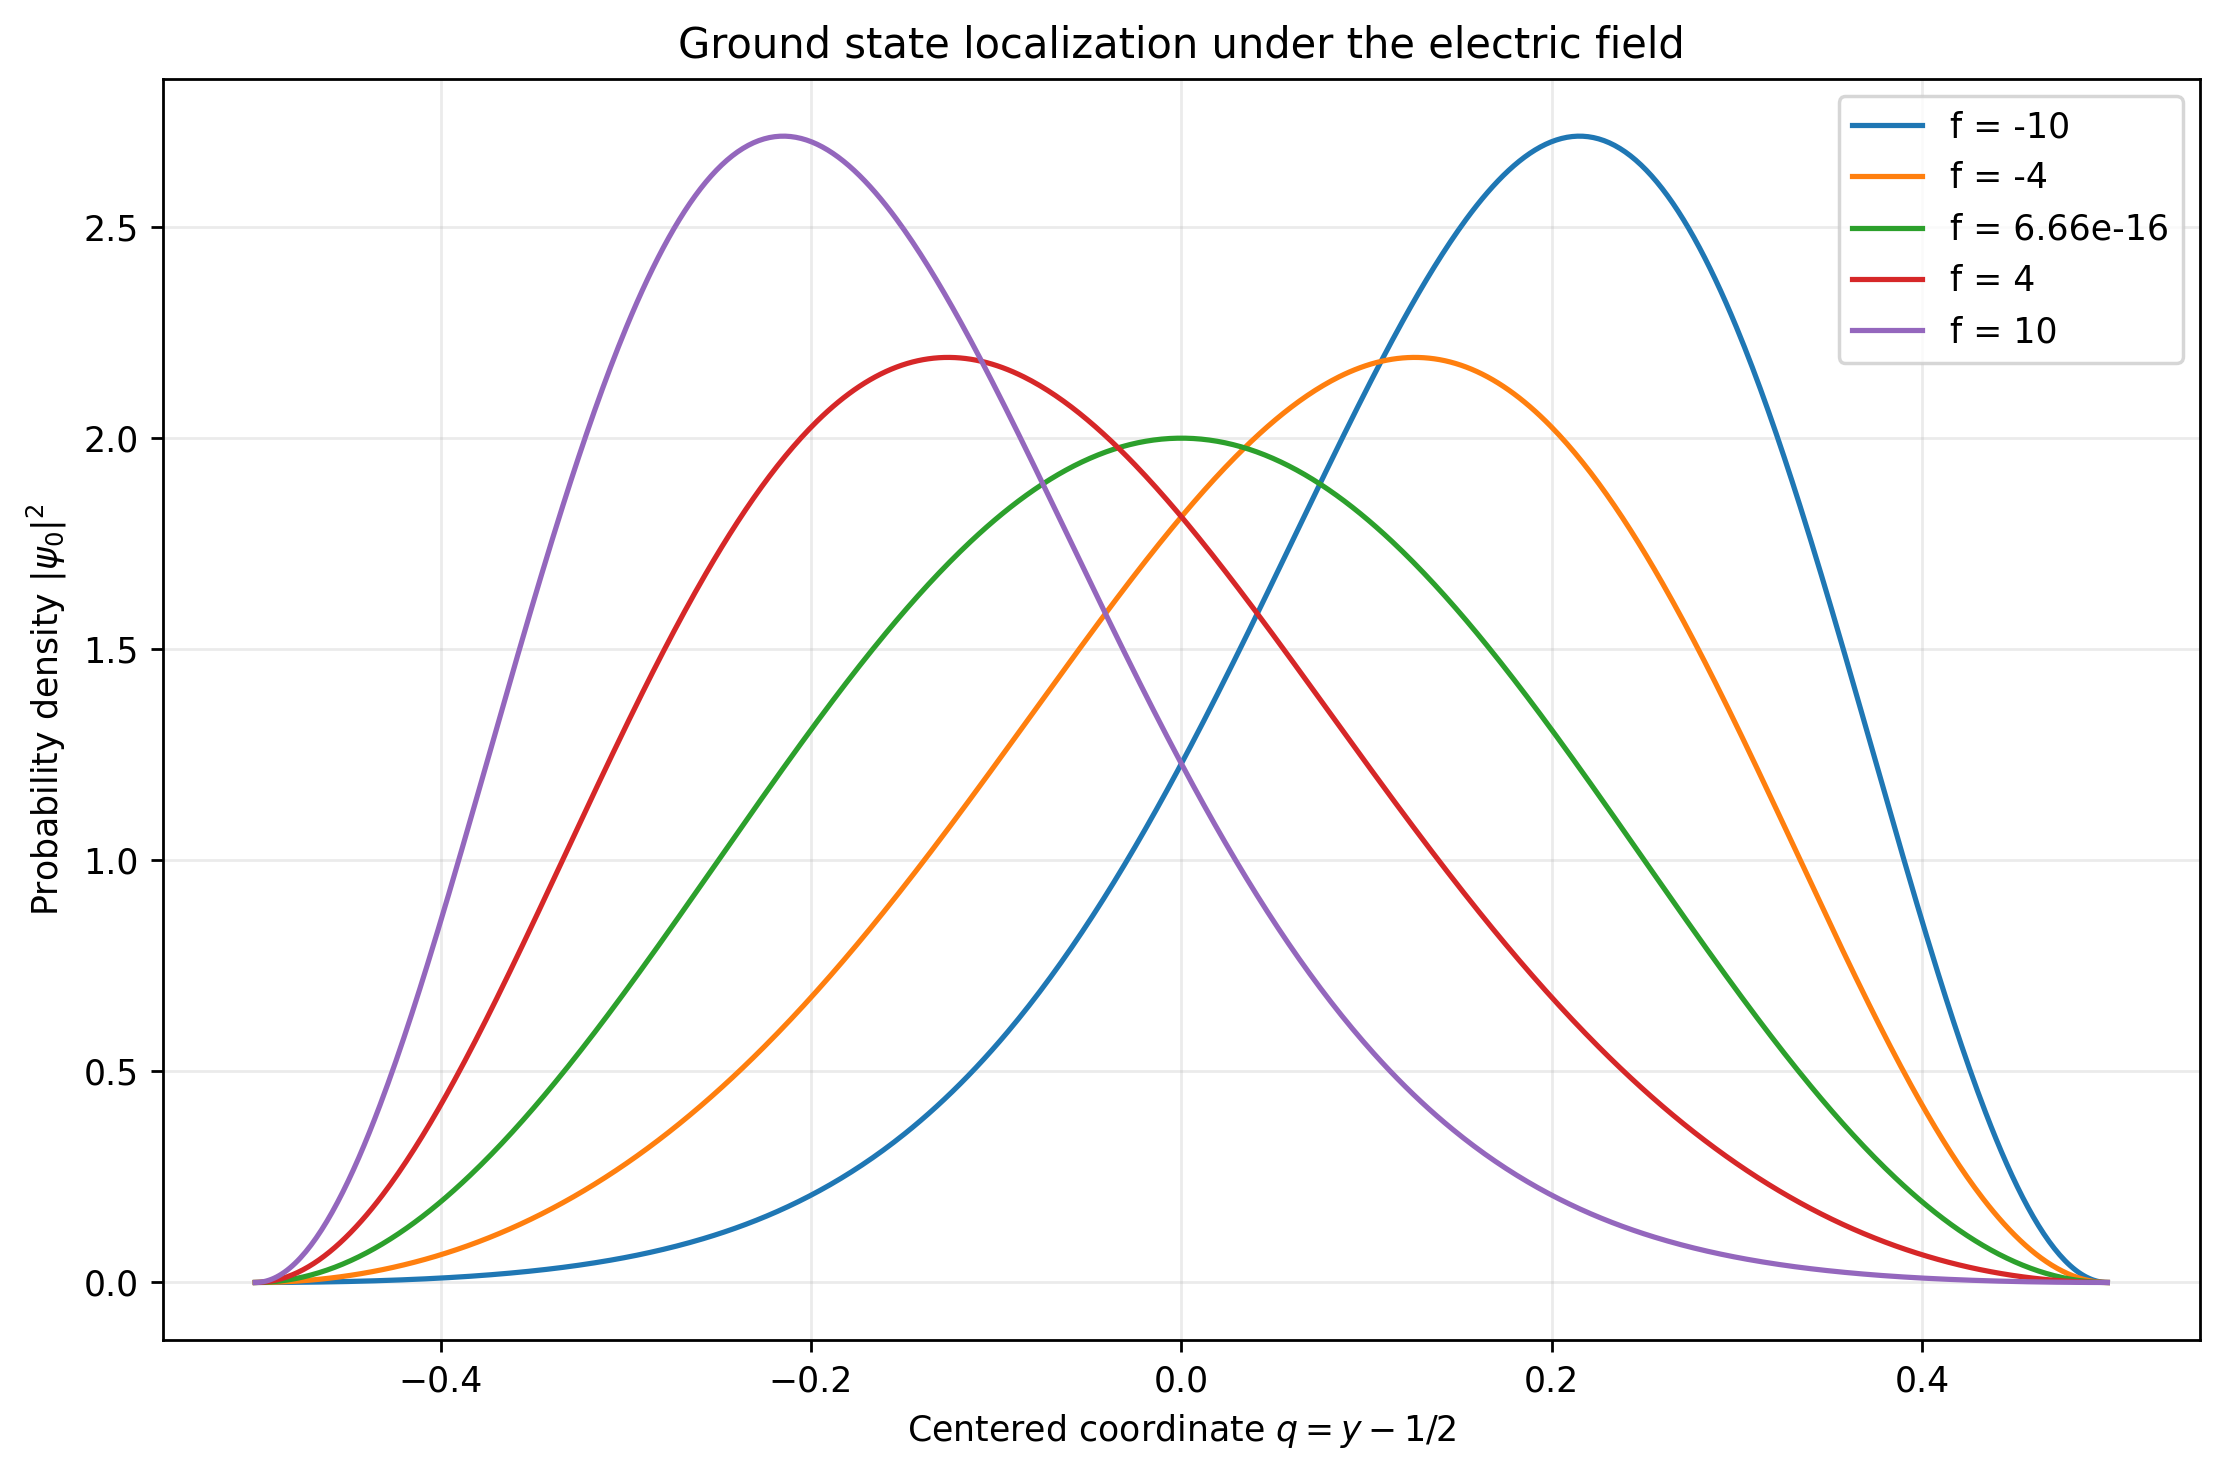

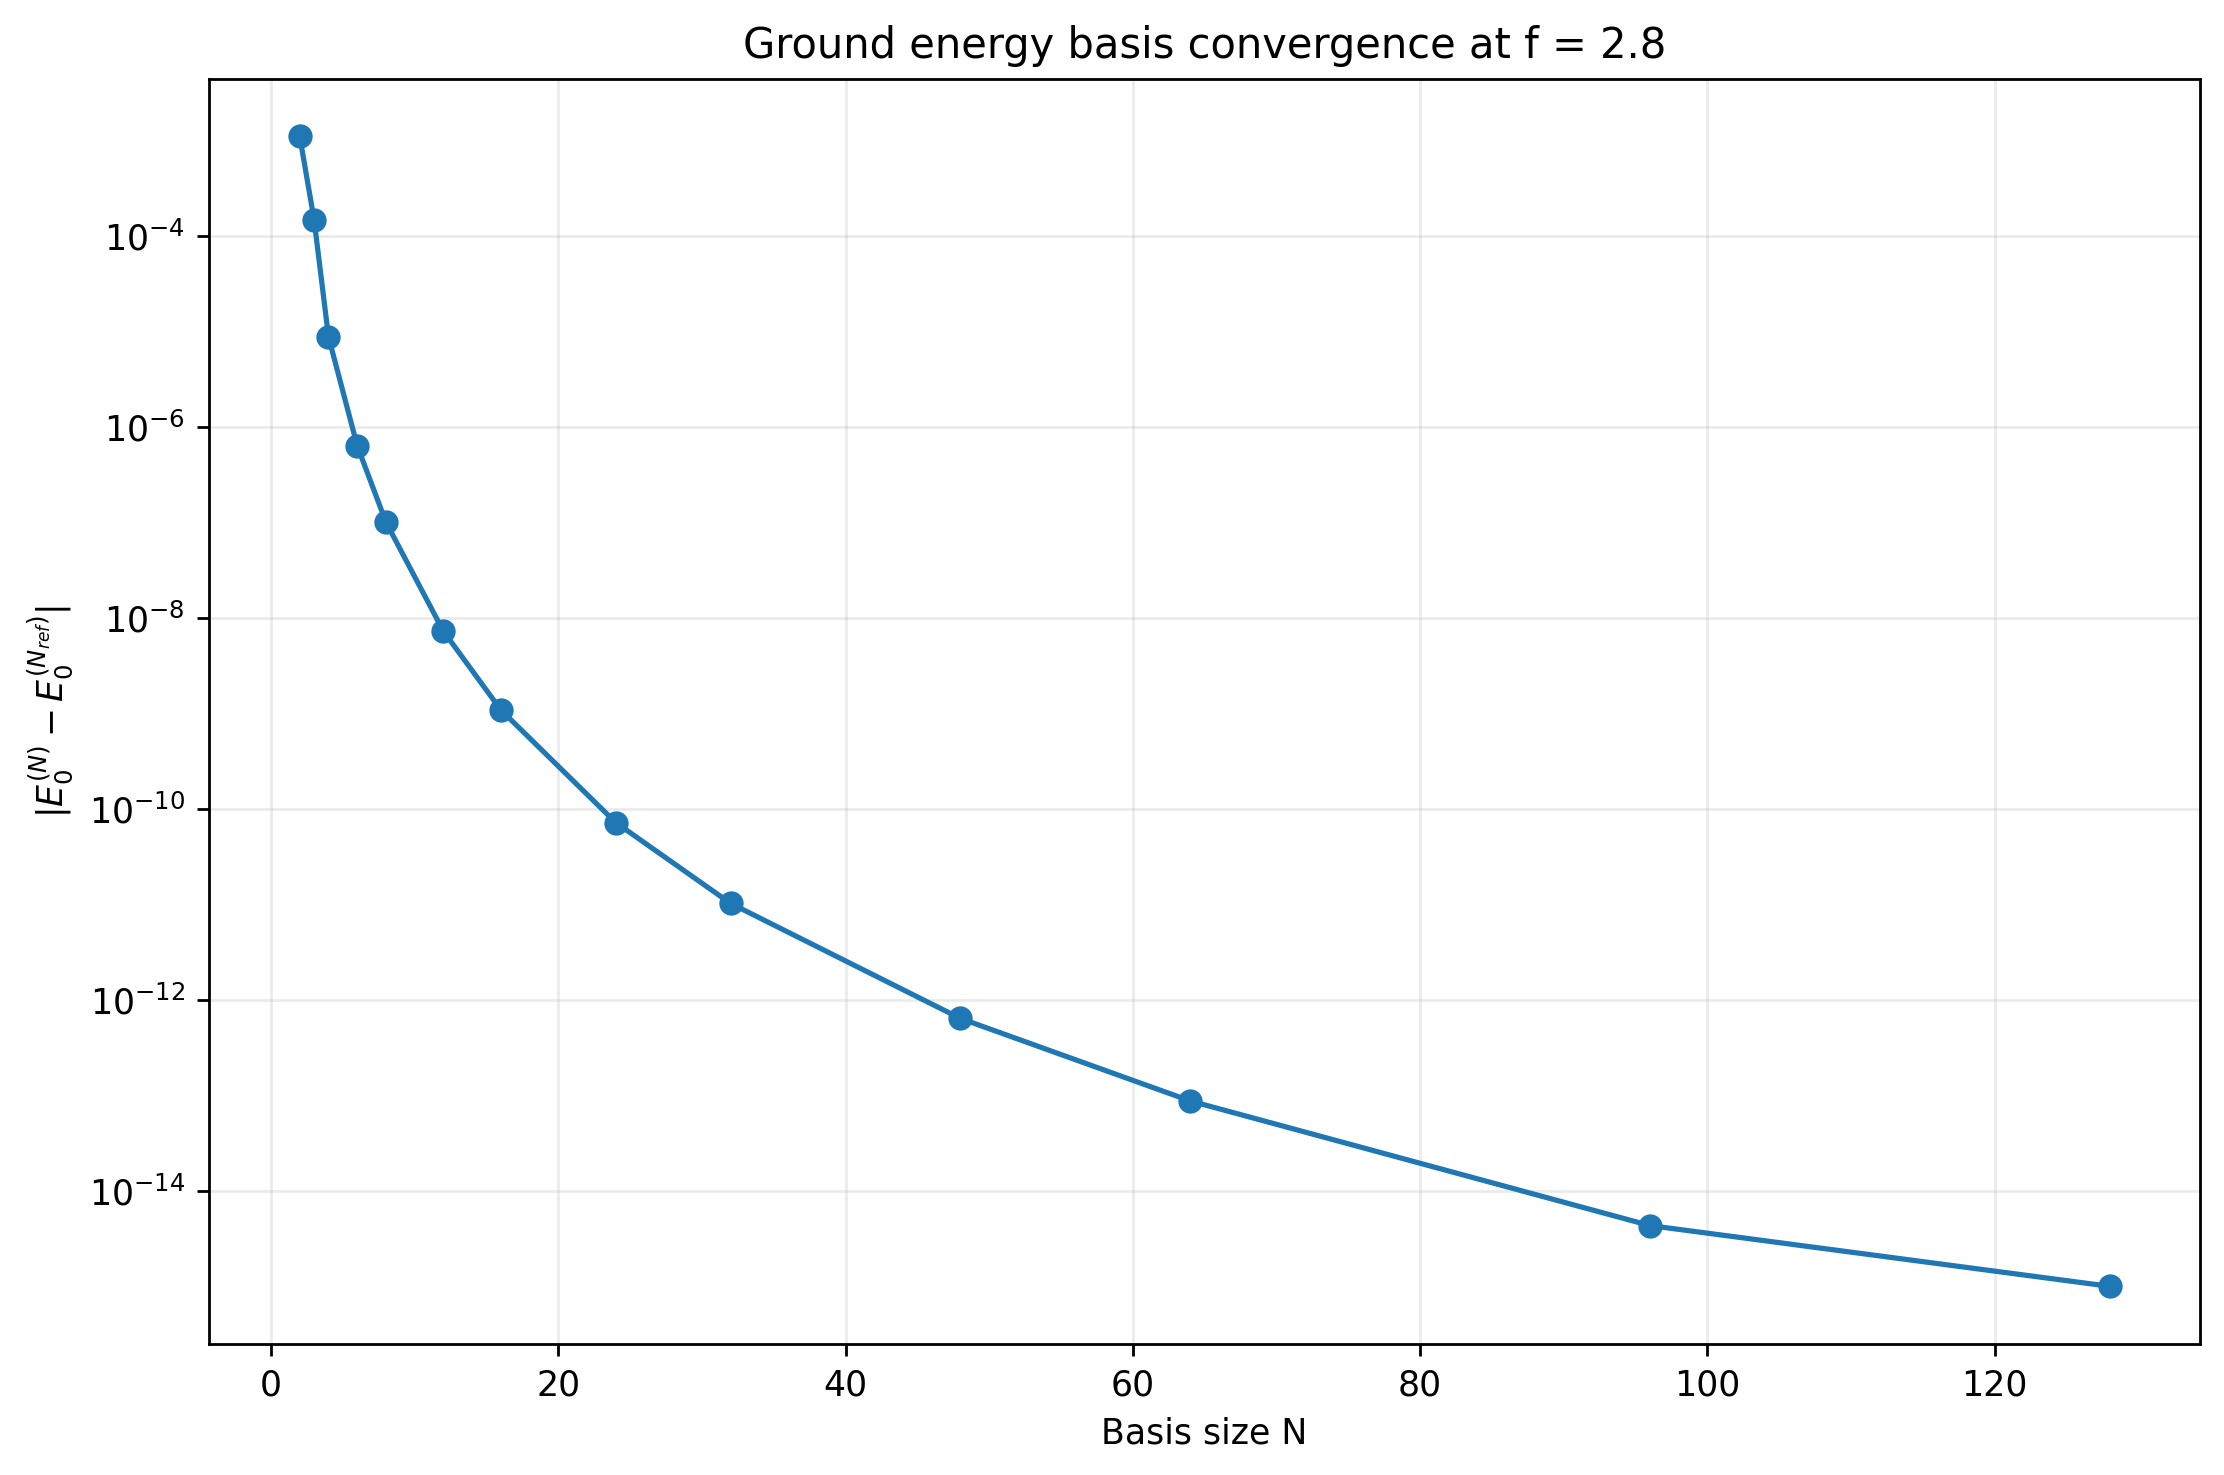

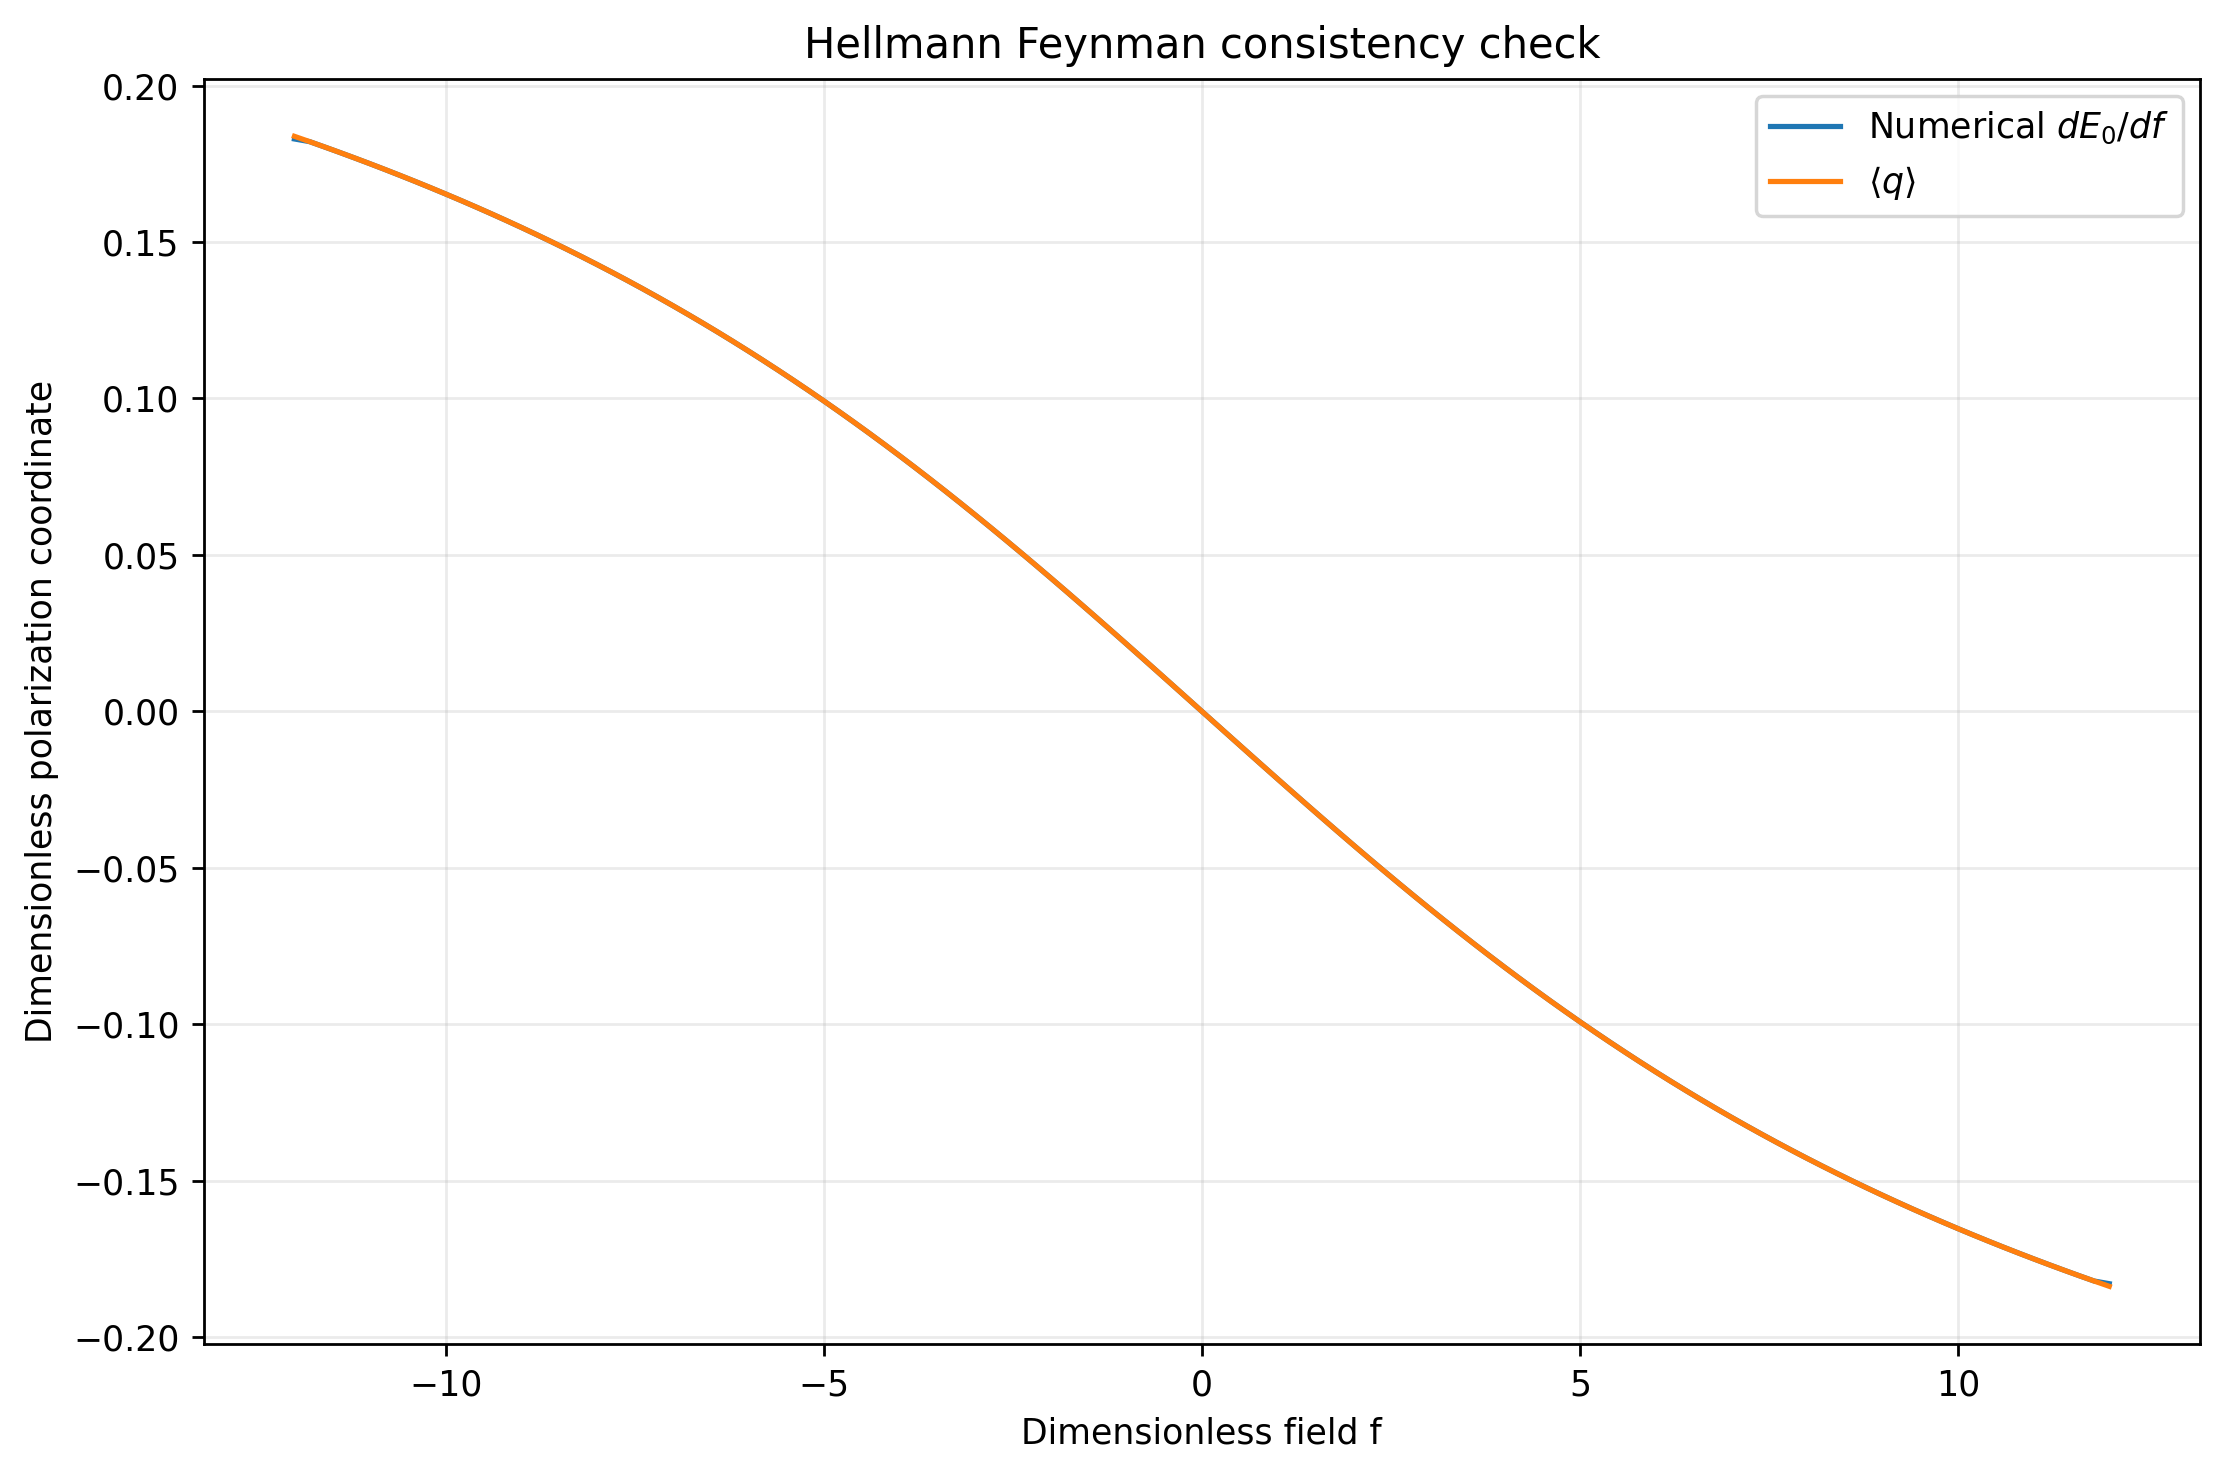

In [20]:
"""This script investigates the GPU accelerated Stark effect in a one dimensional infinite well.

The dimensionless Hamiltonian is

  H / E_1 = -(1 / pi^2) d^2/dy^2 + f (y - 1/2)

where y = x / L lies in [0, 1], E_1 = pi^2 hbar^2 / (2 m L^2), and
f = q E L / E_1 is the dimensionless electric field strength. The sine basis
phi_n(y) = sqrt(2) sin(n pi y) gives unperturbed energies n^2.

The calculation utilizes the Quantum Toolbox in Python for fundamental operator
construction, while CuPy executes the batched eigensolution, state reconstruction,
and multidimensional parameter sweeps.
"""

from dataclasses import dataclass
from typing import Sequence, Tuple

import cupy as cp
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt


# =============================================================================
# Control knobs
# =============================================================================
ELECTRIC_FIELD_STRENGTH: float = 3.0
BASIS_SIZE: int = 64
NUM_EIGENSTATES: int = 8
PERTURBATION_SUMMATION_LIMIT: int = 20_000

FIELD_MIN: float = -12.0
FIELD_MAX: float = 12.0
NUM_FIELD_POINTS: int = 121
POSITION_POINTS: int = 700

MATRIX_DISPLAY_BASIS_SIZE: int = 24
CONVERGENCE_BASIS_SIZES: tuple[int, ...] = (
    2,
    3,
    4,
    6,
    8,
    12,
    16,
    24,
    32,
    48,
    64,
    96,
    128,
)
REFERENCE_BASIS_SIZE: int = 160
CONVERGENCE_FIELD_POINTS: int = 61
SELECTED_FIELDS: tuple[float, ...] = (-10.0, -4.0, 0.0, 4.0, 10.0)

PLOT_HAMILTONIAN_HEATMAP: bool = True
PLOT_PROBABILITY_HEATMAP: bool = True
PLOT_CONVERGENCE_HEATMAP: bool = True
PLOT_ENERGY_SPECTRUM_SURFACE: bool = True
PLOT_PROBABILITY_SURFACE: bool = True
PLOT_CONVERGENCE_SURFACE: bool = True
PLOT_STARK_FAN: bool = True
PLOT_APPROXIMATION_COMPARISON: bool = True
PLOT_GROUND_STATE_DENSITIES: bool = True
PLOT_BASIS_CONVERGENCE: bool = True
PLOT_HELLMANN_FEYNMAN_CHECK: bool = True

FLOAT_DTYPE = cp.float64
FIGURE_DPI: int = 250
FIGURE_SIZE_2D: tuple[float, float] = (9.0, 6.0)
FIGURE_SIZE_3D: tuple[float, float] = (10.0, 7.0)
SURFACE_ROW_STRIDE: int = 3
SURFACE_COLUMN_STRIDE: int = 6
LOG_ERROR_FLOOR: float = 1.0e-15

mpl.rcParams["figure.dpi"] = FIGURE_DPI
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25


@dataclass(frozen=True)
class FieldSweepResults:
    """Stores fixed basis electric field sweep results on GPU memory."""

    fields: cp.ndarray
    coordinates: cp.ndarray
    energies: cp.ndarray
    eigenvectors: cp.ndarray
    wavefunctions: cp.ndarray
    densities: cp.ndarray
    coordinate_expectation: cp.ndarray
    density_norms: cp.ndarray


@dataclass(frozen=True)
class ConvergenceResults:
    """Stores basis size convergence data on GPU memory."""

    fields: cp.ndarray
    basis_sizes: np.ndarray
    ground_energy_surface: cp.ndarray
    reference_ground_energies: cp.ndarray
    absolute_errors: cp.ndarray


def validate_control_knobs() -> None:
    """Checks simulation controls before allocating GPU arrays.

    Raises:
        ValueError: If a control knob is inconsistent or outside its domain.
    """
    if BASIS_SIZE < 2:
        raise ValueError("BASIS_SIZE must be at least 2.")
    if NUM_EIGENSTATES < 1 or NUM_EIGENSTATES > BASIS_SIZE:
        raise ValueError(
            "NUM_EIGENSTATES must lie between 1 and BASIS_SIZE."
        )
    if POSITION_POINTS < 3:
        raise ValueError("POSITION_POINTS must be at least 3.")
    if NUM_FIELD_POINTS < 3:
        raise ValueError("NUM_FIELD_POINTS must be at least 3.")
    if FIELD_MIN >= FIELD_MAX:
        raise ValueError("FIELD_MIN must be smaller than FIELD_MAX.")
    if REFERENCE_BASIS_SIZE < max(CONVERGENCE_BASIS_SIZES):
        raise ValueError(
            "REFERENCE_BASIS_SIZE must be at least the largest convergence "
            "basis size."
        )
    if any(size < 2 for size in CONVERGENCE_BASIS_SIZES):
        raise ValueError("Every convergence basis size must be at least 2.")
    if CONVERGENCE_FIELD_POINTS < 3:
        raise ValueError("CONVERGENCE_FIELD_POINTS must be at least 3.")
    if PERTURBATION_SUMMATION_LIMIT < 2:
        raise ValueError(
            "PERTURBATION_SUMMATION_LIMIT must be at least 2."
        )


def get_gpu_name() -> str:
    """Returns the active CUDA device name."""
    device_id = cp.cuda.Device().id
    properties = cp.cuda.runtime.getDeviceProperties(device_id)
    name = properties.get("name", properties.get(b"name", "Unknown CUDA GPU"))
    if isinstance(name, bytes):
        return name.decode("utf-8")
    return str(name)


def build_qutip_operators(basis_size: int) -> Tuple[qt.Qobj, qt.Qobj]:
    """Constructs formal quantum mechanical operators using QuTiP logic.

    Args:
        basis_size: The total truncation limit for the Hilbert space.

    Returns:
        A tuple containing the unperturbed Hamiltonian and the coordinate
        operator as QuTiP objects.
    """
    quantum_numbers = np.arange(1, basis_size + 1, dtype=np.float64)
    unperturbed_matrix = np.diag(quantum_numbers**2)

    row_numbers = quantum_numbers[:, np.newaxis]
    column_numbers = quantum_numbers[np.newaxis, :]
    row_integers = np.arange(1, basis_size + 1, dtype=np.int64)[:, np.newaxis]
    column_integers = np.arange(1, basis_size + 1, dtype=np.int64)[np.newaxis, :]

    opposite_parity = (row_integers + column_integers) % 2 == 1
    off_diagonal = row_integers != column_integers
    coupling_mask = opposite_parity & off_diagonal

    difference = row_numbers**2 - column_numbers**2
    safe_denominator = np.where(coupling_mask, difference**2, 1.0)
    coordinate_matrix = np.where(
        coupling_mask,
        -8.0 * row_numbers * column_numbers / (np.pi**2 * safe_denominator),
        0.0,
    )

    unperturbed_operator = qt.Qobj(unperturbed_matrix)
    coordinate_operator = qt.Qobj(coordinate_matrix)

    return unperturbed_operator, coordinate_operator


def build_coordinate_matrix(
    basis_size: int,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> cp.ndarray:
    """Extracts the coordinate operator matrix originating from QuTiP.

    Args:
        basis_size: Number of sine basis functions.
        dtype: CuPy floating point dtype.

    Returns:
        A symmetric CuPy array corresponding to the formal quantum operator.
    """
    _, coordinate_operator = build_qutip_operators(basis_size)
    return cp.asarray(coordinate_operator.full(), dtype=dtype)


def build_unperturbed_hamiltonian(
    basis_size: int,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> cp.ndarray:
    """Extracts the unperturbed Hamiltonian matrix originating from QuTiP."""
    unperturbed_operator, _ = build_qutip_operators(basis_size)
    return cp.asarray(unperturbed_operator.full(), dtype=dtype)


def build_hamiltonian(
    basis_size: int,
    field_strength: float,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> cp.ndarray:
    """Constructs one dimensionless Hamiltonian matrix on the GPU."""
    unperturbed = build_unperturbed_hamiltonian(basis_size, dtype)
    coordinate_matrix = build_coordinate_matrix(basis_size, dtype)
    return unperturbed + field_strength * coordinate_matrix


def build_hamiltonian_batch(
    fields: cp.ndarray,
    basis_size: int,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Constructs a batch of Hamiltonians for an expansive field array.

    Args:
        fields: One dimensional CuPy field array.
        basis_size: Number of basis states.
        dtype: CuPy floating point dtype.

    Returns:
        A tuple containing the Hamiltonian batch and coordinate matrix.
    """
    unperturbed = build_unperturbed_hamiltonian(basis_size, dtype)
    coordinate_matrix = build_coordinate_matrix(basis_size, dtype)
    hamiltonians = (
        unperturbed[cp.newaxis, :, :]
        + fields[:, cp.newaxis, cp.newaxis]
        * coordinate_matrix[cp.newaxis, :, :]
    )
    return hamiltonians, coordinate_matrix


def build_sine_basis(
    basis_size: int,
    coordinates: cp.ndarray,
    dtype: cp.dtype = FLOAT_DTYPE,
) -> cp.ndarray:
    """Evaluates orthonormal sine basis functions on centered coordinates."""
    quantum_numbers = cp.arange(
        1,
        basis_size + 1,
        dtype=dtype,
    )[:, cp.newaxis]
    unit_interval_coordinates = coordinates[cp.newaxis, :] + 0.5
    return cp.sqrt(2.0) * cp.sin(
        cp.pi * quantum_numbers * unit_interval_coordinates
    )


def orient_wavefunctions(wavefunctions: cp.ndarray) -> cp.ndarray:
    """Chooses a reproducible mathematical sign for real eigenfunctions.

    Eigenvectors hold a mathematically ambiguous global sign, which this
    function selectively fixes so the discrete integral of each wavefunction
    remains strictly nonnegative.
    """
    signed_areas = cp.sum(wavefunctions, axis=1)
    signs = cp.where(signed_areas < 0.0, -1.0, 1.0)
    return wavefunctions * signs[:, cp.newaxis]


def trapezoidal_integral(values: cp.ndarray, spacing: float) -> cp.ndarray:
    """Integrates along the final axis applying fixed grid trapezoidal weights."""
    weights = cp.ones(values.shape[-1], dtype=values.dtype)
    weights[0] = 0.5
    weights[-1] = 0.5
    return spacing * cp.sum(values * weights, axis=-1)


def run_field_sweep() -> FieldSweepResults:
    """Diagonalizes the Hamiltonian system across the configured field array."""
    fields = cp.linspace(
        FIELD_MIN,
        FIELD_MAX,
        NUM_FIELD_POINTS,
        dtype=FLOAT_DTYPE,
    )
    coordinates = cp.linspace(
        -0.5,
        0.5,
        POSITION_POINTS,
        dtype=FLOAT_DTYPE,
    )

    hamiltonians, coordinate_matrix = build_hamiltonian_batch(
        fields,
        BASIS_SIZE,
    )
    all_energies, all_eigenvectors = cp.linalg.eigh(hamiltonians)
    energies = all_energies[:, :NUM_EIGENSTATES]
    eigenvectors = all_eigenvectors[:, :, :NUM_EIGENSTATES]

    ground_coefficients = eigenvectors[:, :, 0]
    sine_basis = build_sine_basis(BASIS_SIZE, coordinates)
    wavefunctions = ground_coefficients @ sine_basis
    wavefunctions = orient_wavefunctions(wavefunctions)
    densities = cp.abs(wavefunctions) ** 2

    coordinate_expectation = cp.einsum(
        "fi,ij,fj->f",
        ground_coefficients.conj(),
        coordinate_matrix,
        ground_coefficients,
    ).real

    spacing = float((coordinates[1] - coordinates[0]).get())
    density_norms = trapezoidal_integral(densities, spacing)

    return FieldSweepResults(
        fields=fields,
        coordinates=coordinates,
        energies=energies,
        eigenvectors=eigenvectors,
        wavefunctions=wavefunctions,
        densities=densities,
        coordinate_expectation=coordinate_expectation,
        density_norms=density_norms,
    )


def ground_energies_for_basis(
    fields: cp.ndarray,
    basis_size: int,
) -> cp.ndarray:
    """Returns batched ground state energies for a specific basis dimension."""
    hamiltonians, _ = build_hamiltonian_batch(fields, basis_size)
    eigenvalues = cp.linalg.eigvalsh(hamiltonians)
    return eigenvalues[:, 0]


def run_convergence_study() -> ConvergenceResults:
    """Computes the ground energy manifold over the field and basis size."""
    fields = cp.linspace(
        FIELD_MIN,
        FIELD_MAX,
        CONVERGENCE_FIELD_POINTS,
        dtype=FLOAT_DTYPE,
    )
    basis_sizes = np.asarray(CONVERGENCE_BASIS_SIZES, dtype=np.int64)

    ground_energy_rows = [
        ground_energies_for_basis(fields, int(basis_size))
        for basis_size in basis_sizes
    ]
    ground_energy_surface = cp.stack(ground_energy_rows, axis=0)
    reference_ground_energies = ground_energies_for_basis(
        fields,
        REFERENCE_BASIS_SIZE,
    )
    absolute_errors = cp.abs(
        ground_energy_surface - reference_ground_energies[cp.newaxis, :]
    )

    return ConvergenceResults(
        fields=fields,
        basis_sizes=basis_sizes,
        ground_energy_surface=ground_energy_surface,
        reference_ground_energies=reference_ground_energies,
        absolute_errors=absolute_errors,
    )


def compute_second_order_coefficient(max_terms: int) -> float:
    """Computes the field independent second order Stark coefficient.

    For the pure ground state, the standard perturbation evaluates to

        E_0^(2) = f^2 sum_{n>1} |<1|q|n>|^2 / (1 - n^2).

    Args:
        max_terms: The largest basis quantum number evaluated inside the sum.

    Returns:
        The constant multiplying the electric field squared term.
    """
    quantum_numbers = cp.arange(2, max_terms + 1, dtype=FLOAT_DTYPE)
    integer_numbers = cp.arange(2, max_terms + 1, dtype=cp.int64)
    coupled = (1 + integer_numbers) % 2 == 1
    matrix_elements = cp.where(
        coupled,
        -8.0
        * quantum_numbers
        / (
            cp.pi**2
            * (1.0 - quantum_numbers**2) ** 2
        ),
        0.0,
    )
    coefficient = cp.sum(
        matrix_elements**2 / (1.0 - quantum_numbers**2)
    )
    return float(coefficient.get())


def two_state_rayleigh_ritz_energy(fields: cp.ndarray) -> cp.ndarray:
    """Calculates the analytic two state Rayleigh Ritz ground energy."""
    coordinate_matrix = build_coordinate_matrix(2)
    coupling = coordinate_matrix[0, 1]
    return 2.5 - cp.sqrt(2.25 + (fields * coupling) ** 2)


def field_derivative(values: cp.ndarray, fields: cp.ndarray) -> cp.ndarray:
    """Computes a precise second order finite difference field derivative."""
    derivative = cp.empty_like(values)
    derivative[1:-1] = (
        values[2:] - values[:-2]
    ) / (
        fields[2:] - fields[:-2]
    )
    derivative[0] = (values[1] - values[0]) / (fields[1] - fields[0])
    derivative[-1] = (
        values[-1] - values[-2]
    ) / (
        fields[-1] - fields[-2]
    )
    return derivative


def nearest_field_indices(
    fields: np.ndarray,
    selected_fields: Sequence[float],
) -> list[int]:
    """Identifies optimal grid coordinates nearest to requested field inputs."""
    return [
        int(np.argmin(np.abs(fields - selected_field)))
        for selected_field in selected_fields
    ]


def print_scalar_results(
    sweep: FieldSweepResults,
    convergence: ConvergenceResults,
    second_order_coefficient: float,
) -> None:
    """Outputs analytical energies, structural approximations, and benchmarks."""
    field = ELECTRIC_FIELD_STRENGTH
    basis_sizes = (2, 3, 4, 8, 16, 32, BASIS_SIZE)

    print(f"CUDA device: {get_gpu_name()}")
    print("Dimensionless model: H/E1 = -(1/pi^2)d^2/dy^2 + f(y-1/2)")
    print(f"Requested electric field f = {field:.6g}")
    print("=" * 78)

    for basis_size in basis_sizes:
        hamiltonian = build_hamiltonian(basis_size, field)
        ground_energy = cp.linalg.eigvalsh(hamiltonian)[0]
        print(
            f"Rayleigh Ritz basis N={basis_size:>3d}: "
            f"E0/E1 = {float(ground_energy.get()): .12f}"
        )

    unperturbed_operator, coordinate_operator = build_qutip_operators(BASIS_SIZE)
    total_qutip_hamiltonian = unperturbed_operator + field * coordinate_operator
    qutip_eigenenergies = total_qutip_hamiltonian.eigenenergies()

    print("-" * 78)
    print(
        f"QuTiP validation basis N={BASIS_SIZE:>3d}:  "
        f"E0/E1 = {qutip_eigenenergies[0]: .12f}"
    )

    first_order_total = 1.0
    second_order_total = 1.0 + second_order_coefficient * field**2
    two_state_total = float(
        two_state_rayleigh_ritz_energy(
            cp.asarray([field], dtype=FLOAT_DTYPE)
        )[0].get()
    )
    reference_energy = float(
        ground_energies_for_basis(
            cp.asarray([field], dtype=FLOAT_DTYPE),
            REFERENCE_BASIS_SIZE,
        )[0].get()
    )

    print("-" * 78)
    print(f"First order perturbative total:  {first_order_total: .12f}")
    print(f"Second order perturbative total: {second_order_total: .12f}")
    print(f"Two state Rayleigh Ritz total:    {two_state_total: .12f}")
    print(
        f"Reference basis N={REFERENCE_BASIS_SIZE:>3d}:       "
        f"{reference_energy: .12f}"
    )
    print(
        "Second order Stark coefficient:   "
        f"{second_order_coefficient: .12e}"
    )

    hamiltonian = build_hamiltonian(BASIS_SIZE, field)
    eigenvalues, eigenvectors = cp.linalg.eigh(hamiltonian)
    residual_matrix = (
        hamiltonian @ eigenvectors
        - eigenvectors * eigenvalues[cp.newaxis, :]
    )
    residual_norm = cp.max(cp.linalg.norm(residual_matrix, axis=0))
    identity = cp.eye(BASIS_SIZE, dtype=FLOAT_DTYPE)
    orthogonality_error = cp.max(
        cp.abs(eigenvectors.T @ eigenvectors - identity)
    )
    hermiticity_error = cp.max(cp.abs(hamiltonian - hamiltonian.T))

    energy_derivative = field_derivative(
        sweep.energies[:, 0],
        sweep.fields,
    )
    hellmann_feynman_error = cp.max(
        cp.abs(
            energy_derivative[1:-1]
            - sweep.coordinate_expectation[1:-1]
        )
    )
    normalization_error = cp.max(cp.abs(sweep.density_norms - 1.0))

    field_values = cp.asnumpy(sweep.fields)
    symmetric_grid = np.allclose(
        field_values,
        -field_values[::-1],
        rtol=0.0,
        atol=10.0 * np.finfo(float).eps,
    )
    if symmetric_grid:
        symmetry_error = cp.max(
            cp.abs(
                sweep.energies[:, 0]
                - sweep.energies[::-1, 0]
            )
        )
        symmetry_error_value = float(symmetry_error.get())
    else:
        symmetry_error_value = float("nan")

    fixed_field_index = int(
        cp.argmin(cp.abs(convergence.fields - field)).get()
    )
    convergence_column = convergence.ground_energy_surface[
        :,
        fixed_field_index,
    ]
    monotonic_increments = cp.diff(convergence_column)
    rayleigh_ritz_violation = cp.max(
        cp.maximum(monotonic_increments, 0.0)
    )

    print("-" * 78)
    print(f"Hermiticity max error:           {float(hermiticity_error.get()):.3e}")
    print(f"Eigenpair residual max norm:     {float(residual_norm.get()):.3e}")
    print(
        "Eigenvector orthogonality error: "
        f"{float(orthogonality_error.get()):.3e}"
    )
    print(f"Density normalization max error: {float(normalization_error.get()):.3e}")
    print(
        "Hellmann Feynman max error:      "
        f"{float(hellmann_feynman_error.get()):.3e}"
    )
    print(f"E0(f)=E0(-f) symmetry error:     {symmetry_error_value:.3e}")
    print(
        "Rayleigh Ritz monotonicity error: "
        f"{float(rayleigh_ritz_violation.get()):.3e}"
    )


def plot_hamiltonian_heatmap() -> None:
    """Generates a logarithmic matrix visualization for a single field input."""
    basis_size = min(MATRIX_DISPLAY_BASIS_SIZE, BASIS_SIZE)
    hamiltonian = cp.asnumpy(
        build_hamiltonian(
            basis_size,
            ELECTRIC_FIELD_STRENGTH,
        )
    )
    nonzero_values = np.abs(hamiltonian[np.nonzero(hamiltonian)])
    linear_threshold = max(float(np.min(nonzero_values)), 1.0e-12)
    maximum_magnitude = float(np.max(np.abs(hamiltonian)))

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    image = axis.imshow(
        hamiltonian,
        origin="lower",
        aspect="equal",
        extent=(0.5, basis_size + 0.5, 0.5, basis_size + 0.5),
        norm=mcolors.SymLogNorm(
            linthresh=linear_threshold,
            vmin=-maximum_magnitude,
            vmax=maximum_magnitude,
            base=10.0,
        ),
    )
    axis.set_xlabel("Basis index n")
    axis.set_ylabel("Basis index m")
    axis.grid(False)
    axis.set_title(
        "Hamiltonian matrix heat map "
        f"at f = {ELECTRIC_FIELD_STRENGTH:g}"
    )
    figure.colorbar(image, ax=axis, label=r"$H_{mn}/E_1$")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_probability_heatmap(sweep: FieldSweepResults) -> None:
    """Generates a spatial localization probability distribution chart."""
    fields = cp.asnumpy(sweep.fields)
    coordinates = cp.asnumpy(sweep.coordinates)
    densities = cp.asnumpy(sweep.densities)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    image = axis.imshow(
        densities,
        origin="lower",
        aspect="auto",
        extent=(
            coordinates[0],
            coordinates[-1],
            fields[0],
            fields[-1],
        ),
    )
    axis.set_xlabel(r"Centered coordinate $q=y-1/2$")
    axis.set_ylabel("Dimensionless field f")
    axis.grid(False)
    axis.set_title(r"Ground state probability density $|\psi_0(q;f)|^2$")
    figure.colorbar(image, ax=axis, label="Probability density")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_convergence_heatmap(convergence: ConvergenceResults) -> None:
    """Generates an algorithmic convergence map covering all field states."""
    fields = cp.asnumpy(convergence.fields)
    errors = cp.asnumpy(convergence.absolute_errors)
    log_errors = np.log10(np.maximum(errors, LOG_ERROR_FLOOR))

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    field_mesh, basis_mesh = np.meshgrid(
        fields,
        convergence.basis_sizes,
    )
    image = axis.pcolormesh(
        field_mesh,
        basis_mesh,
        log_errors,
        shading="auto",
    )
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel("Basis size N")
    axis.grid(False)
    axis.set_title(
        "Ground energy convergence relative to "
        f"N = {REFERENCE_BASIS_SIZE}"
    )
    figure.colorbar(
        image,
        ax=axis,
        label=r"$\log_{10}|E_0^{(N)}-E_0^{(N_{ref})}|$",
    )
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_energy_spectrum_surface(sweep: FieldSweepResults) -> None:
    """Constructs a three dimensional manifold displaying quantized energy levels."""
    fields = cp.asnumpy(sweep.fields)
    energies = cp.asnumpy(sweep.energies)
    state_indices = np.arange(1, energies.shape[1] + 1)
    field_mesh, state_mesh = np.meshgrid(fields, state_indices)

    figure = plt.figure(figsize=FIGURE_SIZE_3D)
    axis = figure.add_subplot(111, projection="3d")
    axis.plot_surface(
        field_mesh,
        state_mesh,
        energies.T,
        rstride=1,
        cstride=2,
        linewidth=0.0,
        antialiased=True,
    )
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel("Ordered eigenstate index")
    axis.set_zlabel(r"Energy $E_k/E_1$")
    axis.set_title("Low energy Stark spectrum surface")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_probability_surface(sweep: FieldSweepResults) -> None:
    """Constructs a three dimensional probability density surface structure."""
    fields = cp.asnumpy(sweep.fields)
    coordinates = cp.asnumpy(sweep.coordinates)
    densities = cp.asnumpy(sweep.densities)
    coordinate_mesh, field_mesh = np.meshgrid(coordinates, fields)

    figure = plt.figure(figsize=FIGURE_SIZE_3D)
    axis = figure.add_subplot(111, projection="3d")
    axis.plot_surface(
        coordinate_mesh,
        field_mesh,
        densities,
        rstride=SURFACE_ROW_STRIDE,
        cstride=SURFACE_COLUMN_STRIDE,
        linewidth=0.0,
        antialiased=True,
    )
    axis.set_xlabel(r"Centered coordinate $q=y-1/2$")
    axis.set_ylabel("Dimensionless field f")
    axis.set_zlabel(r"$|\psi_0|^2$")
    axis.set_title("Ground state probability density surface")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_convergence_surface(convergence: ConvergenceResults) -> None:
    """Constructs a three dimensional energy convergence tracking volume."""
    fields = cp.asnumpy(convergence.fields)
    energies = cp.asnumpy(convergence.ground_energy_surface)
    field_mesh, basis_mesh = np.meshgrid(
        fields,
        convergence.basis_sizes,
    )

    figure = plt.figure(figsize=FIGURE_SIZE_3D)
    axis = figure.add_subplot(111, projection="3d")
    axis.plot_surface(
        field_mesh,
        basis_mesh,
        energies,
        rstride=1,
        cstride=2,
        linewidth=0.0,
        antialiased=True,
    )
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel("Basis size N")
    axis.set_zlabel(r"Ground energy $E_0/E_1$")
    axis.set_title("Rayleigh Ritz ground energy convergence surface")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_stark_fan(sweep: FieldSweepResults) -> None:
    """Displays exact eigenstate trajectories responding to dynamic potentials."""
    fields = cp.asnumpy(sweep.fields)
    energies = cp.asnumpy(sweep.energies)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    for state_index in range(energies.shape[1]):
        axis.plot(
            fields,
            energies[:, state_index],
            label=f"State {state_index + 1}",
        )
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel(r"Energy $E_k/E_1$")
    axis.set_title("Stark fan for the lowest eigenstates")
    axis.legend(ncol=2)
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_approximation_comparison(
    sweep: FieldSweepResults,
    second_order_coefficient: float,
) -> None:
    """Contrasts specific theoretical methodologies against pure exact matrices."""
    fields_gpu = sweep.fields
    fields = cp.asnumpy(fields_gpu)
    exact_energy = cp.asnumpy(sweep.energies[:, 0])
    first_order_energy = np.ones_like(fields)
    second_order_energy = 1.0 + second_order_coefficient * fields**2
    two_state_energy = cp.asnumpy(
        two_state_rayleigh_ritz_energy(fields_gpu)
    )

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    axis.plot(fields, exact_energy, label=f"Rayleigh Ritz N={BASIS_SIZE}")
    axis.plot(fields, first_order_energy, label="First order perturbation")
    axis.plot(fields, second_order_energy, label="Second order perturbation")
    axis.plot(fields, two_state_energy, label="Two state Rayleigh Ritz")
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel(r"Ground energy $E_0/E_1$")
    axis.set_title("Ground state approximation comparison")
    axis.legend()
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_ground_state_densities(sweep: FieldSweepResults) -> None:
    """Profiles distinct wavefunction distributions under specific static fields."""
    fields = cp.asnumpy(sweep.fields)
    coordinates = cp.asnumpy(sweep.coordinates)
    densities = cp.asnumpy(sweep.densities)
    indices = nearest_field_indices(fields, SELECTED_FIELDS)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    for index in indices:
        axis.plot(
            coordinates,
            densities[index],
            label=f"f = {fields[index]:.3g}",
        )
    axis.set_xlabel(r"Centered coordinate $q=y-1/2$")
    axis.set_ylabel(r"Probability density $|\psi_0|^2$")
    axis.set_title("Ground state localization under the electric field")
    axis.legend()
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_basis_convergence(convergence: ConvergenceResults) -> None:
    """Profiles scalar error suppression relative to expanding matrix dimensions."""
    fields = cp.asnumpy(convergence.fields)
    field_index = int(
        np.argmin(np.abs(fields - ELECTRIC_FIELD_STRENGTH))
    )
    actual_field = fields[field_index]
    errors = cp.asnumpy(convergence.absolute_errors[:, field_index])
    errors = np.maximum(errors, LOG_ERROR_FLOOR)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    axis.semilogy(
        convergence.basis_sizes,
        errors,
        marker="o",
    )
    axis.set_xlabel("Basis size N")
    axis.set_ylabel(r"$|E_0^{(N)}-E_0^{(N_{ref})}|$")
    axis.set_title(
        "Ground energy basis convergence "
        f"at f = {actual_field:.3g}"
    )
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_hellmann_feynman_check(sweep: FieldSweepResults) -> None:
    """Validates specific mechanical consistency applying theorem derivations."""
    energy_derivative = field_derivative(
        sweep.energies[:, 0],
        sweep.fields,
    )
    fields = cp.asnumpy(sweep.fields)
    derivative = cp.asnumpy(energy_derivative)
    expectation = cp.asnumpy(sweep.coordinate_expectation)

    figure, axis = plt.subplots(figsize=FIGURE_SIZE_2D)
    axis.plot(fields, derivative, label=r"Numerical $dE_0/df$")
    axis.plot(fields, expectation, label=r"$\langle q\rangle$")
    axis.set_xlabel("Dimensionless field f")
    axis.set_ylabel("Dimensionless polarization coordinate")
    axis.set_title("Hellmann Feynman consistency check")
    axis.legend()
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def main() -> None:
    """Executes the complete computational protocol producing physical metrics."""
    validate_control_knobs()
    sweep = run_field_sweep()
    convergence = run_convergence_study()
    second_order_coefficient = compute_second_order_coefficient(
        PERTURBATION_SUMMATION_LIMIT
    )

    print_scalar_results(
        sweep,
        convergence,
        second_order_coefficient,
    )

    if PLOT_HAMILTONIAN_HEATMAP:
        plot_hamiltonian_heatmap()
    if PLOT_PROBABILITY_HEATMAP:
        plot_probability_heatmap(sweep)
    if PLOT_CONVERGENCE_HEATMAP:
        plot_convergence_heatmap(convergence)
    if PLOT_ENERGY_SPECTRUM_SURFACE:
        plot_energy_spectrum_surface(sweep)
    if PLOT_PROBABILITY_SURFACE:
        plot_probability_surface(sweep)
    if PLOT_CONVERGENCE_SURFACE:
        plot_convergence_surface(convergence)
    if PLOT_STARK_FAN:
        plot_stark_fan(sweep)
    if PLOT_APPROXIMATION_COMPARISON:
        plot_approximation_comparison(
            sweep,
            second_order_coefficient,
        )
    if PLOT_GROUND_STATE_DENSITIES:
        plot_ground_state_densities(sweep)
    if PLOT_BASIS_CONVERGENCE:
        plot_basis_convergence(convergence)
    if PLOT_HELLMANN_FEYNMAN_CHECK:
        plot_hellmann_feynman_check(sweep)


if __name__ == "__main__":
    main()